# Data Curation for PROTAC-Splitter

## Setup and Imports

In [2]:
import os
import sys
import re
from typing import Optional, List, ClassVar, Any, Tuple, Dict
from collections import Counter

import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, MACCSkeys, rdFMCS, Draw
from rdkit import RDLogger
from rdkit import rdBase

if 'ipykernel' in sys.modules:
    from tqdm.auto import tqdm  # for notebooks
    from IPython.display import display
else:
    from tqdm import tqdm

def safe_display(*args):
    """Displays content only if running in a Jupyter notebook."""
    if 'ipykernel' in sys.modules:
        display(*args)
    else:
        print(*args)

# Disable the RDKit warnings that pop up when RDKit fails to create molecules
RDLogger.DisableLog("rdApp.*")
blocker = rdBase.BlockLogs()

data_dir = os.path.join(os.getcwd(), '..', 'data')
print(data_dir)

/Users/ribes/phd/PROTAC-Splitter/notebooks/../data


/Users/ribes/miniconda3/envs/env-protac-splitter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Enable debug logging
import logging

logging.basicConfig(level=logging.INFO)

## Utility Functions

When splitting a PROTAC into its substructures, we are interested in labelling the "directionality" of the sub-structures, so that we can easily tell which substructure is the "warhead" (binding to the POI) and which is the "E3 ligand".

To this end, we now define and fix constant the IDs of the two attachment points:

In [4]:
POI_ATTACHMENT_ID = 1
E3_ATTACHMENT_ID = 2

Utility functions:

- `clean_smarts`: UNUSED.
- `canonicalize_smiles`: Canonize SMILES strings.
- `check_reassembly`: Check if the reassembly of the PROTAC is successful.
- `dummy2query`: This function is useful for getting substructure queries, _e.g._, matches, when dealing with SMILES with dummy atoms (which normally would match any atom instead).
- `remove_dummy_atoms`: Remove dummy atoms from a SMILES string. UNUSED.

In [5]:
# NOTE: It might not work for complex patterns: https://github.com/rdkit/rdkit/discussions/6929
def clean_smarts(smarts: str) -> str:
    """
    Cleans a SMARTS string by converting it to canonical SMARTS representation.

    Args:
        smarts (str): The input SMARTS string.

    Returns:
        str: The cleaned SMARTS string.
    """
    mol = Chem.MolFromSmarts(smarts)

    if mol is not None:
        canonical_smarts = Chem.MolToSmarts(Chem.MolFromSmiles(Chem.MolToSmiles(mol)))
        return canonical_smarts
    else:
        # Handle the case when the input SMARTS is invalid
        return np.nan

def smiles2mol(smiles: str) -> Chem.Mol:
    """Converts a SMILES string to an RDKit molecule object.

    Args:
        smiles (str): The input SMILES string.

    Returns:
        Chem.Mol: The RDKit molecule object.
    """
    return Chem.MolFromSmiles(smiles)

def mol2smiles(mol: Chem.Mol) -> str:
    """Converts an RDKit molecule object to a SMILES string.

    Args:
        mol (Chem.Mol): The RDKit molecule object.

    Returns:
        str: The SMILES string.
    """
    return Chem.MolToSmiles(mol)

def canonize_smiles(smiles: str) -> str:
    """ Canonizes a SMILES string by converting it to canonical SMILES representation.
    
    Args:
        smiles (str): The input SMILES string.

    Returns:
        str: The canonized SMILES string.
    """
    if smiles is None:
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None

def check_reassembly(protac_smiles: str, substructs_smiles: str, stats=None, verbose=0) -> bool:
    """Check if the reassembled PROTAC matches the original PROTAC SMILES.

    Args:
        protac_smiles (str): The original PROTAC SMILES.
        substructs_smiles (str): The substructure SMILES.

    Returns:
        bool: True if the reassembled PROTAC matches the original PROTAC SMILES, False otherwise.
    """
    substructs_mol = Chem.MolFromSmiles(canonize_smiles(substructs_smiles), sanitize=True)
    if substructs_mol is None:
        return False
    try:
        reassembled_mol = Chem.molzip(substructs_mol)
    except:
        if stats is not None:
            stats['molzip failed'] += 1
        if verbose:
            print('ERROR: molzip failed')
        return False
    reassembled_smiles = Chem.MolToSmiles(reassembled_mol, canonical=True)
    if verbose and reassembled_smiles != protac_smiles:
        print('ERROR. Not equal:')
        print('\tOriginal:   ', protac_smiles)
        print('\tReassembled:', reassembled_smiles)
    return reassembled_smiles == protac_smiles

def dummy2query(mol: Chem.Mol) -> Chem.Mol:
    """ Converts dummy atoms to query atoms, so that a molecule with attachment points can be used in HasSubstructMatch.
    
    Args:
        mol: The molecule to convert.

    Returns:
        The molecule with dummy atoms converted to query atoms
    """
    if mol is None:
        return None
    p = Chem.AdjustQueryParameters.NoAdjustments()
    p.makeDummiesQueries = True
    return Chem.AdjustQueryProperties(mol, p)

def remove_dummy_atoms(mol: str | Chem.Mol, canonical=True) -> str | Chem.Mol:
    """
    Removes all dummy atoms (attachment points) from a molecule.
    
    Args:
        mol: RDKit Mol object with dummy atoms.

    Returns:
        A new RDKit Mol object without dummy atoms.
    """
    return_smiles = False
    if isinstance(mol, str):
        return_smiles = True
        mol = Chem.MolFromSmiles(mol)
    
    if mol is None:
        return None
    
    # Remove all dummy atoms with a query
    mol = Chem.DeleteSubstructs(mol, Chem.MolFromSmarts('[#0]'))

    # Return the modified molecule
    if return_smiles:
        return Chem.MolToSmiles(mol, canonical=canonical)
    return mol

    # # Create an editable molecule to remove atoms
    # editable_mol = Chem.EditableMol(mol)
    
    # # List of atoms to remove (dummy atoms have atomic number 0)
    # dummy_atoms = [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetAtomicNum() == 0]
    
    # # Remove dummy atoms
    # for atom_idx in sorted(dummy_atoms, reverse=True):  # Remove from the highest index to avoid index shifts
    #     editable_mol.RemoveAtom(atom_idx)

    # # Return the modified molecule
    # if return_smiles:
    #     return Chem.MolToSmiles(editable_mol.GetMol())
    # return editable_mol.GetMol()

print(remove_dummy_atoms("[*:2]CCOCCOC[*:1]"))
print(remove_dummy_atoms("[*:2]CCOCCOCC(=O)[*:1]"))

CCOCCOC
CCOCCOCC=O


### Split PROTAC when knowing mapped linker

The function `get_substructs_from_mapped_linker` will return the substructures given a linker with directionality, _i.e._, with the two attachment points mapped:

In [6]:
def get_substructs_from_mapped_linker(
        protac_smiles: str,
        linker_smiles: str,
        verbose: int = 0,
        e3_attachment_id: int = E3_ATTACHMENT_ID,
        poi_attachment_id: int = POI_ATTACHMENT_ID
) -> Dict[str, str]:
    """ Get the substructures of a PROTAC molecule from a mapped linker SMILES.
    
    Args:
        protac_smiles: The SMILES of the PROTAC molecule.
        linker_smiles: The SMILES of the linker molecule. Must have attachment points.
        verbose: Verbosity level.
    
    Returns:
        A dictionary with the substructure names as keys ('e3', 'linker', and 'poi') and their SMILES as values. None if the matching fails.
    """
    protac_smiles = canonize_smiles(protac_smiles)
    linker_smiles = canonize_smiles(linker_smiles)

    protac_mol = Chem.MolFromSmiles(protac_smiles)
    linker_mol = Chem.MolFromSmiles(linker_smiles)

    # Check if the linker is a substructure of the PROTAC
    if not protac_mol.HasSubstructMatch(dummy2query(linker_mol), useChirality=True):
        return None

    # Split the big molecule into the two fragments
    frags = Chem.ReplaceCore(protac_mol, dummy2query(linker_mol), labelByIndex=True, replaceDummies=False)
    if frags is None:
        return None
    try:
        groups = Chem.GetMolFrags(frags, asMols=True, sanitizeFrags=True)
    except Exception as e:
        print(e)
        return None

    if verbose:
        safe_display(protac_mol)
        safe_display(linker_mol)

    linker_idx2map = {}
    for atom in linker_mol.GetAtoms():
        if atom.GetAtomicNum() == 0:
            linker_idx2map[atom.GetIdx()] = atom.GetAtomMapNum()
    if verbose:
        print(f'linker indexes: {linker_idx2map}')
        print('-' * 80)

    substructs = {'linker': linker_smiles}

    for i, side_mol in enumerate(groups):

        side_smiles = Chem.MolToSmiles(side_mol, canonical=True)

        # Use a regex to get the number in the pattern, e.g., [9*], in the SMILES
        attachment_point = re.findall(r'\[(\d+)\*\]', side_smiles)
        if attachment_point:
            attachment_point = int(attachment_point[0])
        else:
            attachment_point = None
        
        if verbose:
            print(f'Side {i + 1} SMILES: {side_smiles}')
            print(f'Attachment point: {attachment_point}')
            safe_display(side_mol)

        # Get the map from the linker
        linker_attachment_point = linker_idx2map.get(attachment_point)

        # Modify the SMILES to include the map number
        if linker_attachment_point is not None:
            side_smiles = re.sub(r'\[(\d+)\*\]', f'[*:{linker_attachment_point}]', side_smiles)
            if f'[*:{e3_attachment_id}]' in side_smiles:
                substructs['e3'] = canonize_smiles(side_smiles)
            elif f'[*:{poi_attachment_id}]' in side_smiles:
                substructs['poi'] = canonize_smiles(side_smiles)

            if verbose:
                print(f'Modified SMILES: {side_smiles}')
                safe_display(Chem.MolFromSmiles(side_smiles))

    # Check that the reassembled PROTAC matches the original PROTAC
    if not check_reassembly(protac_smiles, '.'.join(substructs.values())):
        return None

    return substructs

### Split PROTAC when knowing unmapped POI and unmapped E3

The function `get_substructs_from_unmapped_poi_e3` will return the substructures given a PROTAC and its unmapped POI and E3 ligand substructures, _i.e._, they do not need to have the attachment points in their SMILES strings:

In [7]:
def get_attachment_bonds(mol, match_atoms) -> List[int]:
    """ Get the bonds to break to separate the substructure from the PROTAC or R-groups molecule.
    
    Args:
        mol: The molecule to break.
        match_atoms: The atoms matched in the molecule, from the GetSubstructMatch function.
    
    Returns:
        List[int]: The bond indices to break.
    """
    bonds_to_break = []
    for idx in match_atoms:
        atom = mol.GetAtomWithIdx(idx)
        # Skip non-heavy atoms
        if atom.GetAtomicNum() == 1:
            continue
        for bond in atom.GetBonds():
            neighbor_idx = bond.GetOtherAtomIdx(idx)
            # Skip if the neighbor atom if non-heavy
            if mol.GetAtomWithIdx(neighbor_idx).GetAtomicNum() == 1:
                continue
            if neighbor_idx not in match_atoms:
                bonds_to_break.append(bond.GetIdx())
                # If more than one bond is found, e.g., if the substructure is
                # connected to the PROTAC/R-groups in multiple places like in a
                # ring, reset list of bonds and go to the next atom.
                if len(bonds_to_break) > 1:
                    bonds_to_break = []
                    break
    return bonds_to_break

def get_substructs_from_unmapped_e3_poi(
        protac_smiles: str,
        mol_protac: Chem.Mol,
        mol_poi: Chem.Mol,
        mol_e3: Chem.Mol,
        poi_attachment_id: int = POI_ATTACHMENT_ID,
        e3_attachment_id: int = E3_ATTACHMENT_ID,
        verbose: int = 0,
        stats: Counter = None,
) -> Dict[str, str] | None:
    """ Get the matches of the POI, E3, and linker in the PROTAC molecule.
    
    Args:
        mol_protac: The PROTAC molecule.
        mol_poi: The POI ligand molecule. Must NOT contain the attachment point.
        mol_e3: The E3 binder molecule. Must NOT contain the attachment point.
        verbose: The verbosity level.

    Returns:
        Dict: The matches of the POI, E3, and linker in the PROTAC molecule. None if no match is found.
    """
    if verbose:
        safe_display(mol_protac)

    poi_match = mol_protac.GetSubstructMatch(mol_poi, useChirality=True)

    # Get bonds to break to separate the POI ligand
    bonds_to_break_poi = get_attachment_bonds(mol_protac, poi_match)

    # Return if no bonds are found
    if len(bonds_to_break_poi) != 1:
        if stats is not None:
            stats['multiple POI attachment bonds'] += 1
        if verbose:
            print('ERROR: Multiple POI attachment bonds')
        return None

    # Break the bonds to isolate the POI ligand
    frag_mol_poi = Chem.FragmentOnBonds(mol_protac, bonds_to_break_poi, addDummies=True, dummyLabels=[(poi_attachment_id, poi_attachment_id)])

    # Get the fragments resulting from bond breaking
    try:
        frags = Chem.GetMolFrags(frag_mol_poi, asMols=True, sanitizeFrags=True)
    except Exception as e:
        print(e)
        return None

    # Identify the POI ligand fragment
    poi_fragment = None
    for frag in frags:
        if frag.HasSubstructMatch(mol_poi):
            poi_fragment = frag
            break
    if poi_fragment is None:
        if stats is not None:
            stats['POI fragment not found'] += 1
        if verbose:
            print('ERROR: POI fragment not found')
        return None

    # Combine the remaining fragments to get the R-groups
    # TODO: Check that the length of frags is 1, otherwise, there are multiple fragments
    r_group_mol = [frag for frag in frags if frag != poi_fragment]
    if len(r_group_mol) != 1:
        if stats is not None:
            stats['multiple POI fragments'] += 1
        if verbose:
            for frag in frags:
                safe_display(frag)
            print('ERROR: Multiple POI fragments')
        return None
    r_group_mol = r_group_mol[0]

    if verbose:
        print('POI:', Chem.MolToSmiles(poi_fragment, canonical=True))
        safe_display(poi_fragment)

    e3_match = r_group_mol.GetSubstructMatch(mol_e3, useChirality=True)

    # Get bonds to break to isolate the E3 binder
    bonds_to_break_e3 = get_attachment_bonds(r_group_mol, e3_match)

    # Return if no bonds are found
    if len(bonds_to_break_e3) != 1:
        if stats is not None:
            stats['multiple E3 attachment bonds'] += 1
        if verbose:
            safe_display(r_group_mol)
            print('ERROR: Multiple E3 attachment bonds')
        return None

    # Break the bonds to isolate the E3 binder
    frag_mol_e3 = Chem.FragmentOnBonds(r_group_mol, bonds_to_break_e3, addDummies=True, dummyLabels=[(e3_attachment_id, e3_attachment_id)])

    # Get fragments after breaking bonds in R-groups
    try:
        frags = Chem.GetMolFrags(frag_mol_e3, asMols=True, sanitizeFrags=True)
    except Exception as e:
        print(e)
        return None

    # Identify the E3 binder fragment
    e3_fragment = None
    for frag in frags:
        if frag.HasSubstructMatch(mol_e3):
            e3_fragment = frag
            break
    if e3_fragment is None:
        if stats is not None:
            stats['E3 fragment not found'] += 1
        if verbose:
            print('ERROR: E3 fragment not found')
        return None

    if verbose:
        print('E3:', Chem.MolToSmiles(e3_fragment, canonical=True))
        safe_display(e3_fragment)

    # The remaining fragment is the linker
    # TODO: Check that the length of frags is 1, otherwise, there are multiple fragments
    linker_mol = [frag for frag in frags if frag != e3_fragment]
    if len(linker_mol) != 1:
        if stats is not None:
            stats['multiple E3 fragments'] += 1
        if verbose:
            for frag in frags:
                safe_display(frag)
            print('ERROR: Multiple E3 fragments')
        return None
    linker_mol = linker_mol[0]

    poi_smiles = Chem.MolToSmiles(poi_fragment, canonical=True).replace(f'[{poi_attachment_id}*]', f'[*:{poi_attachment_id}]')
    e3_smiles = Chem.MolToSmiles(e3_fragment, canonical=True).replace(f'[{e3_attachment_id}*]', f'[*:{e3_attachment_id}]')
    linker_smiles = Chem.MolToSmiles(linker_mol, canonical=True).replace(f'[{poi_attachment_id}*]', f'[*:{poi_attachment_id}]').replace(f'[{e3_attachment_id}*]', f'[*:{e3_attachment_id}]')

    if verbose:
        print('Linker:', Chem.MolToSmiles(linker_mol, canonical=True))
        safe_display(linker_mol)

    if check_reassembly(protac_smiles, f'{e3_smiles}.{linker_smiles}.{poi_smiles}', stats, verbose):
        return {'poi': poi_smiles, 'e3': e3_smiles, 'linker': linker_smiles}
    
    if stats is not None:
        stats['reassembling failed'] += 1
    if verbose:
        print('ERROR: Reassembling failed')
    return None

### Get matching substructure from a non-matching one

Sometimes the substructure we have is not a _perfect_ substructure of the PROTAC, _i.e._, it will generate more than two fragments when trying to replace the PROTAC core with it. In this case, the function `get_substructure_from_non_perfect_match` will perform the following steps:

1. Get the largest fragment by trying to replace the PROTAC core with the substructure. This largest fragment will be the other substructure plus the linker.
2. We can now remove the largest fragment from the PROTAC to get the "original" substructure without the smaller dangling fragments.

In [8]:
def get_substructure_from_non_perfect_match(
        protac_mol: Chem.Mol,
        substruct_mol: Chem.Mol,
        attachment_id: int,
        verbose: int = 0,
) -> Tuple[Chem.Mol, str]:
    """ Extract the correct substructure from a PROTAC molecule, given the SMILES of a wrong substructure resulting in many fragments and matches.

    Args:
        protac_mol (Chem.Mol): The PROTAC molecule.
        substruct_smiles (Chem.Mol): The molecule of the wrong substructure.
        attachment_id (int): The attachment ID.

    Returns:
        Chem.Mol: The extracted substructure molecule.
        str: The extracted substructure SMILES. If failing, it will return None, None.
    """
    # Remove the substructure, even if there are "dangling" fragments, to obtain: PROTAC - substruct = (POI + Linker) + remainders
    linker_and_other_mol = Chem.DeleteSubstructs(protac_mol, substruct_mol, useChirality=True)

    # Get the largest fragment, i.e., the PROTAC - substruct = POI + Linker
    try:
        largest_fragment = max(Chem.GetMolFrags(linker_and_other_mol, asMols=True), key=lambda x: x.GetNumAtoms())
    except Exception as e:
        if verbose:
            print(e)
        return None, None

    # Get the match of the largest fragment in the PROTAC molecule
    largest_match = protac_mol.GetSubstructMatch(largest_fragment, useChirality=True)

    # Get bonds to break to isolate the substructure, i.e., the opposite of the POI + Linker
    bonds_to_break = get_attachment_bonds(protac_mol, largest_match)

    if len(bonds_to_break) != 1:
        if verbose:
            print(f'ERROR. The bond to break is not a single one: {bonds_to_break}')
        return None, None

    # Break the bonds to isolate the substructure
    frag_mol_substruct = Chem.FragmentOnBonds(protac_mol, bonds_to_break, addDummies=True, dummyLabels=[(attachment_id, attachment_id)])

    # Get fragments after breaking bonds, i.e., the POI + Linker and the substructure without "remainders"
    try:
        frags = Chem.GetMolFrags(frag_mol_substruct, asMols=True, sanitizeFrags=True)
    except Exception as e:
        if verbose:
            print(e)
        return None, None

    # Get the smallest between the substructure and the POI+Linker fragments
    substruct_mol = min(frags, key=lambda x: x.GetNumAtoms())

    # Check that the substructure matches in the PROTAC molecule
    if not protac_mol.HasSubstructMatch(substruct_mol, useChirality=True):
        if verbose:
            print('ERROR. Substructure does not match in PROTAC molecule:')
            safe_display(protac_mol)
            safe_display(substruct_mol)
        return None, None

    substruct_smiles = Chem.MolToSmiles(substruct_mol, canonical=True).replace(f'[{attachment_id}*]', f'[*:{attachment_id}]')
    return substruct_mol, substruct_smiles

In [9]:
protac_smiles = 'COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN1CCN(CCOCCOCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)NCC2=CC=C(C3=C(C)N=CS3)C=C2)C(C)(C)C)CC1'
e3_smiles = 'CC1=C(SC=N1)C1=CC=C(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)C(O)=C1'

protac_mol = Chem.MolFromSmiles(canonize_smiles(protac_smiles))
e3_mol = Chem.MolFromSmiles(canonize_smiles(e3_smiles))

# Check if E3 is a substructure of the PROTAC
protac_mol.HasSubstructMatch(e3_mol)

substruct_mol, substruct_smiles = get_substructure_from_non_perfect_match(protac_mol, e3_mol, E3_ATTACHMENT_ID, verbose=1)
safe_display(substruct_mol)

ERROR. The bond to break is not a single one: []


None

### Example of usage

In [10]:
protac_smiles = "COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN1CCN(CCOCCOCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)NCC2=CC=C(C3=C(C)N=CS3)C=C2)C(C)(C)C)CC1"
linker_smiles = "[*:2]CCOCCOC[*:1]"

substructs = get_substructs_from_mapped_linker(protac_smiles, linker_smiles)
print(substructs)
print(check_reassembly(canonize_smiles(protac_smiles), '.'.join(substructs.values())))

protac_smiles = "COC1=CC(C2=CN(C)C(=O)C3=CN=CC=C23)=CC(OC)=C1CN1CCN(CCOCCOCC(=O)NCC2=CC=C(S(=O)(=O)NC3=CC=CC4=C3[NH]C=C4Cl)C=C2)CC1"
linker_smiles = "[*:2]CCOCCOCC(=O)[*:1]"

substructs = get_substructs_from_mapped_linker(protac_smiles, linker_smiles)
print(substructs)
print(check_reassembly(canonize_smiles(protac_smiles), '.'.join(substructs.values())))

{'linker': 'C(COC[*:1])OCC[*:2]', 'e3': 'COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN([*:2])CC1', 'poi': 'Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)[*:1])C(C)(C)C)cc1'}
True
{'linker': 'O=C(COCCOCC[*:2])[*:1]', 'e3': 'COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN([*:2])CC1', 'poi': 'O=S(=O)(Nc1cccc2c(Cl)c[nH]c12)c1ccc(CN[*:1])cc1'}
True


## Fix Amide Bonds

In [11]:
def display_protac_substructures(
        protac_smiles: str,
        poi_smiles: str,
        linker_smiles: str,
        e3_smiles: str,
        compound_id: Optional[int] = None,
):
    protac_mol = Chem.MolFromSmiles(canonize_smiles(protac_smiles))
    e3_mol = Chem.MolFromSmiles(canonize_smiles(e3_smiles))
    poi_mol = Chem.MolFromSmiles(canonize_smiles(poi_smiles))
    linker_mol = Chem.MolFromSmiles(canonize_smiles(linker_smiles))

    legends = [
        f'ID: {compound_id} - {protac_smiles}',
        f'POI - {poi_smiles}',
        f'{linker_smiles}',
        f'E3 - {e3_smiles}',
    ]
    img = Draw.MolsToGridImage([protac_mol, poi_mol, linker_mol, e3_mol], molsPerRow=4, subImgSize=(1000, 500), legends=legends)
    safe_display(img)

```python
# Check if the amide bond (N-C=O) is in the substructure
if "N-C(=O)" in substruct: 
    if neighbor("N-C(=O)") == "[*:substruct]": 
        # If the neighboring atom of the amide bond is a dummy atom, i.e., attachment point
        mark_protac_as_wrong("[PROTAC]")

        # Identify the bond to split, i.e., the nitrogen-carbon bond, and split
        "[*:substruct]-[<optional neighboring atom>]-N-[*:tmp]", "[*:tmp]-C(=O)-[rest of the PROTAC]" = split_PROTAC_at("N-C")

        "[Linker]-N-[*:tmp]" = join("[Linker]-[*:substruct]", "[*:substruct]-N-[*:tmp]")
        
        rename_attachment_point("[*:tmp]-C(=O)-[rest of the PROTAC]")
        rename_attachment_point("[Linker]-N-[*:tmp]")
    
    elif neighbor(neighbor("N-C(=O)")) == "[*:substruct]":
        # If the second neighbor of athe amide bond is a dummy atom, i.e., attachment point
        mark_protac_as_wrong("[PROTAC]")

        # Do as above
        # Identify the bond to split, i.e., the nitrogen-carbon bond, and split
        "[*:substruct]-N-[*:tmp]", "[*:tmp]-C(=O)-[rest of the PROTAC]" = split_PROTAC_at("N-C")

        "[Linker]-N-[*:tmp]" = join("[Linker]-[*:substruct]", "[*:substruct]-N-[*:tmp]")
        
        rename_attachment_point("[*:tmp]-C(=O)-[rest of the PROTAC]")
        rename_attachment_point("[Linker]-N-[*:tmp]")
```

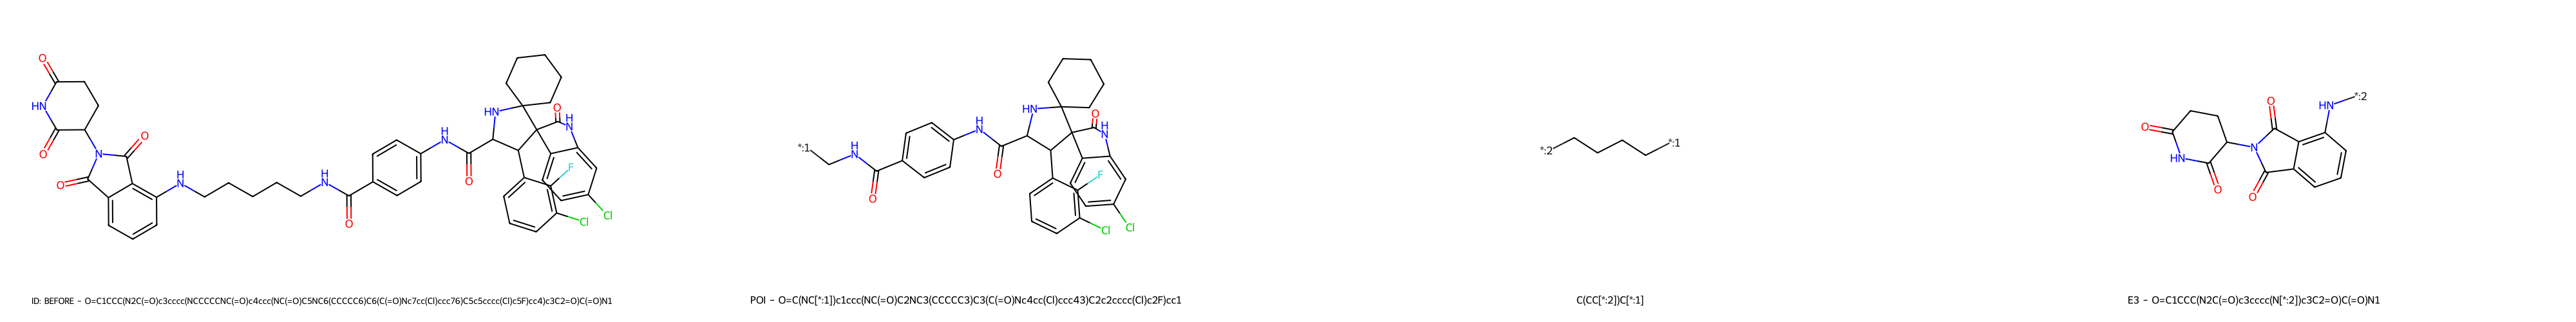

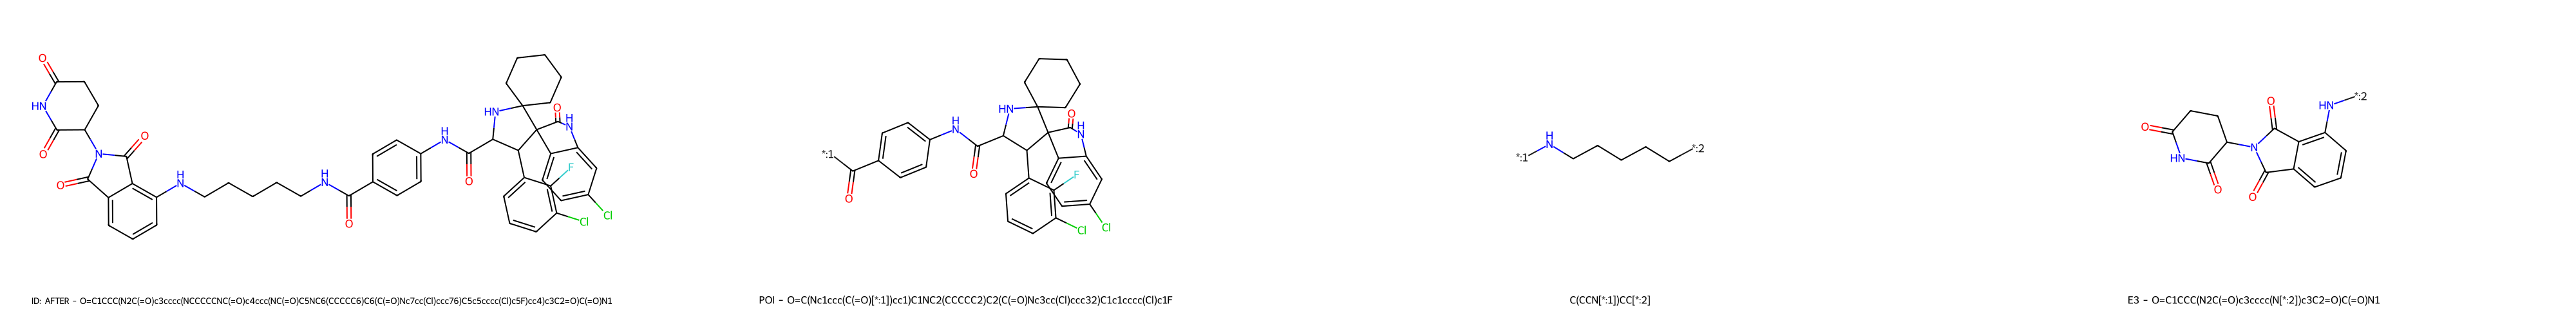

Original re-assembling: True
Fixed re-assembling:    True


In [12]:
def adjust_amide_bond(substruct: Chem.Mol, linker: Chem.Mol, substruct_attachment_id: int) -> Tuple[Chem.Mol, Chem.Mol]:
    """
    Adjust the amide bond between the substruct and linker substructure.
    Handles the case when neighboring atoms of the amide bond are dummy atoms, which represent attachment points.
    
    Args:
        substruct: The substructure of the substruct (protein of interest) that contains the amide bond.
        linker: The linker molecule that connects substruct to the E3 ligase.
        substruct_attachment_id: The attachment point ID in the substruct substructure. E.g., 1 for the POI, as in "[*:1]".
    
    Returns:
        Tuple[Chem.Mol, Chem.Mol]: The adjusted substruct and linker molecules, in that order.
    """
    # Convert dummy atoms in substruct to query atoms for substructure search
    query_substruct = dummy2query(substruct)

    # Identify amide bond (N-C=O) in substruct substructure
    amide_pattern = Chem.MolFromSmarts("[NX3][CX3](=[OX1])")
    amide_matches = query_substruct.GetSubstructMatches(amide_pattern)

    if not amide_matches:
        return substruct, linker  # No amide bond found, return the original substruct
    
    nitrogen_idx_found, carbonyl_idx_found = None, None
    for match in amide_matches:
        nitrogen_idx, carbonyl_idx = match[0], match[1]
        nitrogen_atom = query_substruct.GetAtomWithIdx(nitrogen_idx)

        # Check neighboring atoms for attachment points
        # NOTE: The dummy atom representing an attachment point have atomic number 0
        for neighbor in nitrogen_atom.GetNeighbors():
            if neighbor.GetAtomicNum() == 0:
                nitrogen_idx_found = nitrogen_idx
                carbonyl_idx_found = carbonyl_idx
                break

        # If previous search failed, check the neighbors of the neighboring
        # atoms (second-order neighbors)
        if nitrogen_idx_found is None or carbonyl_idx_found is None:
            for second_neighbor in neighbor.GetNeighbors():
                if second_neighbor.GetIdx() == carbonyl_idx:
                    continue  # Skip the carbonyl carbon from the amide bond

                if second_neighbor.GetAtomicNum() == 0:
                    nitrogen_idx_found = nitrogen_idx
                    carbonyl_idx_found = carbonyl_idx
                    break

    if nitrogen_idx_found is None or carbonyl_idx_found is None:
        return substruct, linker

    # Split the amide bond and adjust
    dummy_labels = [(3, 3)] # The E3 and substruct will have 1 and 2, so we need a third one
    amid_bond_idx = query_substruct.GetBondBetweenAtoms(nitrogen_idx_found, carbonyl_idx_found).GetIdx()
    fragments = Chem.FragmentOnBonds(query_substruct, [amid_bond_idx], addDummies=True, dummyLabels=dummy_labels)

    # Get the fragments resulting from bond breaking
    mol_frags = Chem.GetMolFrags(fragments, asMols=True, sanitizeFrags=True)

    # Identify the "[*:substruct][<optional neighboring atom>]N[3*]" fragment, the other one will be the "truncated" substruct
    amide_fragment_pattern = Chem.MolFromSmarts("[*:1][N][3*]")
    amide_fragment = None
    substruct_fixed = None

    for frag in mol_frags:
        if frag.HasSubstructMatch(dummy2query(amide_fragment_pattern)):
            amide_fragment = frag
        else:
            substruct_fixed = frag
    
    if amide_fragment is None or substruct_fixed is None:
        return substruct, linker

    # Rename the "[3*]" attachment point on the amide fragment to "[*:3]"
    amide_fragment_smiles = Chem.MolToSmiles(amide_fragment, canonical=True)
    amide_fragment_smiles = amide_fragment_smiles.replace('[3*]', f'[*:3]')
    amide_fragment = Chem.MolFromSmiles(amide_fragment_smiles)

    # Use molzip to join the linker and the fragment at the original attachment point
    linker_fixed = Chem.molzip(linker, amide_fragment)

    # Rename the "[*:3]" attachment point back to the original attachment point on the linker
    linker_fixed_smiles = Chem.MolToSmiles(linker_fixed, canonical=True)
    linker_fixed_smiles = linker_fixed_smiles.replace('[*:3]', f'[*:{substruct_attachment_id}]')
    linker_fixed = Chem.MolFromSmiles(linker_fixed_smiles)

    # Rename the "[3*]" attachment point back to the original attachment point on the substruct
    substruct_fixed_smiles = Chem.MolToSmiles(substruct_fixed, canonical=True)
    substruct_fixed_smiles = substruct_fixed_smiles.replace('[3*]', f'[*:{substruct_attachment_id}]')
    substruct_fixed = Chem.MolFromSmiles(substruct_fixed_smiles)

    return substruct_fixed, linker_fixed


protac_smiles = canonize_smiles('O=C1CCC(N2C(=O)c3cccc(NCCCCCNC(=O)c4ccc(NC(=O)C5NC6(CCCCC6)C6(C(=O)Nc7cc(Cl)ccc76)C5c5cccc(Cl)c5F)cc4)c3C2=O)C(=O)N1')
poi_smiles = canonize_smiles('[*:1]CNC(=O)c1ccc(NC(=O)C2NC3(CCCCC3)C3(C(=O)Nc4cc(Cl)ccc43)C2c2cccc(Cl)c2F)cc1')
linker_smiles = canonize_smiles('[*:1]CCCC[*:2]')
e3_smiles = canonize_smiles('[*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O')


poi_fixed, linker_fixed = adjust_amide_bond(Chem.MolFromSmiles(poi_smiles), Chem.MolFromSmiles(linker_smiles), POI_ATTACHMENT_ID)
poi_fixed_smiles = Chem.MolToSmiles(poi_fixed, canonical=True)
linker_fixed_smiles = Chem.MolToSmiles(linker_fixed, canonical=True)

display_protac_substructures(protac_smiles, poi_smiles, linker_smiles, e3_smiles, compound_id='BEFORE')
display_protac_substructures(protac_smiles, poi_fixed_smiles, linker_fixed_smiles, e3_smiles, compound_id='AFTER')

print(f'Original re-assembling: {check_reassembly(protac_smiles, ".".join([poi_smiles, linker_smiles, e3_smiles]))}')
print(f'Fixed re-assembling:    {check_reassembly(protac_smiles, ".".join([poi_fixed_smiles, linker_fixed_smiles, e3_smiles]))}')

## Load Raw Datasets

From [PROTAC-DB paper](https://academic.oup.com/nar/article/49/D1/D1381/5917660?login=false#:~:text=For%20linkers%2C%20only%20the%202D%20structures%2C%20compound%20IDs%20and%20targeted%20proteins%20are%20shown%20in%20the%20datasheet.%20The%20%E2%80%98R1%E2%80%99%20and%20%E2%80%98R2%E2%80%99%20in%20the%20structures%20represent%20the%20sites%20that%20conjugate%20warheads%20and%20E3%20ligands%2C%20respectively.):

> For linkers, only the 2D structures, compound IDs and targeted proteins are shown in the datasheet. The ‘R1’ and ‘R2’ in the structures represent the sites that conjugate warheads and E3 ligands, respectively.

In [13]:
protac_pedia_df = pd.read_csv(os.path.join(data_dir, 'raw', 'PROTAC-Pedia.csv')).reset_index(drop=True)
protac_db_df = pd.read_csv(os.path.join(data_dir, 'raw', 'PROTAC-DB.csv')).reset_index(drop=True)
protac_db_linker_df = pd.read_csv(os.path.join(data_dir, 'raw', 'PROTAC-DB-Linkers.csv')).reset_index(drop=True)
protac_db_e3_df = pd.read_csv(os.path.join(data_dir, 'raw', 'PROTAC-DB-E3-Ligands.csv')).reset_index(drop=True)
protac_db_poi_df = pd.read_csv(os.path.join(data_dir, 'raw', 'PROTAC-DB-Warheads.csv')).reset_index(drop=True)

# Rename columns to make them consistent the PROTAC-Pedia columns
protac_pedia_df = protac_pedia_df.rename(columns={
    'Linker': 'Linker SMILES',
    'Ligand SMILES': 'POI Ligand SMILES',
})
protac_db_df = protac_db_df.rename(columns={'Smiles': 'PROTAC SMILES'})
protac_db_linker_df = protac_db_linker_df.rename(columns={'Smiles': 'Linker SMILES', 'Smiles_R': 'Linker SMARTS'})
protac_db_e3_df = protac_db_e3_df.rename(columns={'Smiles': 'E3 Binder SMILES'})
protac_db_poi_df = protac_db_poi_df.rename(columns={'Smiles': 'POI Ligand SMILES'})

# Replace the attachment points in the linker SMARTS with the ones we defined
protac_db_linker_df['Linker SMARTS'] = protac_db_linker_df['Linker SMARTS'].str.replace('[R1]', f'[*:{POI_ATTACHMENT_ID}]')
protac_db_linker_df['Linker SMARTS'] = protac_db_linker_df['Linker SMARTS'].str.replace('[R2]', f'[*:{E3_ATTACHMENT_ID}]')

# Canonize all the SMILES strings
tqdm.pandas(desc='Canonizing SMILES')
protac_pedia_df['PROTAC SMILES'] = protac_pedia_df['PROTAC SMILES'].progress_apply(canonize_smiles)
protac_db_df['PROTAC SMILES'] = protac_db_df['PROTAC SMILES'].progress_apply(canonize_smiles)
protac_db_linker_df['Linker SMILES'] = protac_db_linker_df['Linker SMILES'].progress_apply(canonize_smiles)
protac_db_linker_df['Linker SMARTS'] = protac_db_linker_df['Linker SMARTS'].progress_apply(canonize_smiles)
protac_db_e3_df['E3 Binder SMILES'] = protac_db_e3_df['E3 Binder SMILES'].progress_apply(canonize_smiles)
protac_db_poi_df['POI Ligand SMILES'] = protac_db_poi_df['POI Ligand SMILES'].progress_apply(canonize_smiles)

# Drop rows with invalid SMILES
protac_db_df = protac_db_df.dropna(subset=['PROTAC SMILES'])
protac_db_linker_df = protac_db_linker_df.dropna(subset=['Linker SMILES', 'Linker SMARTS'], how='all')
protac_db_e3_df = protac_db_e3_df.dropna(subset=['E3 Binder SMILES'])
protac_db_poi_df = protac_db_poi_df.dropna(subset=['POI Ligand SMILES'])

print('')
print('Listing unique compound IDs according to PROTAC-DB:')
print(f'protac_db_df:        {len(protac_db_df['Compound ID'].unique()):,}')
print(f'protac_db_poi_df:    {len(protac_db_poi_df['Compound ID'].unique()):,}')
print(f'protac_db_linker_df: {len(protac_db_linker_df['Compound ID'].unique()):,}')
print(f'protac_db_e3_df:     {len(protac_db_e3_df['Compound ID'].unique()):,}')

print('')
print(f'Number of unique PROTAC SMILES in PROTAC-DB:     {len(protac_db_df["PROTAC SMILES"].unique()):,}')
print(f'Number of unique POI Ligand SMILES in PROTAC-DB: {len(protac_db_poi_df["POI Ligand SMILES"].unique()):,}')
print(f'Number of unique E3 Binder SMILES in PROTAC-DB:  {len(protac_db_e3_df["E3 Binder SMILES"].unique()):,}')
print(f'Number of unique Linker SMILES in PROTAC-DB:     {len(protac_db_linker_df["Linker SMILES"].unique()):,}')
print(f'Number of unique Linker SMARTS in PROTAC-DB:     {len(protac_db_linker_df["Linker SMARTS"].unique()):,}')

print('')
print(f'Number of unique PROTAC SMILES in PROTAC-Pedia:     {len(protac_pedia_df["PROTAC SMILES"].unique()):,}')
print(f'Number of unique POI Ligand SMILES in PROTAC-Pedia: {len(protac_pedia_df["POI Ligand SMILES"].unique()):,}')
print(f'Number of unique E3 Binder SMILES in PROTAC-Pedia:  {len(protac_pedia_df["E3 Binder SMILES"].unique()):,}')
print(f'Number of unique Linker SMILES in PROTAC-Pedia:     {len(protac_pedia_df["Linker SMILES"].unique()):,}')

Canonizing SMILES: 100%|██████████| 1460/1460 [00:00<00:00, 6265.77it/s]


Listing unique compound IDs according to PROTAC-DB:
protac_db_df:        3,270
protac_db_poi_df:    569
protac_db_linker_df: 2,749
protac_db_e3_df:     107

Number of unique PROTAC SMILES in PROTAC-DB:     3,270
Number of unique POI Ligand SMILES in PROTAC-DB: 569
Number of unique E3 Binder SMILES in PROTAC-DB:  107
Number of unique Linker SMILES in PROTAC-DB:     2,490
Number of unique Linker SMARTS in PROTAC-DB:     2,749

Number of unique PROTAC SMILES in PROTAC-Pedia:     1,178
Number of unique POI Ligand SMILES in PROTAC-Pedia: 183
Number of unique E3 Binder SMILES in PROTAC-Pedia:  69
Number of unique Linker SMILES in PROTAC-Pedia:     664


The following is an attempt to map the provided PROTAC-DB linkers to the PROTACs in the dataset. Only a very small fraction of the linkers could be mapped to the PROTACs in the dataset... So we skip it for now.

In [14]:
# tmp = protac_db_df.copy()
# tmp['PROTAC SMILES'] = tmp['PROTAC SMILES'].apply(canonize_smiles)
# tmp = tmp.merge(protac_db_linker_df, on='Compound ID', how='left', suffixes=('', '_linker'))
# tmp = tmp[['PROTAC SMILES', 'Linker SMARTS']]
# print(len(tmp))
# # Replace "[R1]" in the linker SMILES with "[*:2]"
# tmp['Linker SMARTS'] = tmp['Linker SMARTS'].str.replace('[R1]', f'[*:{POI_ATTACHMENT_ID}]')
# tmp['Linker SMARTS'] = tmp['Linker SMARTS'].str.replace('[R2]', f'[*:{E3_ATTACHMENT_ID}]')
# tmp = tmp.dropna()
# print(len(tmp))

# def get_substructs_df(row: pd.Series) -> Dict[str, str]:
#     substructs = get_substructs_from_mapped_linker(row['PROTAC SMILES'], row['Linker SMARTS'])
#     if substructs is not None:
#         if check_reassembly(canonize_smiles(row['PROTAC SMILES']), '.'.join(substructs.values())):
#             for key, value in substructs.items():
#                 row[key] = value
#     return row

# tqdm.pandas(desc='Extracting substructures')
# tmp = tmp.progress_apply(get_substructs_df, axis=1)

# tmp = tmp.dropna().drop_duplicates(subset=['PROTAC SMILES', 'linker', 'e3', 'poi'])
# safe_display(tmp)
# print(len(tmp))

# for i, row in tmp.sample(10).iterrows():
#     protac_mol = Chem.MolFromSmiles(row['PROTAC SMILES'])
#     poi_mol = Chem.MolFromSmiles(row['poi'])
#     e3_mol = Chem.MolFromSmiles(row['e3'])
#     linker_mol = Chem.MolFromSmiles(row['linker'])
#     img = Draw.MolsToGridImage([protac_mol, poi_mol, linker_mol, e3_mol], molsPerRow=4, subImgSize=(1000, 500), legends=['PROTAC', 'POI', 'Linker', 'E3'])
#     safe_display(img)

# print(f'Number of unique POI: {len(tmp["poi"].unique())}')
# print(f'Number of unique E3: {len(tmp["e3"].unique())}')
# print(f'Number of unique linker: {len(tmp["linker"].unique())}')

## Generate Dictionaries

In [15]:
from collections import defaultdict

dictionaries_orig = defaultdict(list)

# Get a dictionary of all the available PROTACs
protac_smiles = pd.concat([protac_pedia_df['PROTAC SMILES'], protac_db_df['PROTAC SMILES']]).dropna().unique()
for idx, protac in enumerate(protac_smiles):
    dictionaries_orig['PROTAC'].append({'SMILES': protac, 'ID': idx})

# Get dictionaries_orig for the POI ligands, linkers, and E3 binders
for substr_name in ['POI Ligand', 'Linker', 'E3 Binder', 'Linker with direction']:
    if substr_name == 'POI Ligand':
        substruct_smiles = pd.concat([protac_pedia_df['POI Ligand SMILES'], protac_db_poi_df['POI Ligand SMILES']]).dropna().unique()
    elif substr_name == 'Linker':
        substruct_smiles = pd.concat([protac_pedia_df['Linker SMILES'], protac_db_linker_df['Linker SMILES']]).dropna().unique()
    elif substr_name == 'E3 Binder':
        substruct_smiles = pd.concat([protac_pedia_df['E3 Binder SMILES'], protac_db_e3_df['E3 Binder SMILES']]).dropna().unique()
    elif substr_name == 'Linker with direction':
        substruct_smiles = pd.concat([protac_db_linker_df['Linker SMARTS'], protac_db_linker_df['Linker SMARTS']]).dropna().unique()
    for idx, smiles in enumerate(substruct_smiles):
        dictionaries_orig[substr_name].append({f'SMILES': smiles, f'ID': idx})

# Convert the dictionaries_orig to dataframes
for key, dictionary in dictionaries_orig.items():
    dictionaries_orig[key] = pd.DataFrame(dictionary)

# Reporting
for key, dictionary in dictionaries_orig.items():
    print(f'{key}: {len(dictionary):,}')

PROTAC: 3,641
POI Ligand: 695
Linker: 2,790
E3 Binder: 160
Linker with direction: 2,749


Remove stereochemistry and update dictionaries with those changes:

In [16]:
def remove_stereo(smiles: str) -> str:
    """ Removes stereochemistry from a SMILES string.
    
    Args:
        smiles: The input SMILES string.

    Returns:
        The SMILES string without stereochemistry.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        Chem.rdmolops.RemoveStereochemistry(mol)
        return Chem.MolToSmiles(mol)
    except Exception as e:
        return np.nan

dictionaries_nostereo = {}
# Remove stereochemistry from all the SMILES strings in the dictionaries
for key, value in dictionaries_orig.items():
    dictionaries_nostereo[key] = value.copy()
    tqdm.pandas(desc=f'Removing stereochemistry from {key}')
    dictionaries_nostereo[key]['SMILES'] = value['SMILES'].progress_apply(remove_stereo)
    # Drop rows with invalid SMILES
    dictionaries_nostereo[key] = dictionaries_nostereo[key].dropna(subset=['SMILES'])

# Reporting
print('\nDictionaries with no stereochemistry:')
for key, value in dictionaries_nostereo.items():
    print(f'{key}: {len(value):,}')

# Concatenate the respective dictionaries
dictionaries_no_extra = {}
for key, value in dictionaries_nostereo.items():
    smiles_col = [col for col in value.columns if 'SMILES' in col][0]
    dictionaries_no_extra[key] = pd.concat([dictionaries_orig[key], value.copy()], axis=0).drop_duplicates(subset=smiles_col).reset_index(drop=True)

# Reporting
print('\nFinal dictionaries_no_extra:')
for key, dictionary in dictionaries_no_extra.items():
    print(f'{key}: {len(dictionary):,}')
    print(f'\tNumber of unique SMILES: {len(dictionary["SMILES"].unique()):,}')
    print(f'\tNumber of unique IDs: {len(dictionary["ID"].unique()):,}')

Removing stereochemistry from E3 Binder: 100%|██████████| 160/160 [00:00<00:00, 7060.30it/s]
Removing stereochemistry from Linker with direction: 100%|██████████| 2749/2749 [00:00<00:00, 15689.85it/s]



Dictionaries with no stereochemistry:
PROTAC: 3,641
POI Ligand: 695
Linker: 2,772
E3 Binder: 160
Linker with direction: 2,749

Final dictionaries_no_extra:
PROTAC: 5,680
	Number of unique SMILES: 5,680
	Number of unique IDs: 3,641
POI Ligand: 946
	Number of unique SMILES: 946
	Number of unique IDs: 695
Linker: 2,908
	Number of unique SMILES: 2,908
	Number of unique IDs: 2,790
E3 Binder: 252
	Number of unique SMILES: 252
	Number of unique IDs: 160
Linker with direction: 2,884
	Number of unique SMILES: 2,884
	Number of unique IDs: 2,749


Precompute all molecules in all dictionaries:

In [17]:
for key, d in dictionaries_no_extra.items():
    tqdm.pandas(desc=f'Creating molecules for {key}')
    dictionaries_no_extra[key]['Molecule'] = d['SMILES'].progress_apply(Chem.MolFromSmiles)
    # Drop rows with invalid molecules
    dictionaries_no_extra[key] = dictionaries_no_extra[key].dropna(subset=['Molecule'])

# Reporting
print('\nDictionaries with molecules after removing invalid molecules:')
for key, dictionary in dictionaries_no_extra.items():
    print(f'{key}: {len(dictionary):,}')
    print(f'\tNumber of unique SMILES: {len(dictionary["SMILES"].unique()):,}')
    print(f'\tNumber of unique IDs: {len(dictionary["ID"].unique()):,}')

Creating molecules for Linker with direction: 100%|██████████| 2884/2884 [00:00<00:00, 29884.78it/s]


Dictionaries with molecules after removing invalid molecules:
PROTAC: 5,680
	Number of unique SMILES: 5,680
	Number of unique IDs: 3,641
POI Ligand: 946
	Number of unique SMILES: 946
	Number of unique IDs: 695
Linker: 2,890
	Number of unique SMILES: 2,890
	Number of unique IDs: 2,772
E3 Binder: 252
	Number of unique SMILES: 252
	Number of unique IDs: 160
Linker with direction: 2,884
	Number of unique SMILES: 2,884
	Number of unique IDs: 2,749


## Extra Substructures (Manually Curated)

In [18]:
additional_e3 = [
    'CC(C)C[C@H](NC(=O)[C@@H](O)[C@H](N)Cc1ccccc1)C(N)=O',
    'COc1cc(ccc1NC(=O)[C@@H]1N[C@@H](CC(C)(C)C)[C@@](C#N)([C@H]1c1cccc(Cl)c1F)c1ccc(Cl)cc1F)C(N)=O',
    'N[C@@H](CCCNC(N)=N)C(N)=O',
    'N[C@@H](Cc1c[nH]cn1)C(N)=O',
    'CC(C)[C@H](NC(C)=O)C(=O)N1C[C@@H](O)C[C@@H]1C(=O)N[C@@H](CC=O)c1ccccc1',
    'CSC(C)(C)[C@H](N)C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(cc1)-c1scnc1C',
    'Nc1cccc2C(=O)N(C3CCC(=O)NC3=O)C(=O)c12',
    'Cc1cccc2C(=O)N(Cc12)C1CCC(=O)NC1=O',
    'Nc1ccc2C(=O)N(Cc2c1)C1CCC(=O)NC1=O',
    # --------------------------------------------------------------------------
    # The following are manually added entries
    # --------------------------------------------------------------------------
    # 'N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C', #TODO: This is coming from a trained model, so it might be wrong
    # --------------------------------------------------------------------------
    # 'C[C@H](NC(=O)[C@@H]1C[C@@H](O)CN1C(=O)[C@@H](N)C(C)(C)C)c1ccc(cc1)-c1scnc1C',
    # 'Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1',
    # 'NC(=O)c1c(N)n(nc1-c1ccc(Oc2ccc(F)cc2F)cc1)[C@@H]1CCCNC1',
    # 'Fc1ccc(Cc2n[nH]c(=O)c3ccccc23)cc1C(=O)N1CCNCC1',
    # 'NC(=O)c1c(N)n(nc1-c1ccc(Oc2ccc(F)cc2F)cc1)[C@@H]1CCCNC1',
    # 'Cc1ccccc1-n1c(C)cc(OCc2ccc(F)cc2F)c(Br)c1=O',
    # 'CC(C)c1cnn2c(NCc3ccc(N)cc3)nc(OC3CCN(C)CC3)nc12',
    # 'CCNc1nc(N2CCN(CC2)C(=O)CC)c2cc(Cl)c(c(F)c2n1)-c1cc(O)cc2ccccc12',
    # 'Fc1c(Cl)cccc1[C@H]1[C@@H](NC2(CCCCC2)[C@@]11C(=O)Nc2cc(Cl)ccc12)C(=O)Nc1ccccc1',
]
additional_poi = [
    'CNCC[C@H](CSc1ccccc1)Nc1ccc(cc1S(=O)(=O)C(F)(F)F)S(=O)(=O)NC(=O)c1ccc(cc1)N1CCN(CC2=C(CCC(C)(C)C2)c2ccc(Cl)cc2)CC1',
    'CNCC[C@H](CSc1ccccc1)Nc1ccc(cc1S(=O)(=O)C(F)(F)F)S(=O)(=O)NC(=O)c1ccc(cc1)N1CCN(CC2=C(CCC(C)(C)C2)c2ccc(Cl)cc2)CC1',
    'CN(C)CC[C@H](CSc1ccccc1)Nc1ccc(cc1S(=O)(=O)C(F)(F)F)S(=O)(=O)NC(=O)c1ccc(cc1)N1CCN(CC2=C(CCC(C)(C)C2)c2ccc(Cl)cc2)CC1',
    'CC(=O)c1c(C)c2cnc(N)nc2n(C2CCCC2)c1=O',
    # --------------------------------------------------------------------------
    # The following are manually added entries
    # --------------------------------------------------------------------------
    # 'CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(cc1)-c1scnc1C)C(C)(C)C', # TODO: Double check this one! I manually fixed it in https://www.rcsb.org/chemical-sketch
    # 'Oc1ccc(N2C(=S)N(c3ccc(C#N)c(C(F)(F)F)c3)C(=O)C2(C)C)cc1', #TODO: This is coming from a trained model, so it might be wrong
    # 'N1CCC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)CC1', #TODO: This is coming from a trained model, so it might be wrong
    # --------------------------------------------------------------------------
    # 'CCNCCOc1ccc(cc1)C(=O)c1c(sc2cc(O)ccc12)-c1ccc(O)cc1',
    # 'CCNCCOc1ccc(Cn2c(c(C)c3cc(O)ccc23)-c2ccc(O)cc2)cc1',
    # 'CCNCCOc1ccc(cc1)[C@H]1[C@H](CCc2cc(O)ccc12)c1ccccc1',
    # 'CC(C)c1cnn2c(NCc3ccc(N)cc3)nc(OC3CCN(C)CC3)nc12',
    # 'CCCS(=O)(=O)Nc1ccc(F)c(c1F)-n1cc(-c2cncnc2)c2nc(ccc12)N(C)C1CCNCC1',
    # 'NC(=O)CC[C@H](NC(=O)[C@@H]1CC[C@@H]2CCNC[C@H](NC(=O)c3cc4cc(ccc4[nH]3)C(F)(F)P(O)(O)=O)C(=O)N12)C(=O)NC(c1ccccc1)c1ccccc1',
    # 'Cn1cc2-c3cc(CS(C)(=O)=O)ccc3N(Cc3c[nH]c(c23)c1=O)c1ncc(F)cc1F',
    # 'C[C@@H]1N=C(c2c(C)c(C)sc2-n2c(C)nnc12)c1ccc(Cl)cc1',
    # 'Cn1cc2-c3cc(CS(C)(=O)=O)ccc3N(Cc3c[nH]c(c23)c1=O)c1ncc(F)cc1F',
]

def update_dictionary(dictionary: pd.DataFrame, substr_to_add: list, verbose: int = 0) -> pd.DataFrame:
    """ Updates a dictionary with a list of additional substructures.

    Args:
        dictionary: The input dictionary dataframe.
        substr_to_add: The list of additional substructures.

    Returns:
        The updated dictionary dataframe.
    """
    # Canonize the SMILES strings
    substr_to_add = [canonize_smiles(smiles) for smiles in substr_to_add if smiles is not None]

    # Remove entries already in the dictionary
    for smiles in substr_to_add:
        if smiles in dictionary[f'SMILES'].values:
            if verbose > 1:
                print(f'\tWARNING. SMILES already in the dictionary: {smiles}')
            # Remove it from the list
            substr_to_add.remove(smiles)

    # Get the current maximum ID
    max_id = dictionary['ID'].max()
    new_entries = []
    for smiles in substr_to_add:
        max_id += 1
        mol = Chem.MolFromSmiles(smiles)
        # Remove entries that result in invalid molecules
        if mol is None:
            continue
        new_entries.append({
            'SMILES': smiles,
            'Molecule': mol,
            'ID': max_id,
        })
        # Try adding its no-stereochemistry version as well
        smiles_nostereo = remove_stereo(smiles)
        if smiles_nostereo is not None and smiles_nostereo != smiles:
            new_entries.append({
                'SMILES': canonize_smiles(smiles_nostereo),
                'Molecule': Chem.MolFromSmiles(smiles_nostereo),
                'ID': max_id,
            })
    new_entries = pd.DataFrame(new_entries)

    if len(new_entries) > 0 and verbose:
        print(f'Number of substructures added to the dictionary: {len(new_entries)}')

    # Return the updated dictionary
    return pd.concat([dictionary, pd.DataFrame(new_entries)], axis=0).reset_index(drop=True)

dictionaries = {}
for key, value in dictionaries_no_extra.items():
    dictionaries[key] = value.copy()
    if key == 'E3 Binder':
        dictionaries[key] = update_dictionary(dictionaries[key], additional_e3)
    elif key == 'POI Ligand':
        dictionaries[key] = update_dictionary(dictionaries[key], additional_poi)

# Reporting
print('\nFinal dictionaries:')
for key, dictionary in dictionaries.items():
    print(f'{key}: {len(dictionary):,}')
    print(f'\tNumber of unique SMILES: {len(dictionary["SMILES"].unique()):,}')
    print(f'\tNumber of unique IDs: {len(dictionary["ID"].unique()):,}')


Final dictionaries:
PROTAC: 5,680
	Number of unique SMILES: 5,680
	Number of unique IDs: 3,641
POI Ligand: 953
	Number of unique SMILES: 951
	Number of unique IDs: 699
Linker: 2,890
	Number of unique SMILES: 2,890
	Number of unique IDs: 2,772
E3 Binder: 264
	Number of unique SMILES: 264
	Number of unique IDs: 167
Linker with direction: 2,884
	Number of unique SMILES: 2,884
	Number of unique IDs: 2,749


### Example of dictionary usage

In [19]:
def get_id_from_dict(
        substr_smiles: str,
        dictionary: pd.DataFrame,
        update_dict_if_not_found: bool = False,
        verbose: int = 0,
) -> Optional[int]:
    """ Get the ID of a substructure from a dictionary.

    Args:
        substr_smiles: The SMILES of the substructure.
        dictionaries: The dictionaries containing the substructures.
        substr_name: The name of the substructure.
        update_dict_if_not_found: Whether to update the dictionary if the substructure is not found.

    Returns:
        The ID of the substructure, if present, None otherwise.
    """
    substr_smiles = canonize_smiles(substr_smiles)
    # if substr_smiles is None:
    #     return None
    substr_id = None
    if substr_smiles in dictionary['SMILES'].values:
        substr_id = dictionary[dictionary['SMILES'] == substr_smiles]['ID'].values[0]
    elif update_dict_if_not_found:
        dictionary = update_dictionary(dictionary, [substr_smiles], verbose)
        substr_id = dictionary[dictionary['SMILES'] == substr_smiles]['ID'].values[0]
    return substr_id

linker_smiles_list = [
    'C(COCCOC[*:2])OCCOCC[*:1]',
    'C(#Cc1ccc(OC2CC(Oc3cc([*:1])ccn3)C2)cn1)COc1cc([*:2])on1',
    '[*:2]CCOCCOCC(=O)[*:1]',
    # None,
]

for linker_smiles in linker_smiles_list:
    # Get the ID of the linker with direction from the dictionary, if present
    linker_id = get_id_from_dict(linker_smiles, dictionaries['Linker with direction'])
    print('-' * 50)
    linker_id_updated = get_id_from_dict(linker_smiles, dictionaries['Linker with direction'], update_dict_if_not_found=True, verbose=2)
    print(f'Linker ID: {linker_id} (updated ID: {linker_id_updated})')

--------------------------------------------------
Linker ID: 1 (updated ID: 1)
--------------------------------------------------
Linker ID: 2702 (updated ID: 2702)
--------------------------------------------------
Linker ID: 17 (updated ID: 17)


## Get Substructures From Dictionaries

TODO: For some matched protacs, the removal of the attachment points, _i.e._, dummy atoms, fails, despite their SMILES with attachment point being correct.

In [20]:
def adjust_amide_bonds_in_substructs(substructs: Dict[str, str], protac_smiles: str) -> Dict[str, str]:
    poi_mol = Chem.MolFromSmiles(substructs['poi'])
    e3_mol = Chem.MolFromSmiles(substructs['e3'])
    linker_mol = Chem.MolFromSmiles(substructs['linker'])

    poi_mol, linker_mol = adjust_amide_bond(poi_mol, linker_mol, POI_ATTACHMENT_ID)

    if not check_reassembly(protac_smiles, '.'.join([Chem.MolToSmiles(poi_mol, canonical=True), Chem.MolToSmiles(linker_mol, canonical=True), substructs['e3']])):
        return substructs

    e3_mol, linker_mol = adjust_amide_bond(e3_mol, linker_mol, E3_ATTACHMENT_ID)
    if not check_reassembly(protac_smiles, '.'.join([Chem.MolToSmiles(poi_mol, canonical=True), Chem.MolToSmiles(linker_mol, canonical=True), Chem.MolToSmiles(e3_mol, canonical=True)])):
        return substructs

    substructs['poi'] = Chem.MolToSmiles(poi_mol, canonical=True)
    substructs['e3'] = Chem.MolToSmiles(e3_mol, canonical=True)
    substructs['linker'] = Chem.MolToSmiles(linker_mol, canonical=True)
    return substructs

def map_protacs(
        protac_df: pd.DataFrame,
        dictionaries: Dict[str, pd.DataFrame] = dictionaries,
        max_iter_on_linkers: int = 5,
        biggest_matches_first: bool = True,
        update_dict_if_ids_not_found: bool = False,
) -> pd.DataFrame:
    """ Maps PROTACs to their substructures.

    Args:
        protac_df: The input PROTAC dataframe.
        max_iter_on_linkers: The maximum number of matching linkers to iterate over. If zero, there will be no attempt to match linkers in the dictionary. If negative, iterate over all matched linkers. Default is 5.
        dictionaries: The input dictionaries.

    Returns:
        The mapped PROTAC dataframe.
    """
    def get_mapped_row(row, dictionaries, substructs, poi_smiles_no_dummy=None, e3_smiles_no_dummy=None):
        mapped_row = {}
        mapped_row['PROTAC SMILES'] = canonize_smiles(row['SMILES'])
        mapped_row['PROTAC ID'] = row['ID']
        mapped_row['POI Ligand SMILES with direction'] = substructs['poi']
        mapped_row['E3 Binder SMILES with direction'] = substructs['e3']
        mapped_row['Linker SMILES with direction'] = substructs['linker']
        mapped_row['POI Ligand SMILES'] = remove_dummy_atoms(substructs['poi']) if poi_smiles_no_dummy is None else poi_smiles_no_dummy
        mapped_row['E3 Binder SMILES'] = remove_dummy_atoms(substructs['e3']) if e3_smiles_no_dummy is None else e3_smiles_no_dummy
        mapped_row['Linker SMILES'] = remove_dummy_atoms(substructs['linker'])

        # Get the IDs and update the dictionaries with new substructures
        mapped_row['POI Ligand ID'] = get_id_from_dict(mapped_row['POI Ligand SMILES'], dictionaries['POI Ligand'], update_dict_if_not_found=update_dict_if_ids_not_found)
        mapped_row['E3 Binder ID'] = get_id_from_dict(mapped_row['E3 Binder SMILES'], dictionaries['E3 Binder'], update_dict_if_not_found=update_dict_if_ids_not_found)
        mapped_row['Linker ID'] = get_id_from_dict(mapped_row['Linker SMILES with direction'], dictionaries['Linker with direction'], update_dict_if_not_found=update_dict_if_ids_not_found)

        return mapped_row

    mapped_protacs = []
    for i, row in (pbar := tqdm(protac_df.iterrows(), total=len(protac_df))):
        pbar.set_description(f'PROTAC n.{i:4d}')

        protac_smiles = row['SMILES']
        protac_mol = row['Molecule']

        # Get all substructure matches in the POI dictionary
        poi_matches = dictionaries['POI Ligand']['Molecule'].apply(lambda x: protac_mol.HasSubstructMatch(x, useChirality=True))
        pois = dictionaries['POI Ligand'][poi_matches]

        # Get all substructure matches in the E3 dictionary
        e3_matches = dictionaries['E3 Binder']['Molecule'].apply(lambda x: protac_mol.HasSubstructMatch(x, useChirality=True))
        e3s = dictionaries['E3 Binder'][e3_matches]

        # Sort the matches by the number of atoms in the molecule
        ascending = False if biggest_matches_first else True
        pois = pois.sort_values(by='Molecule', key=lambda s: s.apply(lambda m: m.GetNumAtoms()), ascending=ascending)
        e3s = e3s.sort_values(by='Molecule', key=lambda s: s.apply(lambda m: m.GetNumAtoms()), ascending=ascending)

        for _, poi in pois.iterrows():
            for _, e3 in e3s.iterrows():
                substructs = get_substructs_from_unmapped_e3_poi(protac_smiles, protac_mol, poi['Molecule'], e3['Molecule'])

                # If the substructure is not found, try to get it from a non-perfect match
                if substructs is None:
                    fixed_poi, _ = get_substructure_from_non_perfect_match(protac_mol, poi['Molecule'], POI_ATTACHMENT_ID)
                    fixed_e3, _ = get_substructure_from_non_perfect_match(protac_mol, e3['Molecule'], E3_ATTACHMENT_ID)
                    fixed_poi = poi['Molecule'] if fixed_poi is None else fixed_poi
                    fixed_e3 = e3['Molecule'] if fixed_e3 is None else fixed_e3
                    if fixed_poi is not None and fixed_e3 is not None:
                        substructs = get_substructs_from_unmapped_e3_poi(protac_smiles, protac_mol, fixed_poi, fixed_e3)

                if substructs is not None:
                    # Fix the amide bond in the linker, if necessary
                    substructs = adjust_amide_bonds_in_substructs(substructs, protac_smiles)
                    # Add the mapped PROTAC to the final list
                    mapped_protacs.append(get_mapped_row(row, dictionaries, substructs, poi['SMILES'], e3['SMILES']))
                    break
            if substructs is not None:
                break

        if substructs is not None:
            pbar.set_postfix({'len mapped': len(mapped_protacs), 'perc total': f'{len(mapped_protacs) / len(protac_df):.1%}'})
            continue

        # Get all substructure matches in the Linker with direction dictionary
        if max_iter_on_linkers > 0:
            matches = dictionaries['Linker with direction']['Molecule'].apply(lambda x: protac_mol.HasSubstructMatch(dummy2query(x), useChirality=True))
            linkers = dictionaries['Linker with direction'][matches]

            # Sort all the matches by the number of atoms in the linker, the biggest first
            linkers = linkers.sort_values(by='Molecule', key=lambda s: s.apply(lambda m: m.GetNumAtoms()), ascending=False)

            for j, row_linker in linkers.iterrows():
                if j >= max_iter_on_linkers and max_iter_on_linkers > 0:
                    break
                linker_smiles = row_linker['SMILES']
                substructs = get_substructs_from_mapped_linker(row['SMILES'], linker_smiles)
                if substructs is not None:
                    mapped_protacs.append(get_mapped_row(row, dictionaries, substructs))
                    break

        pbar.set_postfix({'len mapped': len(mapped_protacs), 'perc total': f'{len(mapped_protacs) / len(protac_df):.1%}'})

    mapped_protacs = pd.DataFrame(mapped_protacs)
    return mapped_protacs


mapped_protacs = map_protacs(
    dictionaries['PROTAC'].iloc[:100],
    max_iter_on_linkers=0,
    biggest_matches_first=True,
)
print(f'Number of mapped PROTACs: {len(mapped_protacs)} ({len(mapped_protacs) / len(dictionaries["PROTAC"]):.2%})')

PROTAC n.  99: 100%|██████████| 100/100 [00:06<00:00, 16.46it/s, len mapped=70, perc total=70.0%]

Number of mapped PROTACs: 70 (1.23%)


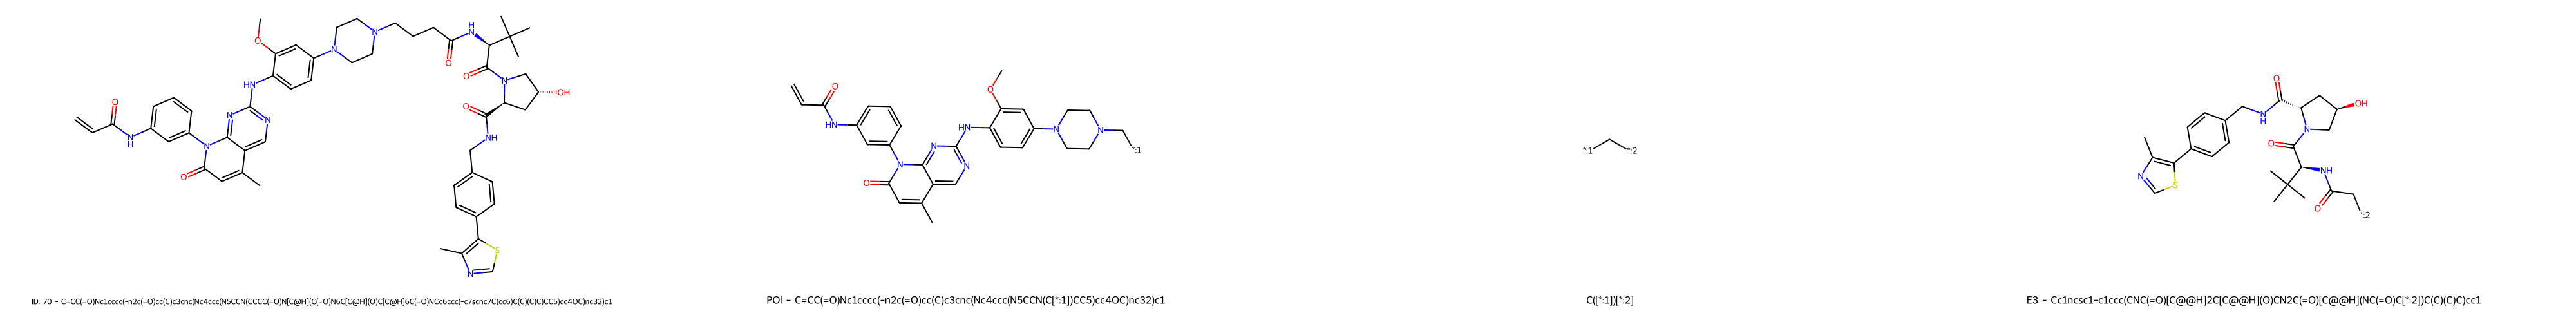

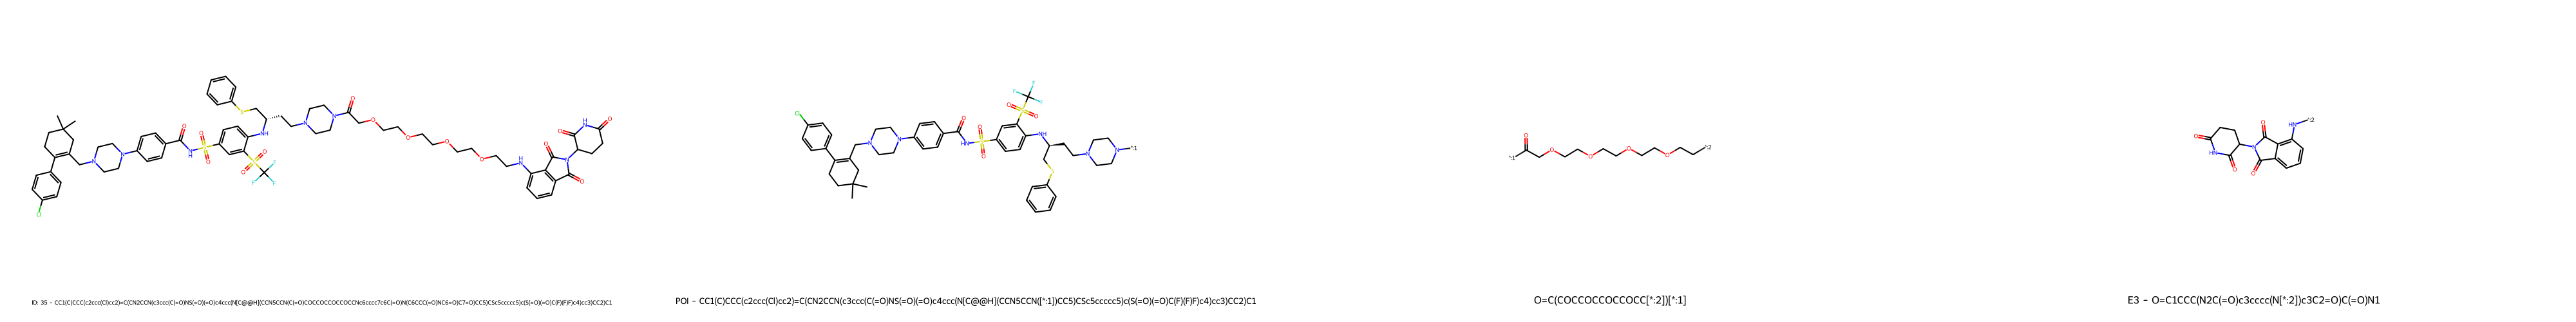

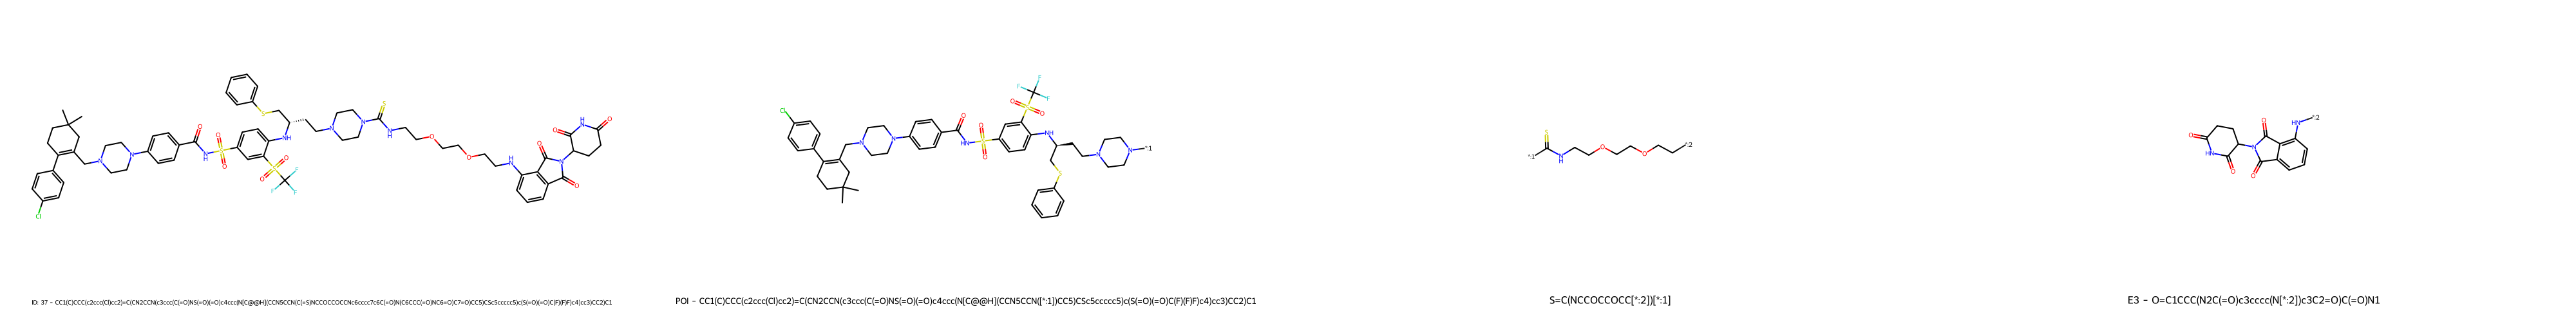

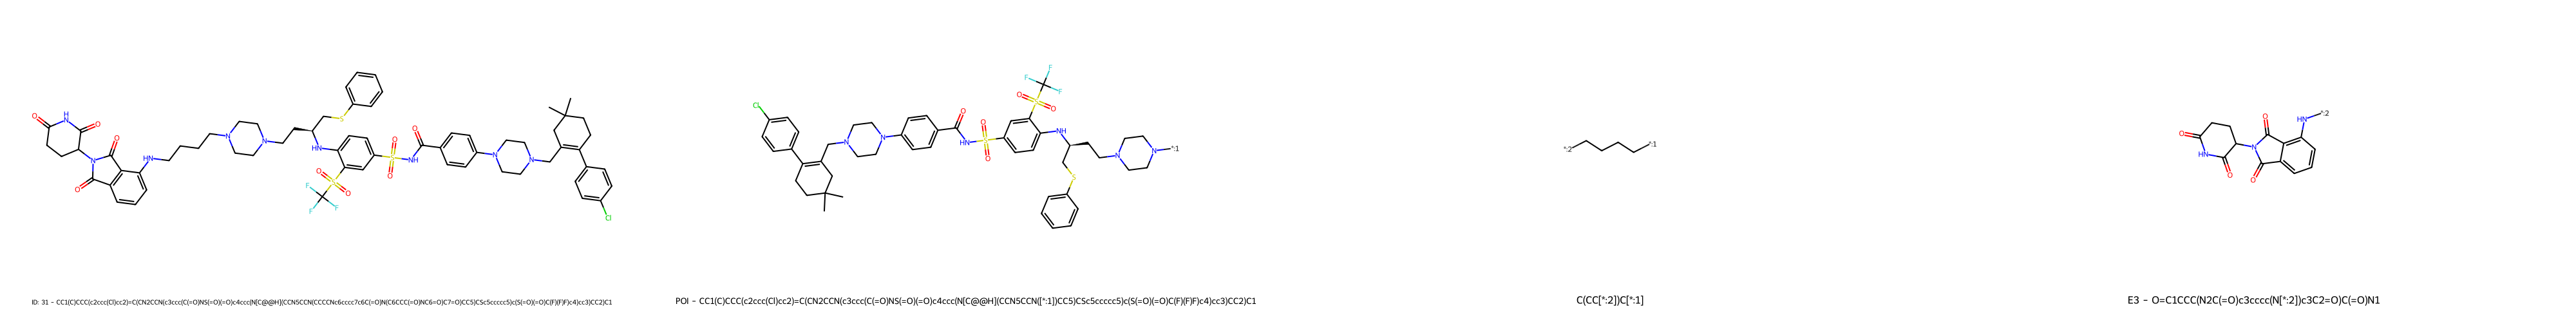

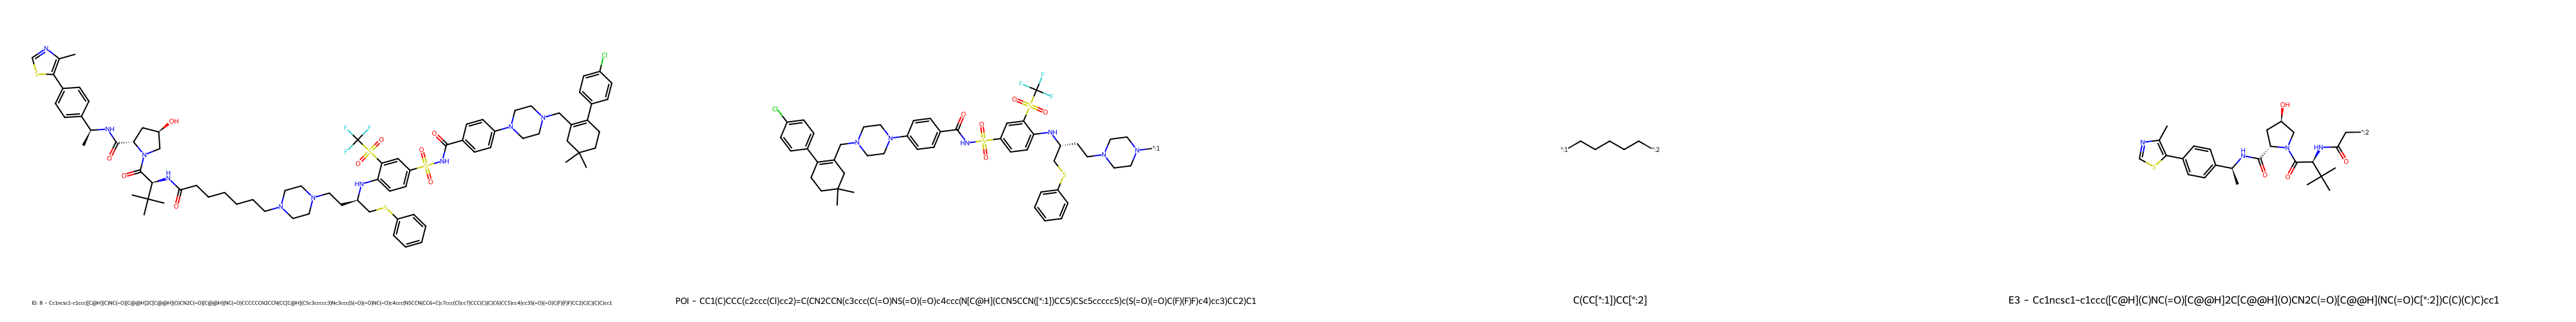

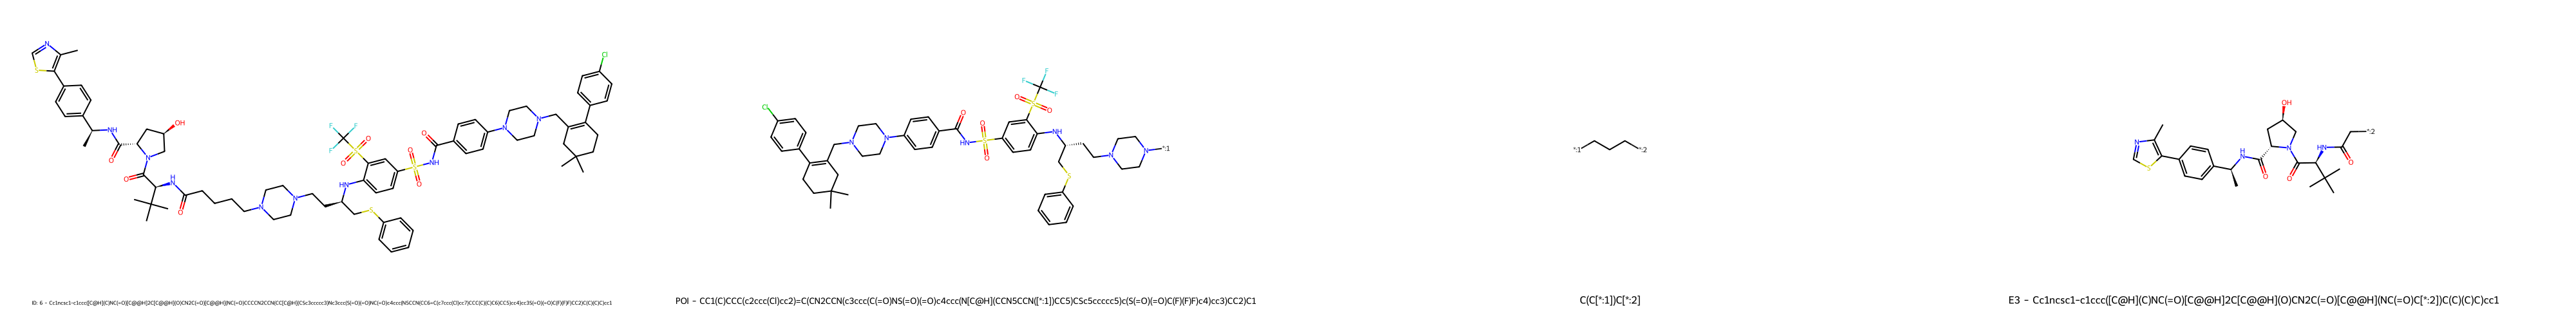

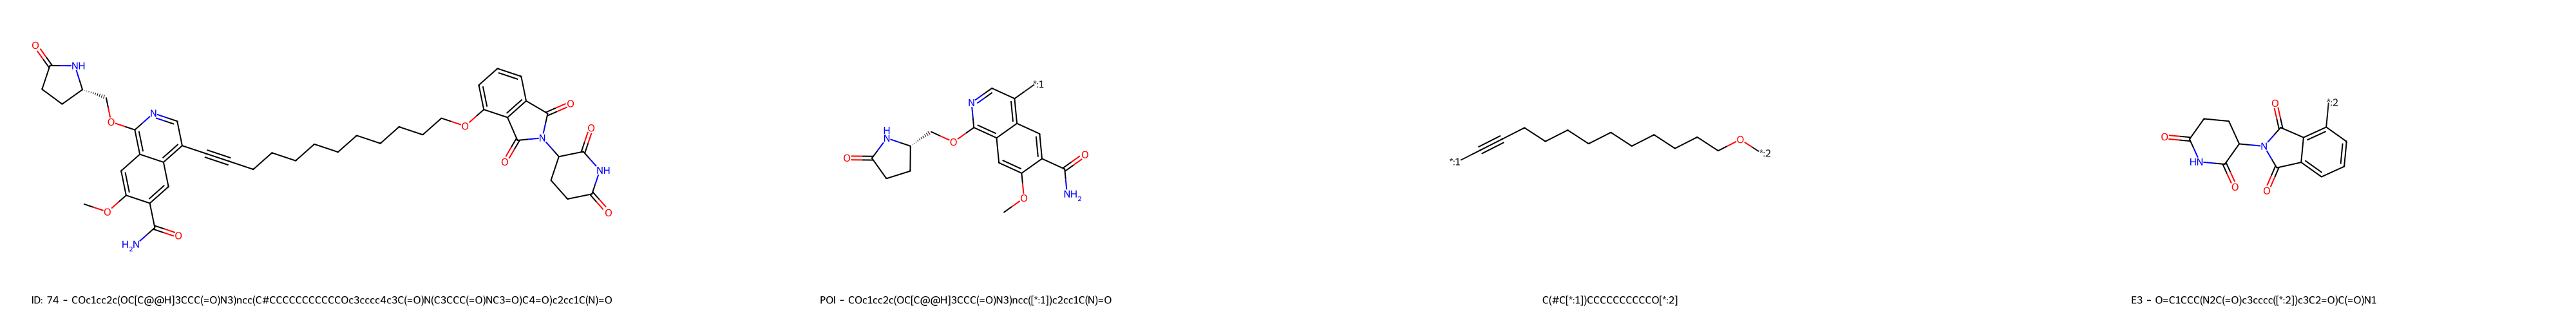

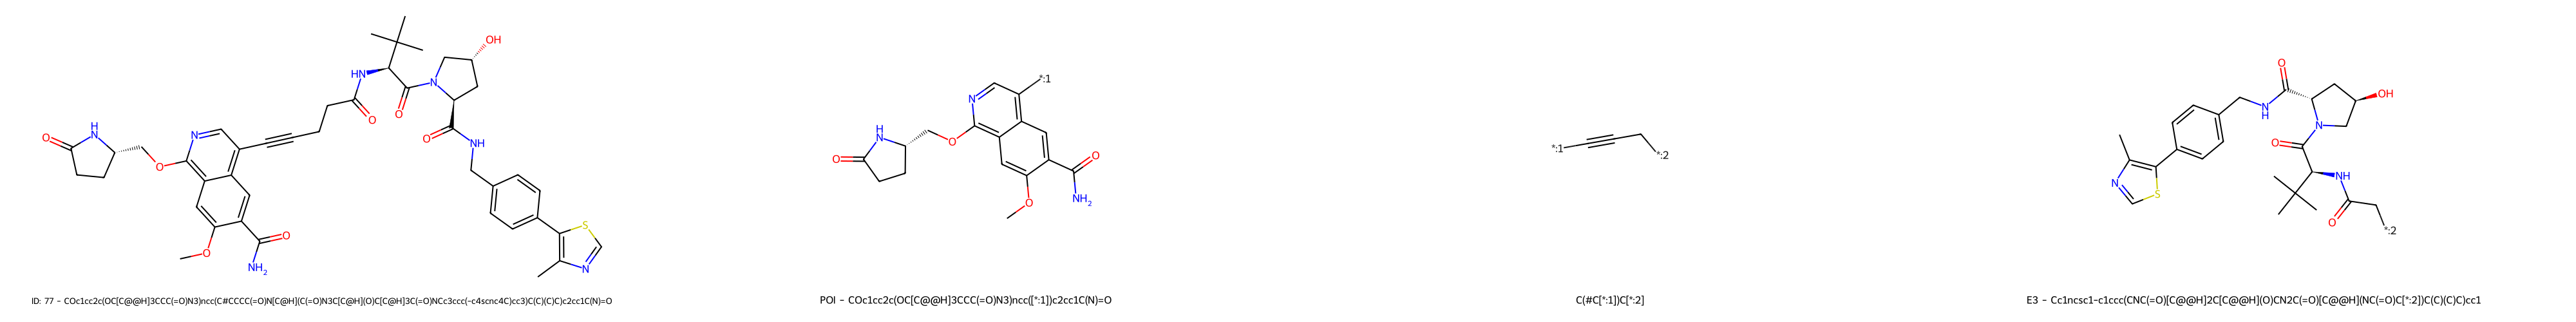

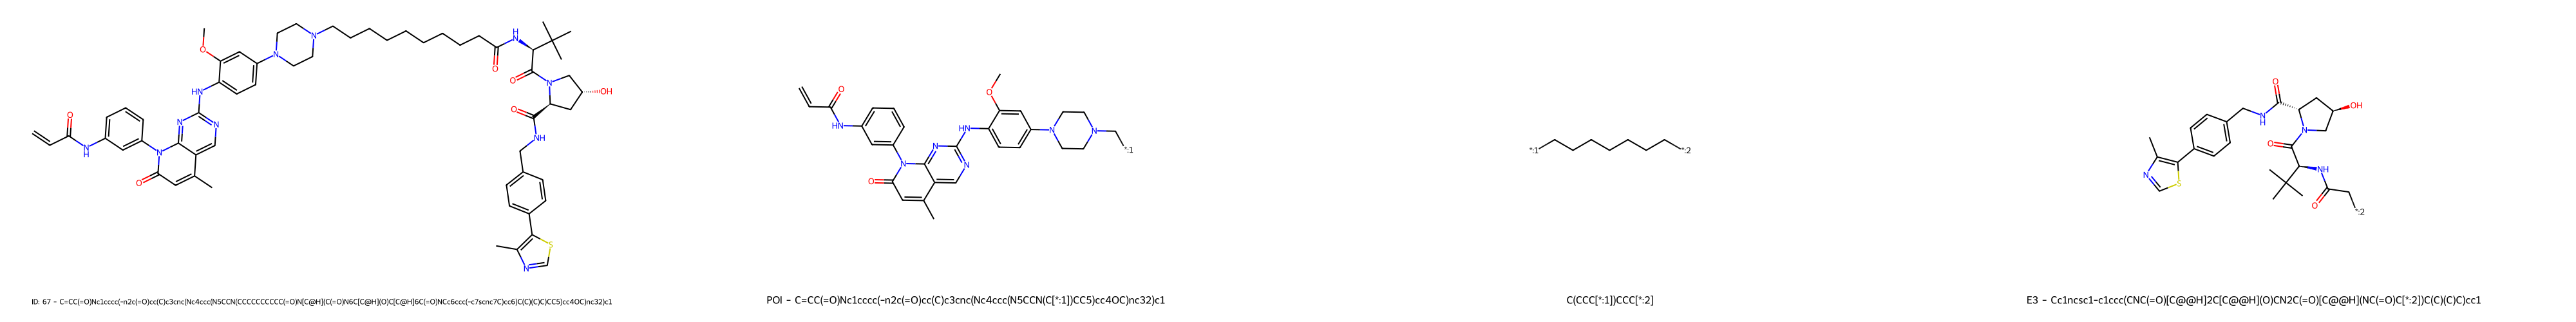

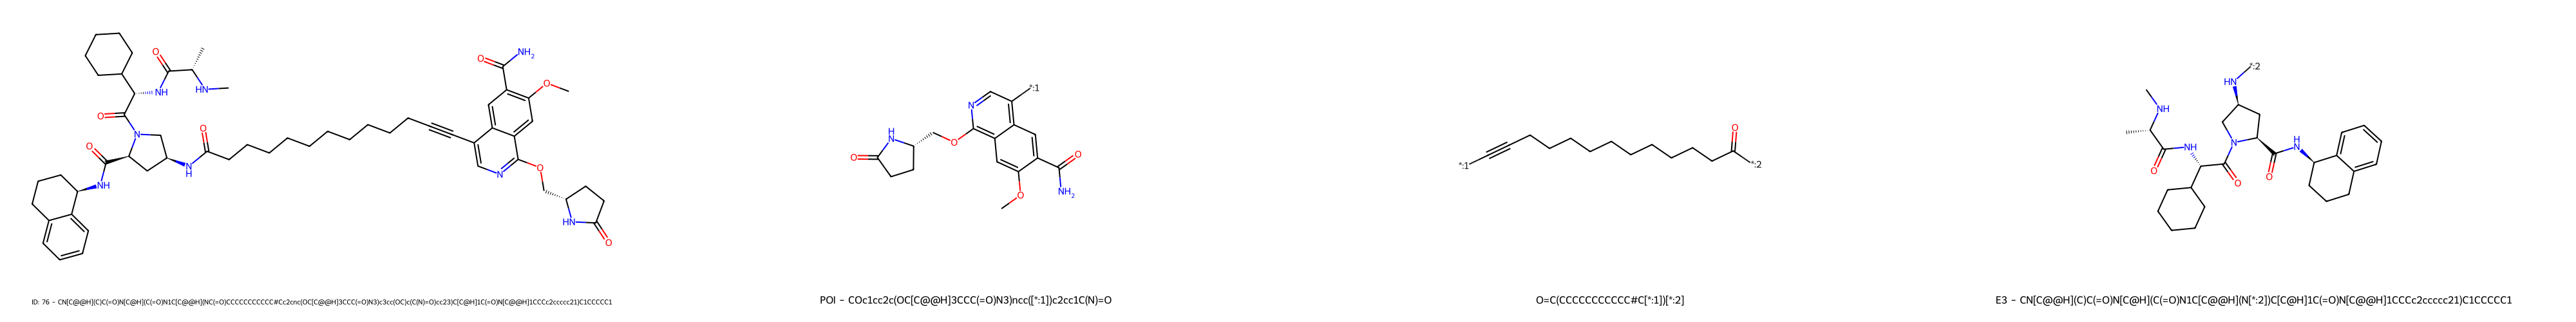

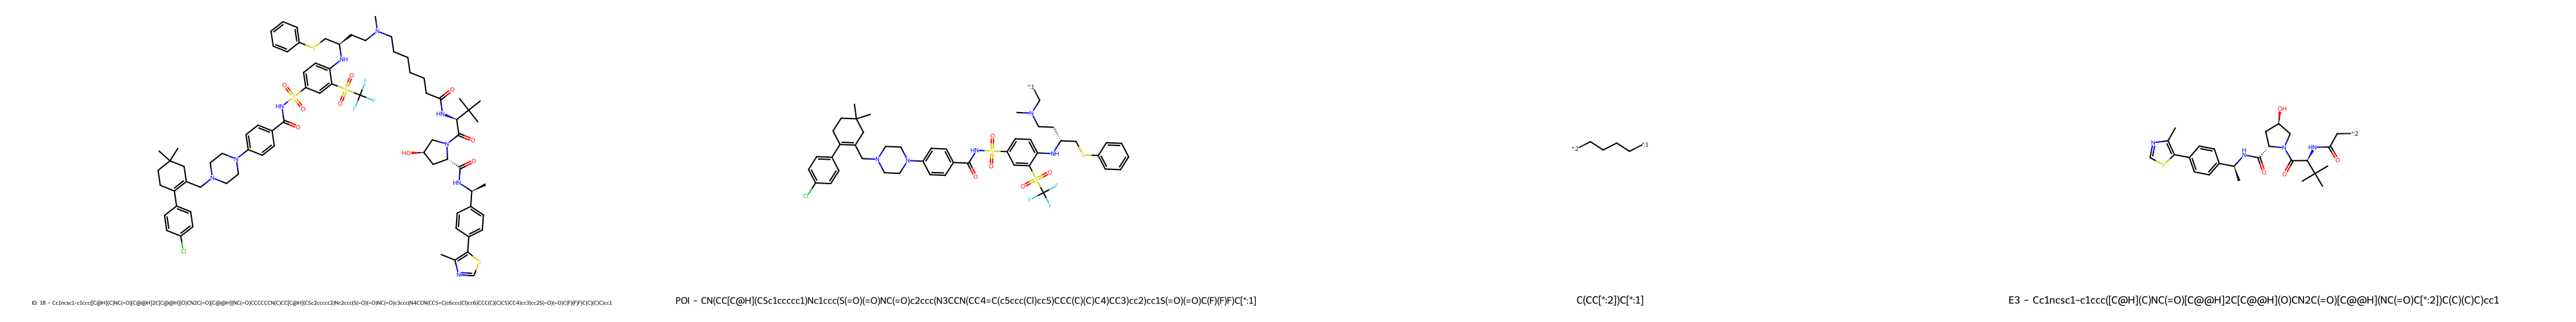

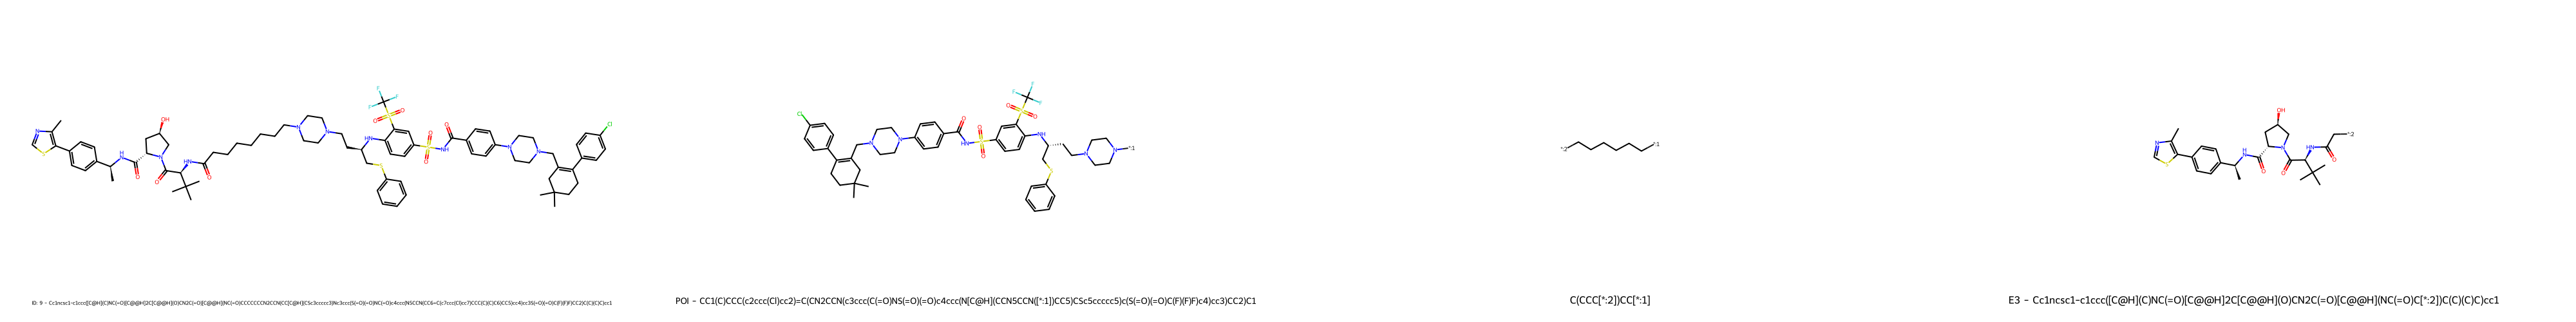

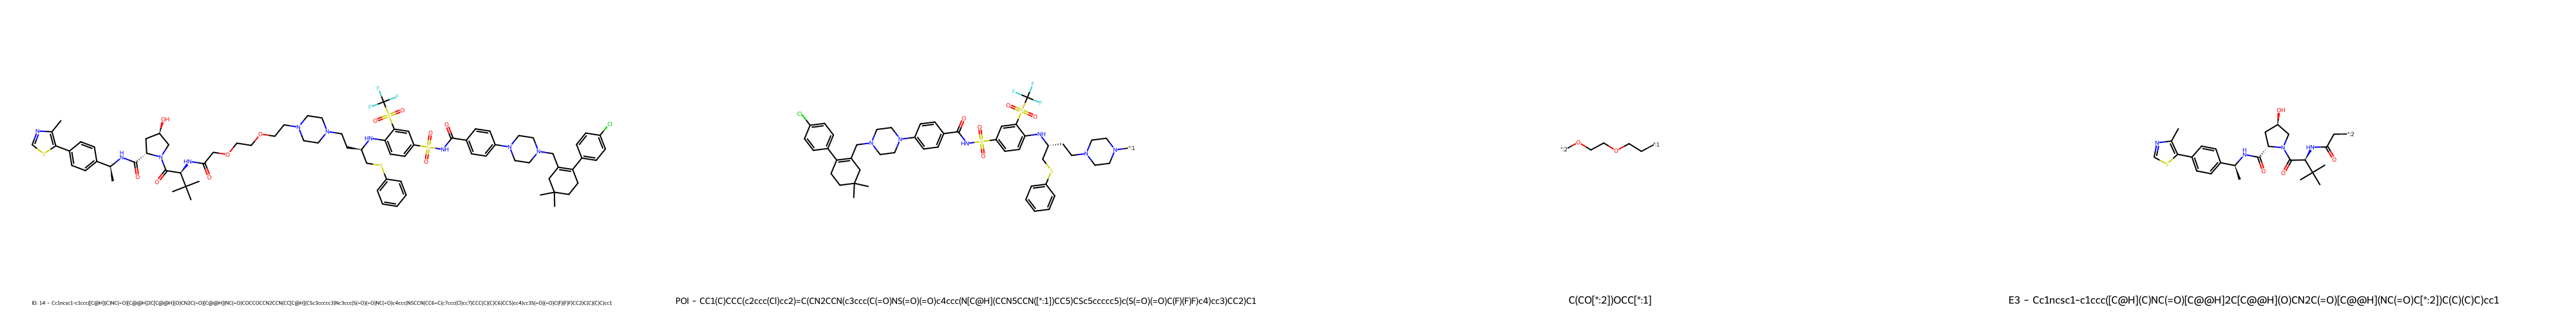

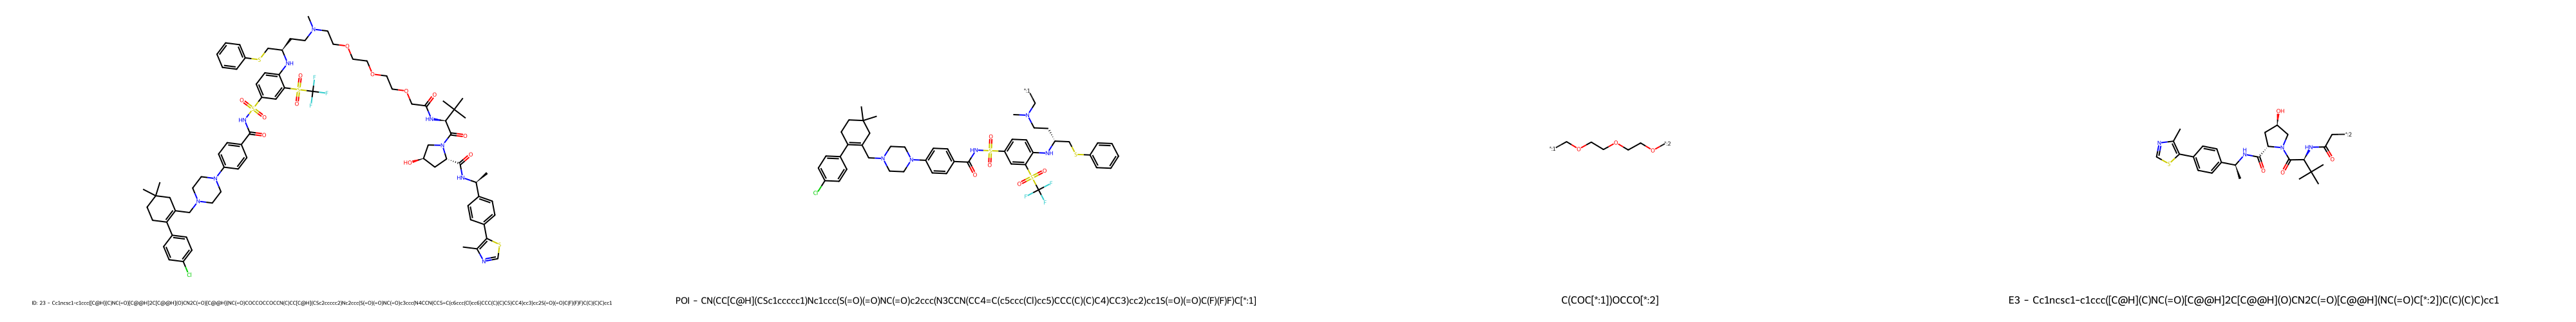

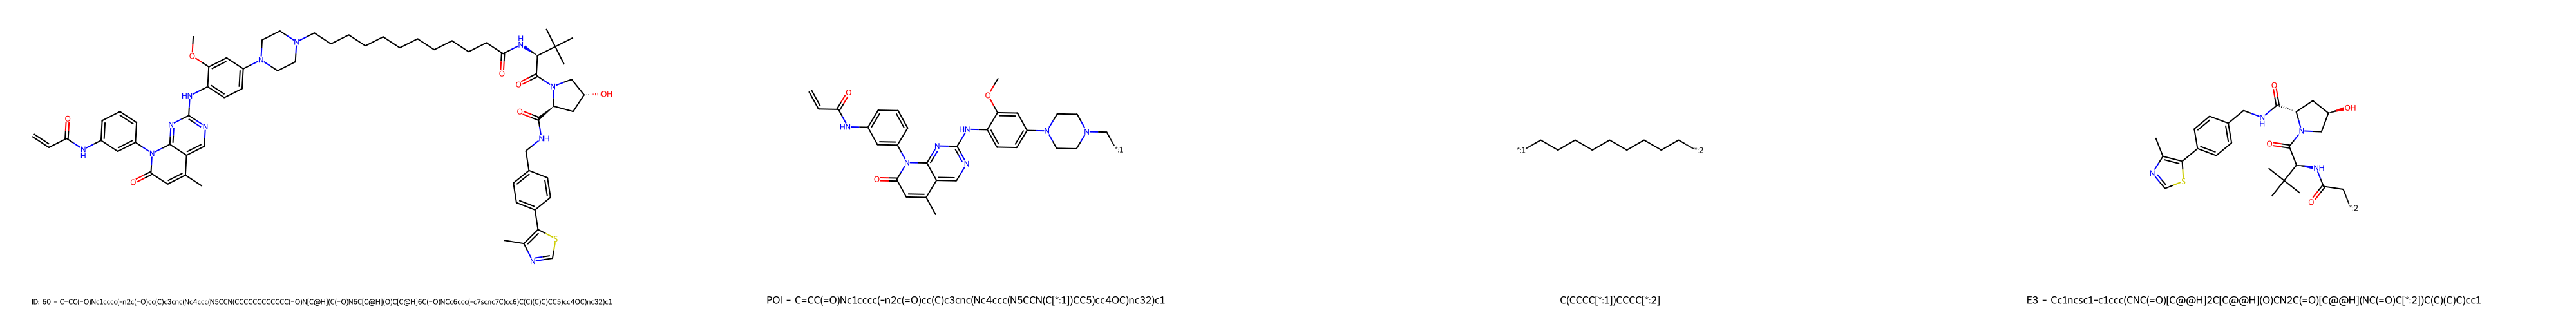

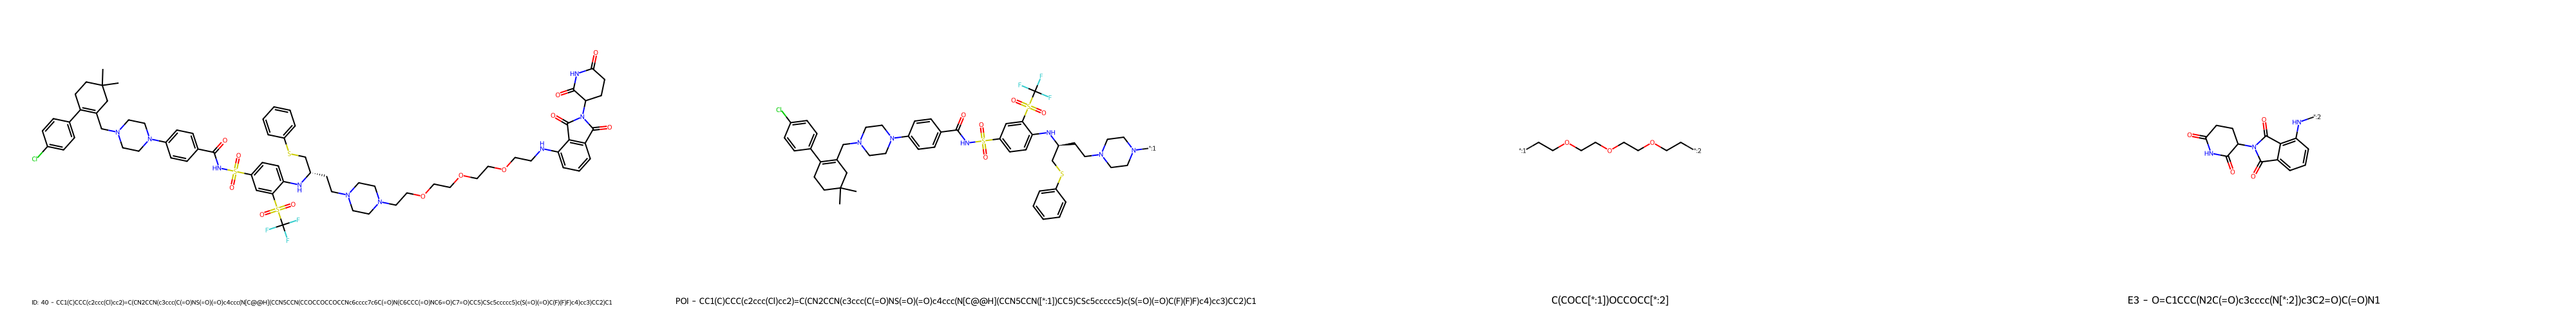

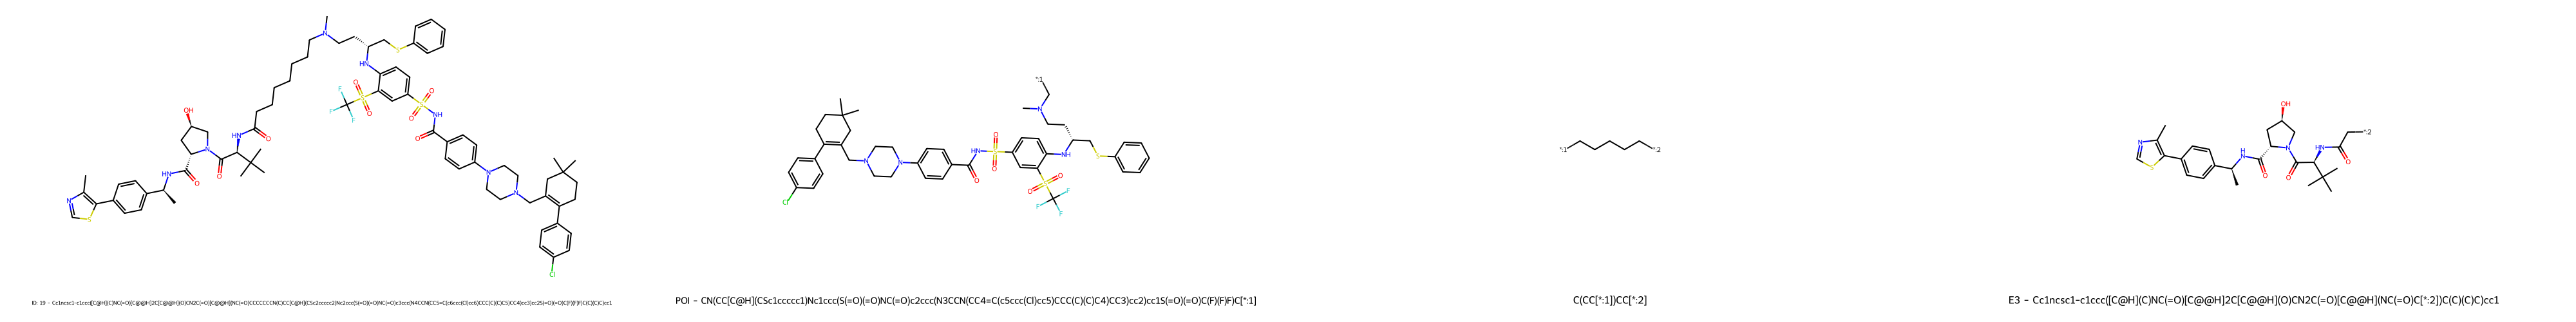

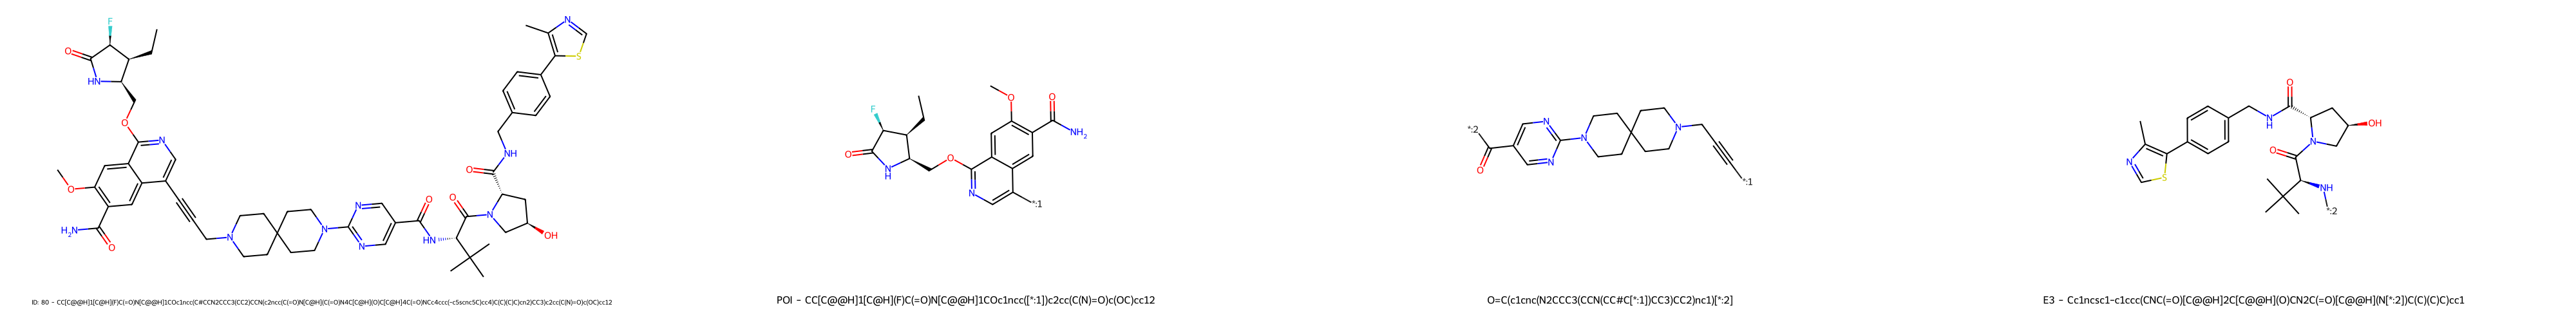

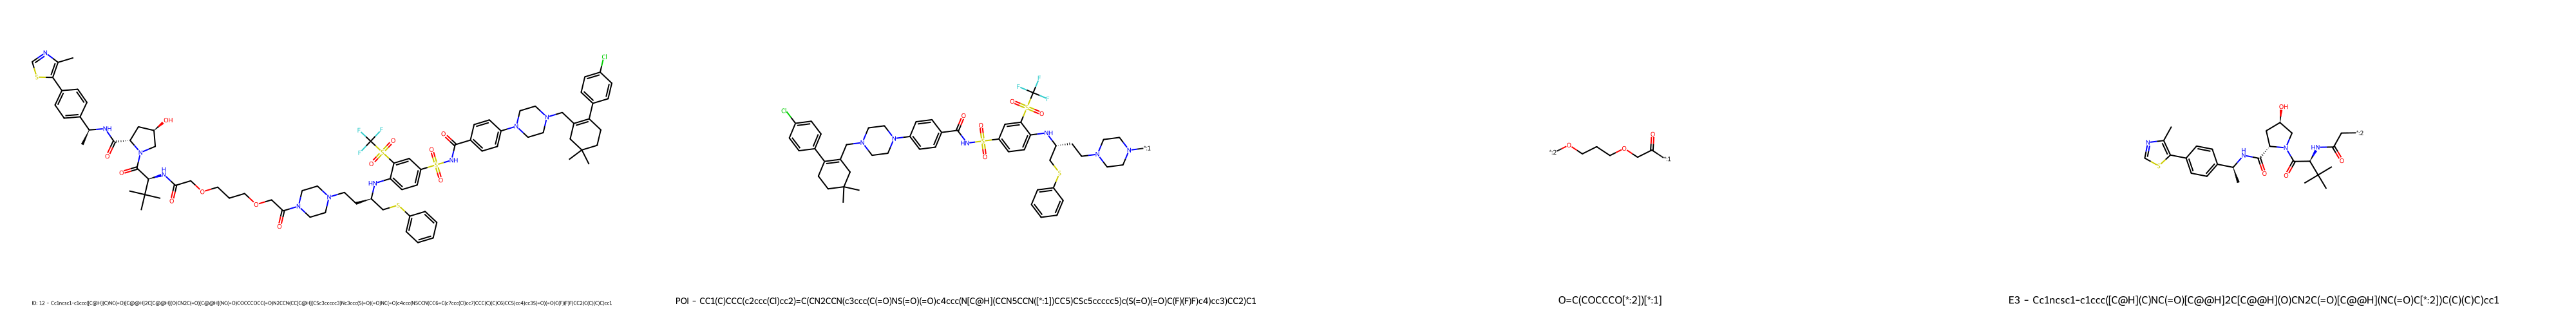

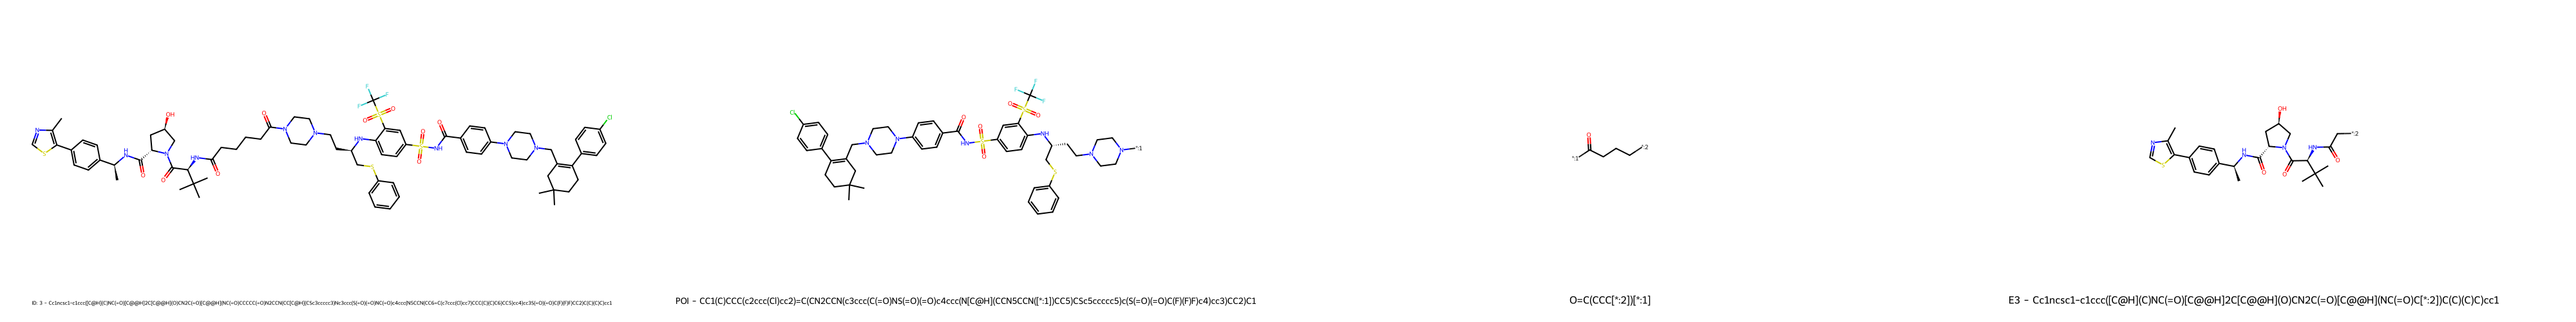

In [22]:
for i, row in mapped_protacs.sample(20).iterrows():
    display_protac_substructures(
            protac_smiles=row['PROTAC SMILES'],
            poi_smiles=row['POI Ligand SMILES with direction'],
            linker_smiles=row['Linker SMILES with direction'],
            e3_smiles=row['E3 Binder SMILES with direction'],
            compound_id=row["PROTAC ID"],
    )

In [26]:
# Update all dictionaries with the substructures of the mapped PROTACs
for substruct in ['POI Ligand', 'E3 Binder', 'Linker with direction']:
    if substruct == 'Linker with direction':
        smiles_list = mapped_protacs[f'Linker SMILES with direction'].unique()
    else:
        smiles_list = mapped_protacs[f'{substruct} SMILES'].unique()
    dictionaries[substruct] = update_dictionary(dictionaries[substruct], smiles_list)

In [28]:
non_mapped_protacs = dictionaries['PROTAC'][~dictionaries['PROTAC']['SMILES'].isin(mapped_protacs['PROTAC SMILES'])].copy()
new_mapped_protacs = map_protacs(non_mapped_protacs, max_iter_on_linkers=0)

PROTAC n.5678: 100%|██████████| 2507/2507 [05:25<00:00,  7.71it/s, len mapped=0, perc total=0.0%]


In [29]:
tmp = pd.concat([mapped_protacs, new_mapped_protacs], axis=0)
print(f'Number of mapped PROTACs: {len(tmp)} ({len(tmp) / len(dictionaries["PROTAC"]):.2%})')
tmp.to_csv(os.path.join(data_dir, 'processed', 'mapped_protacs.csv'), index=False)

Number of mapped PROTACs: 3173 (55.86%)


3211


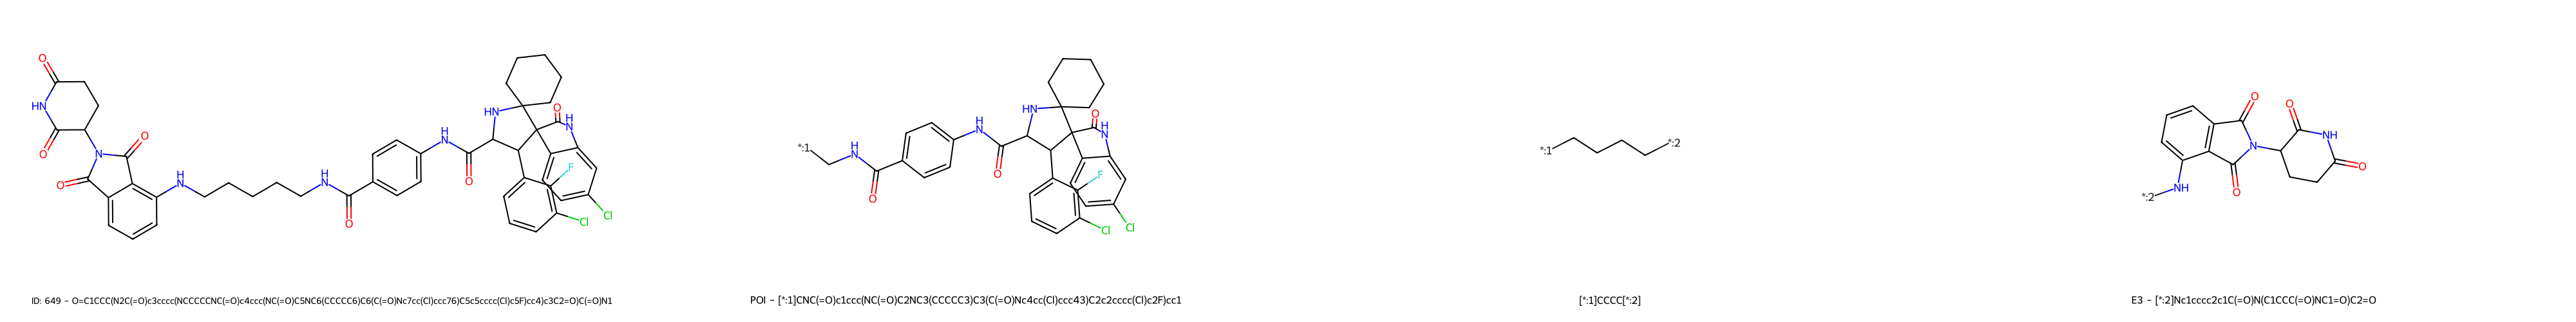

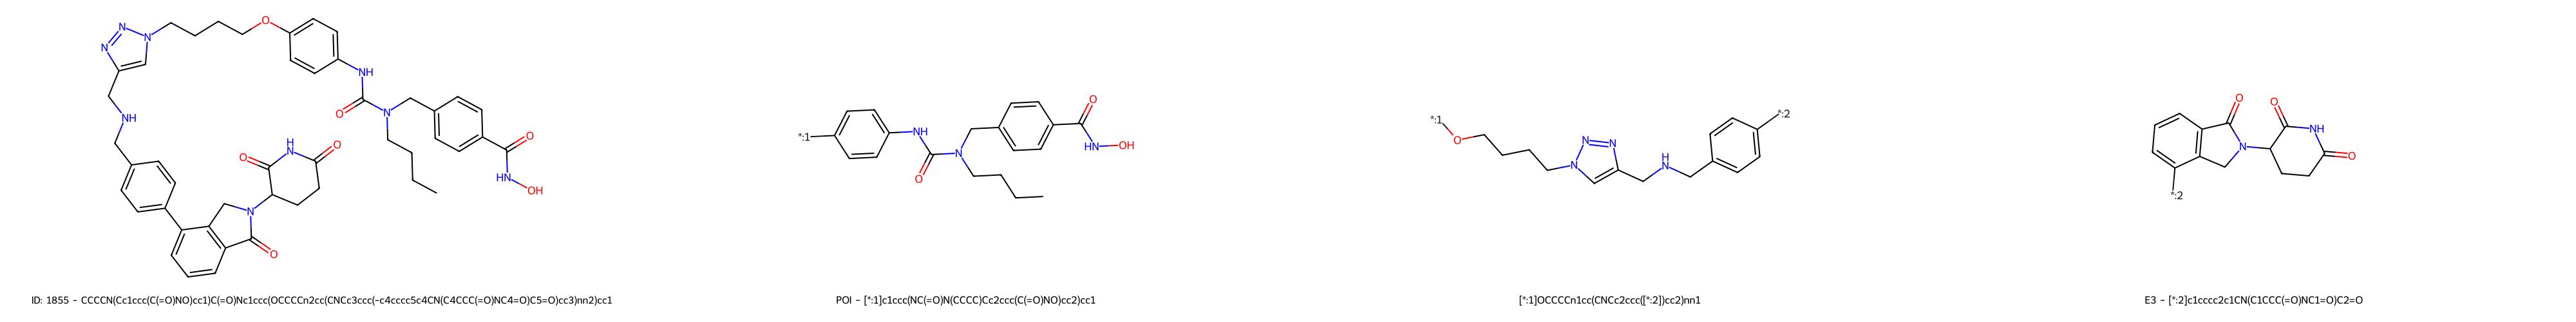

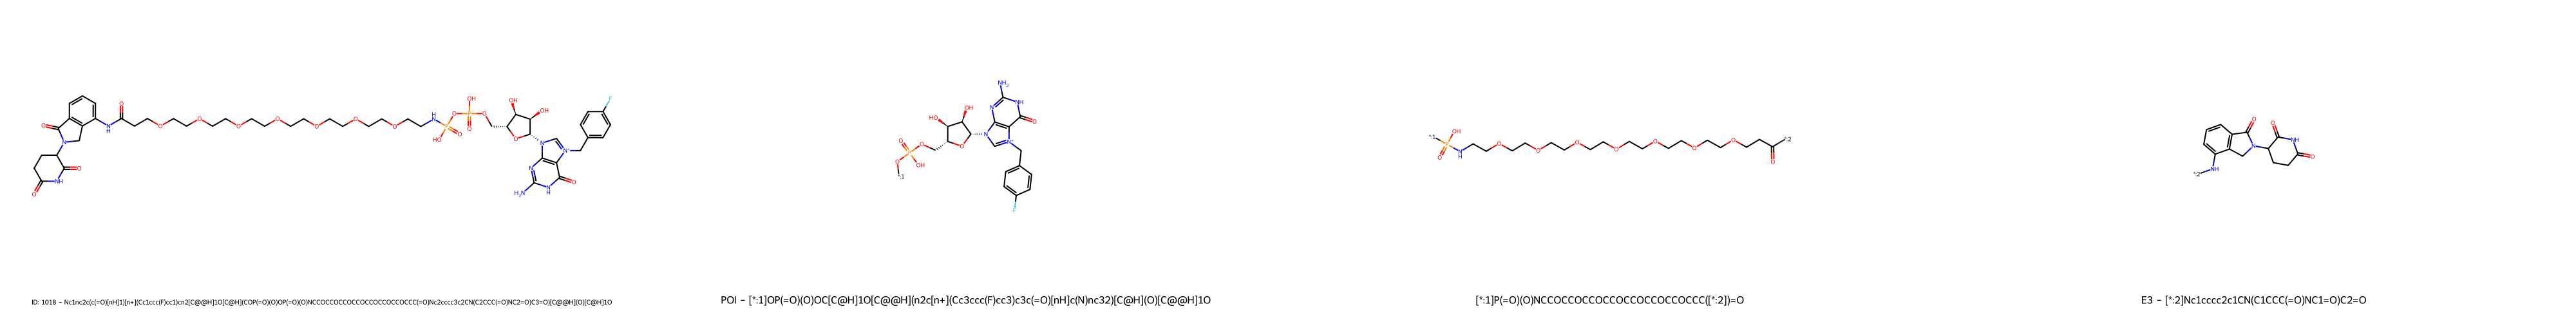

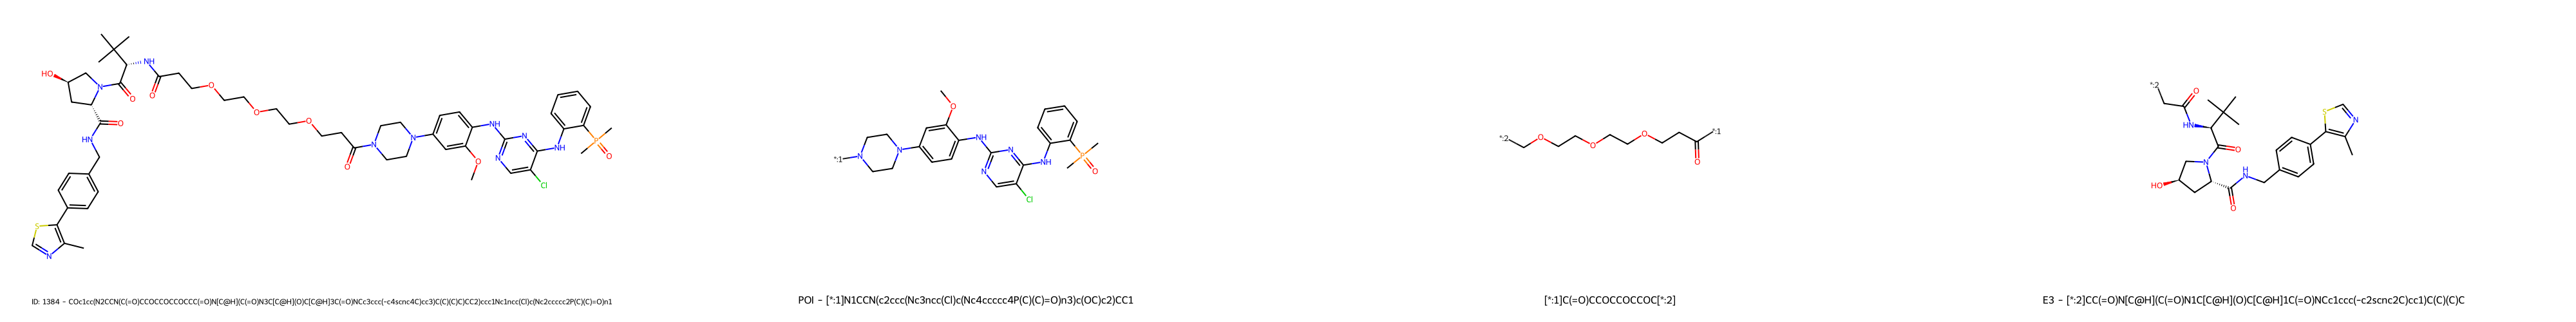

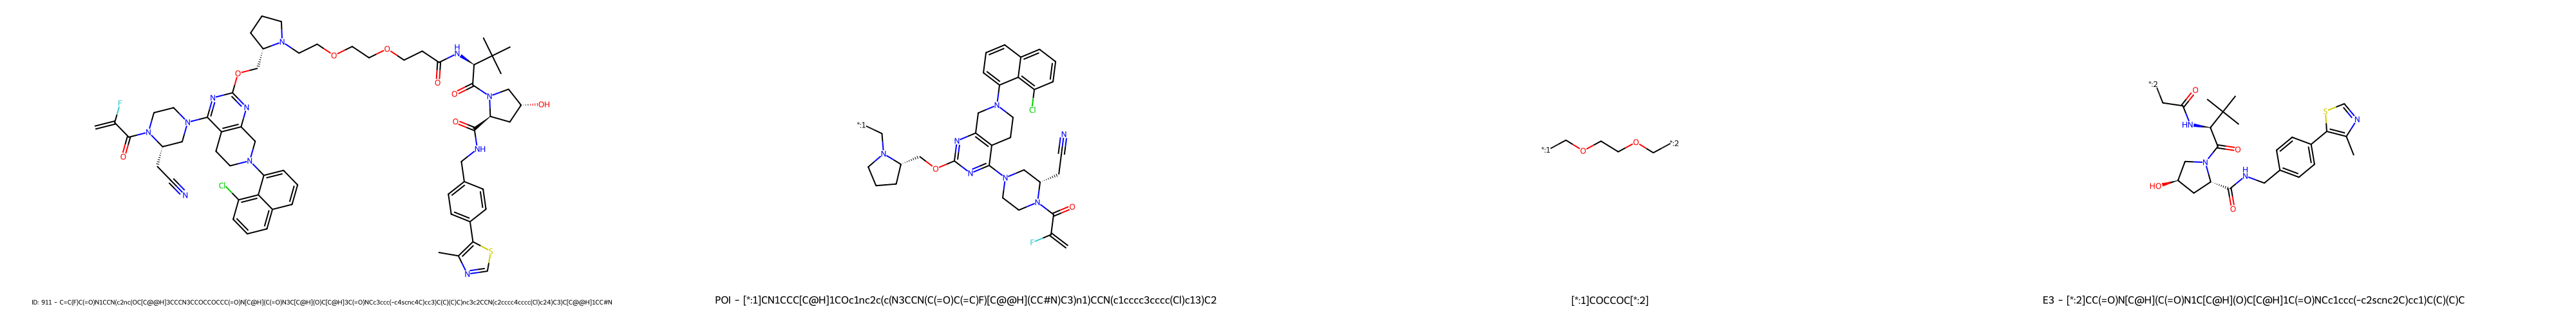

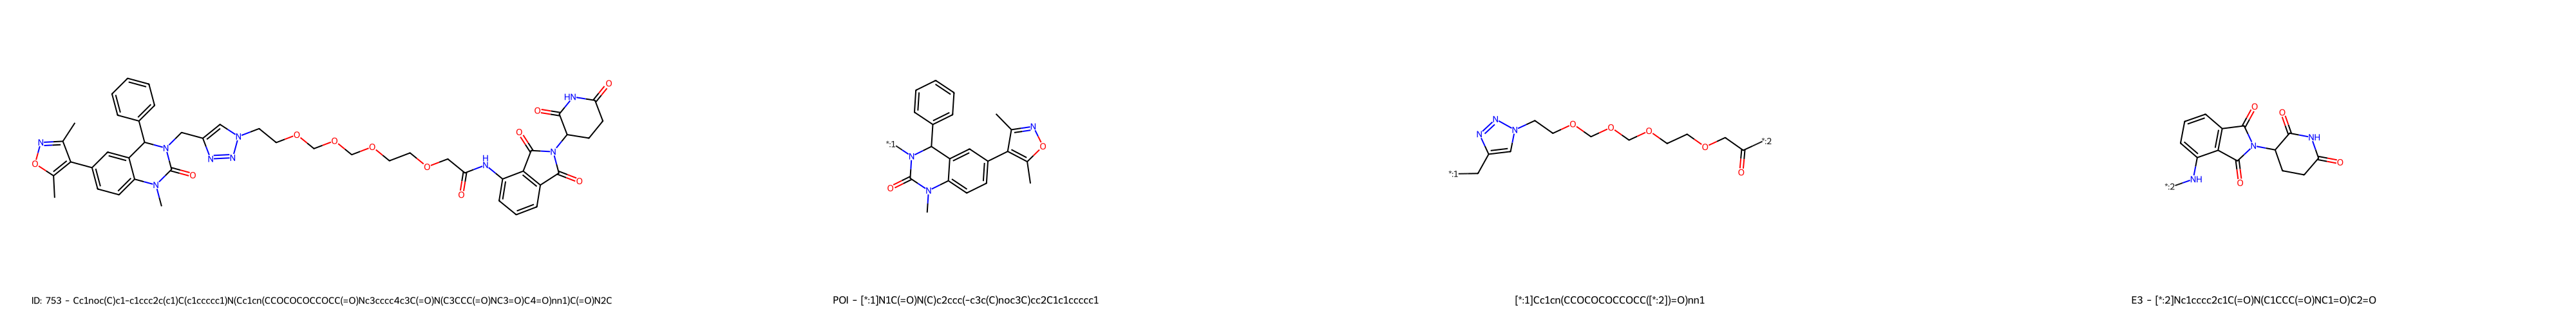

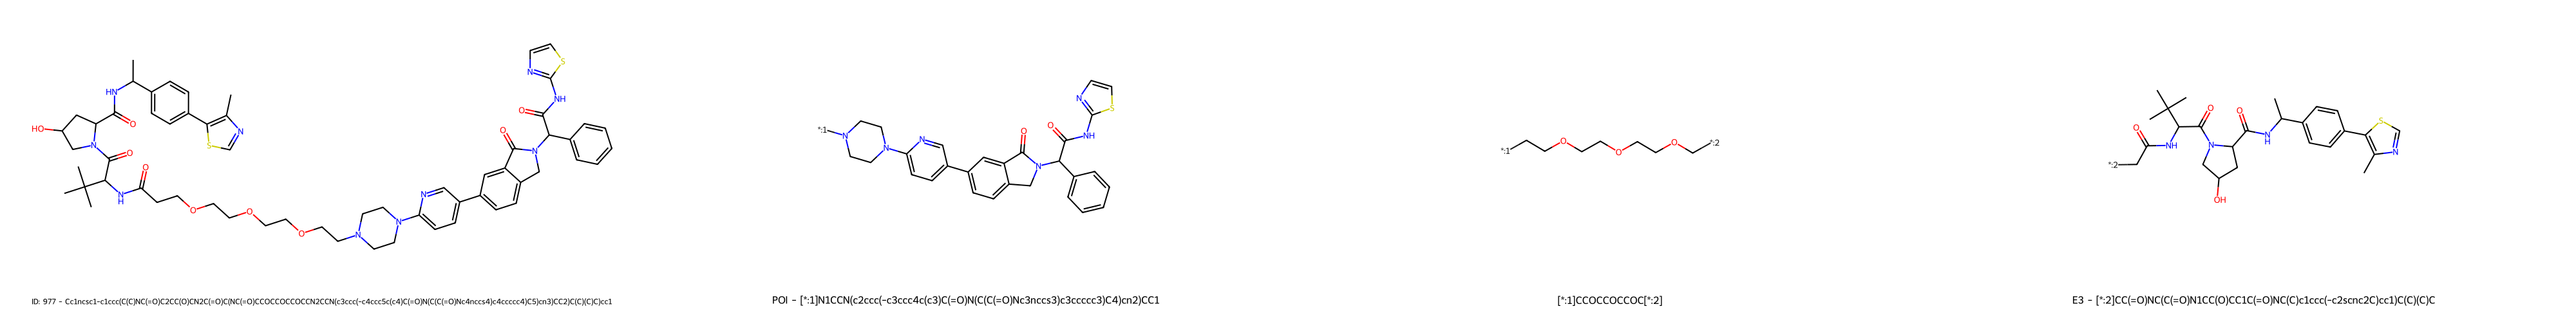

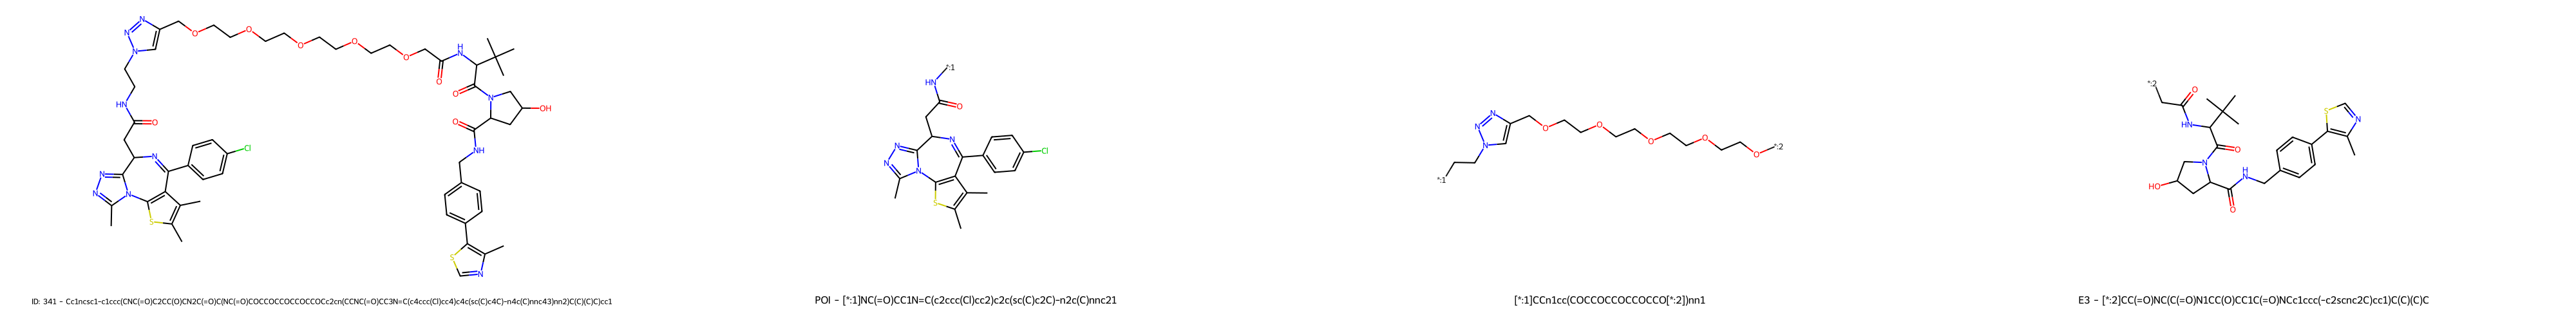

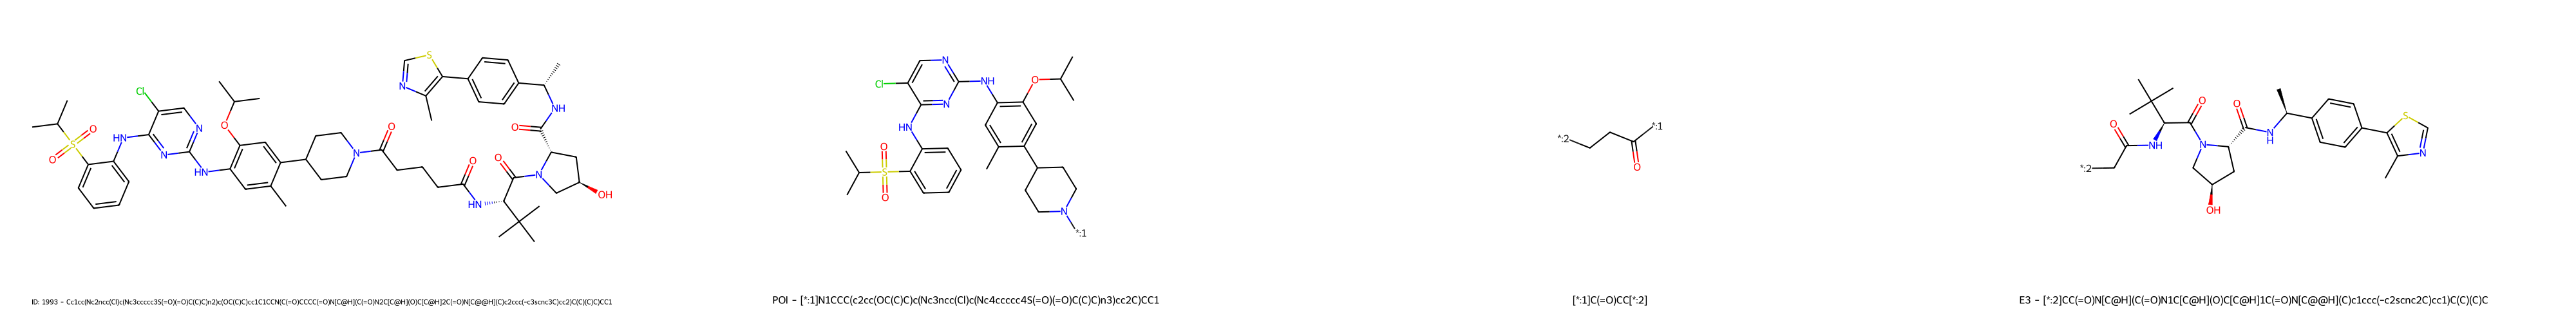

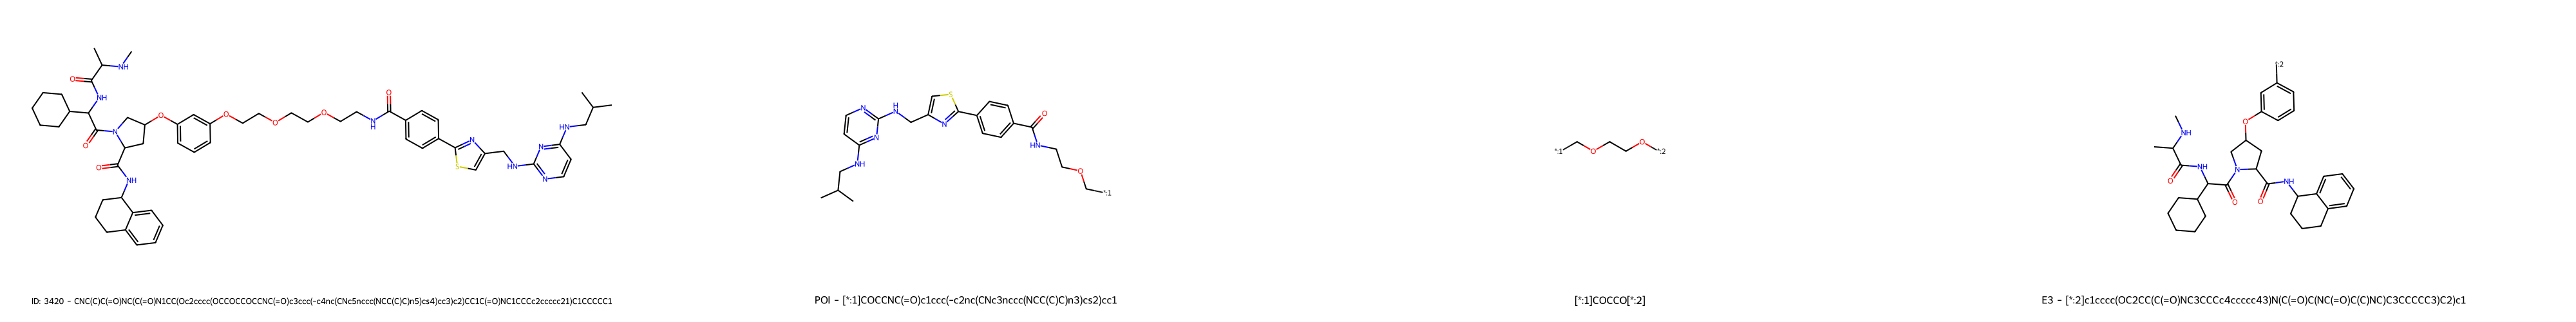

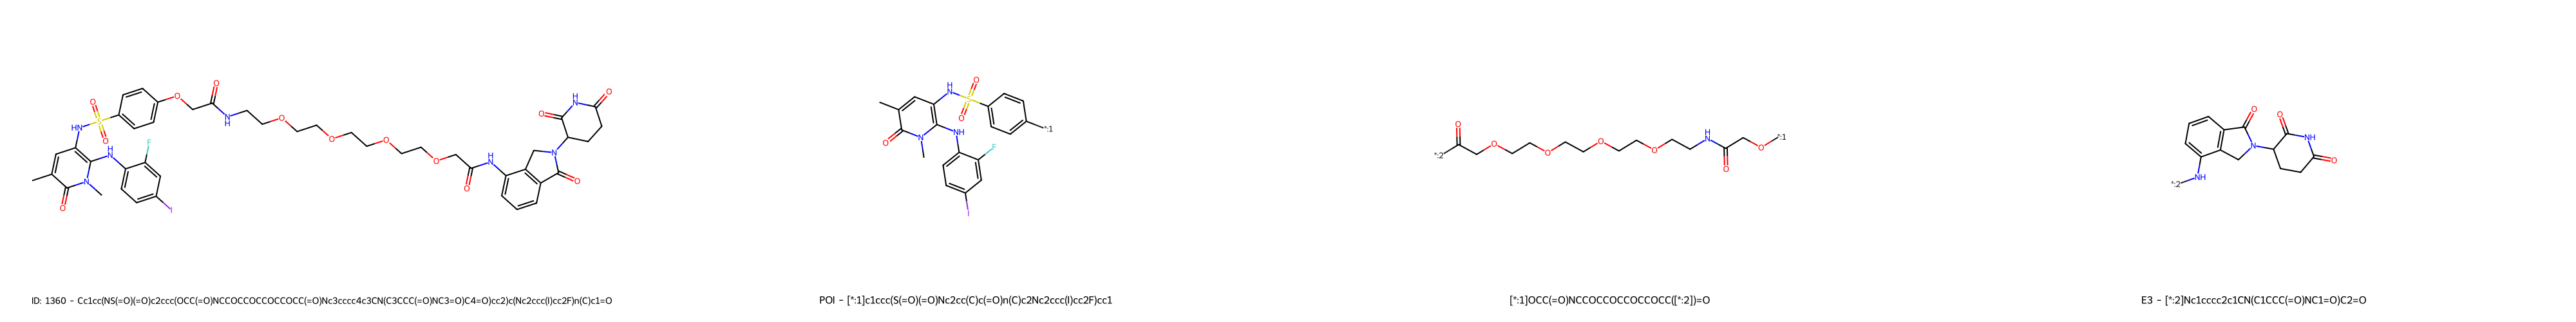

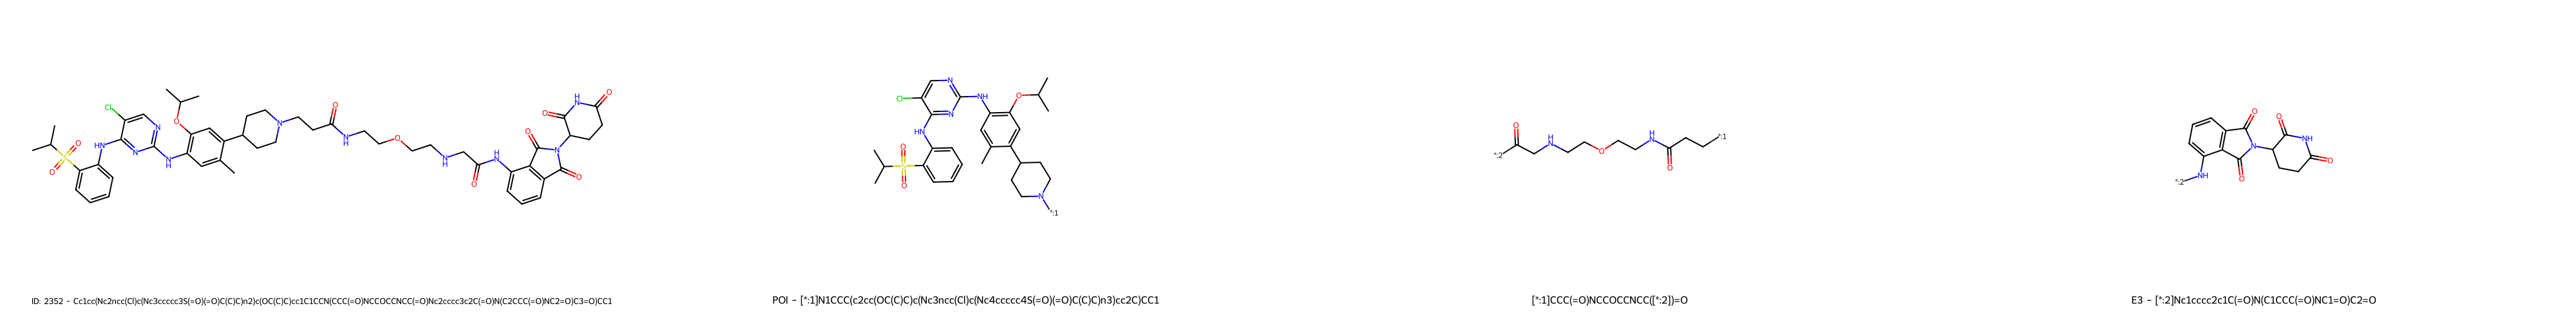

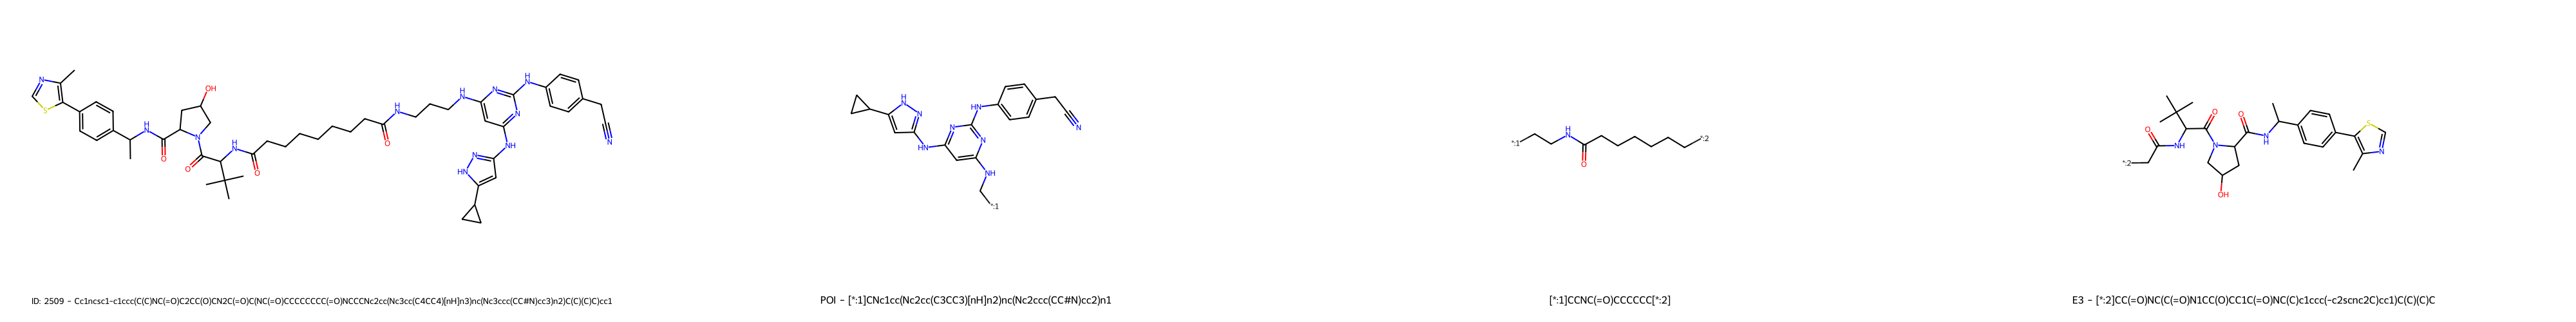

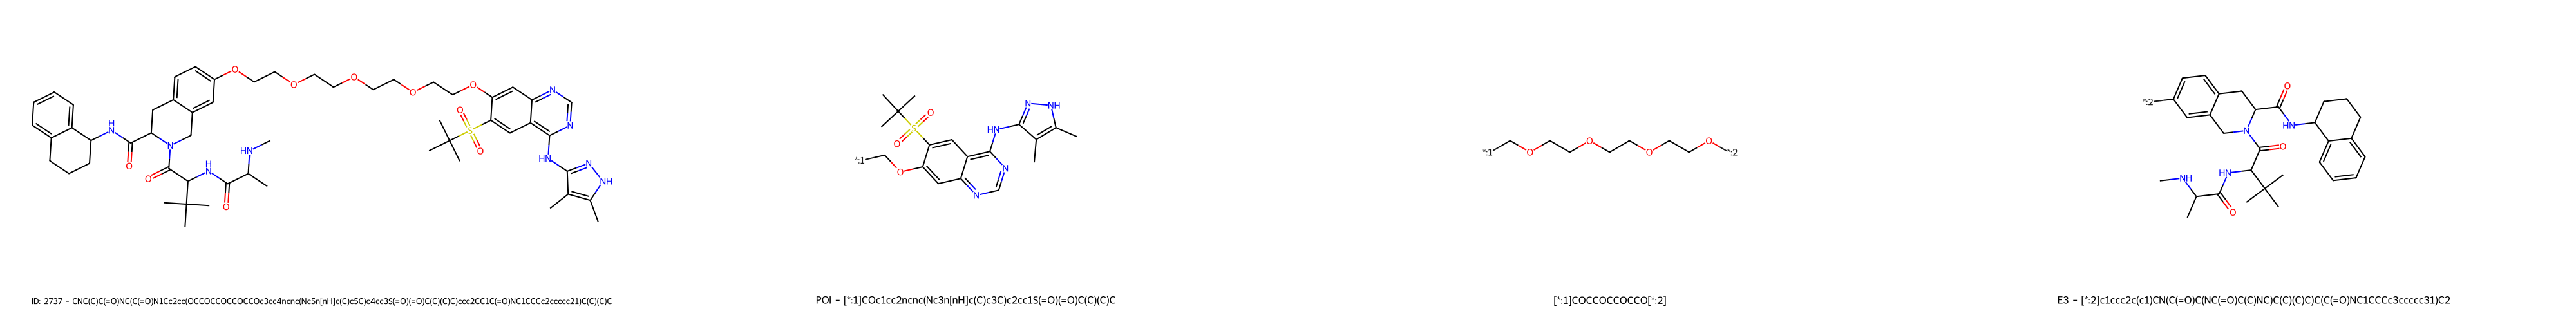

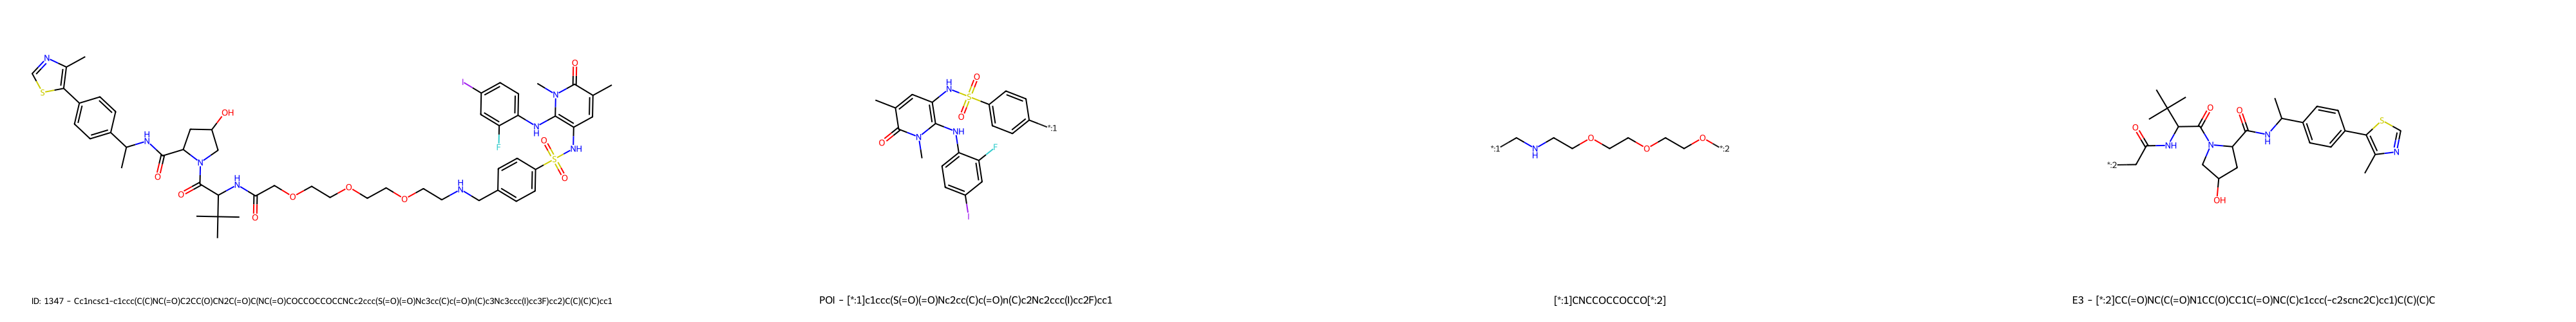

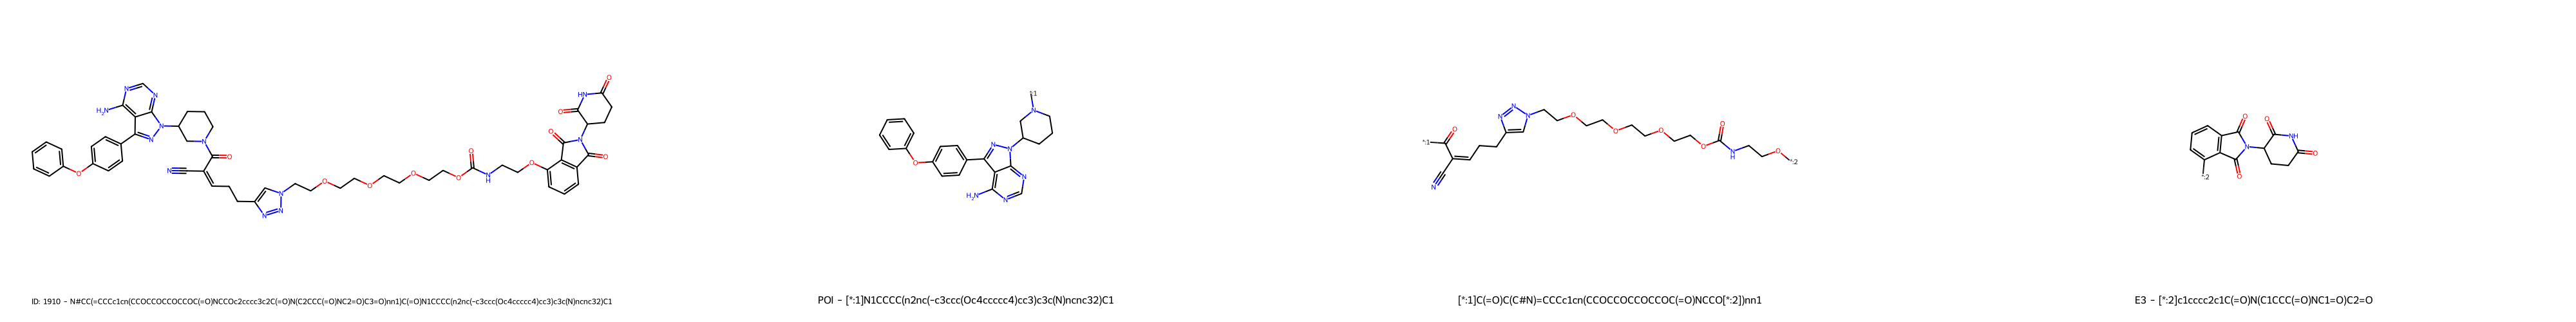

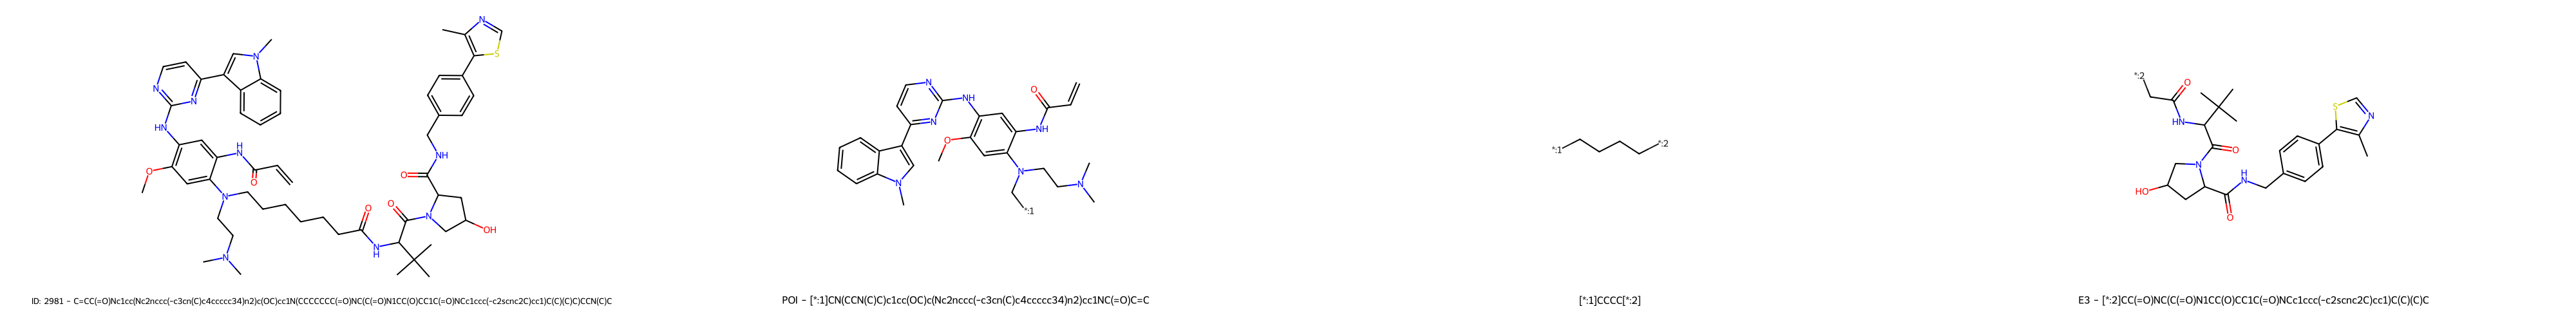

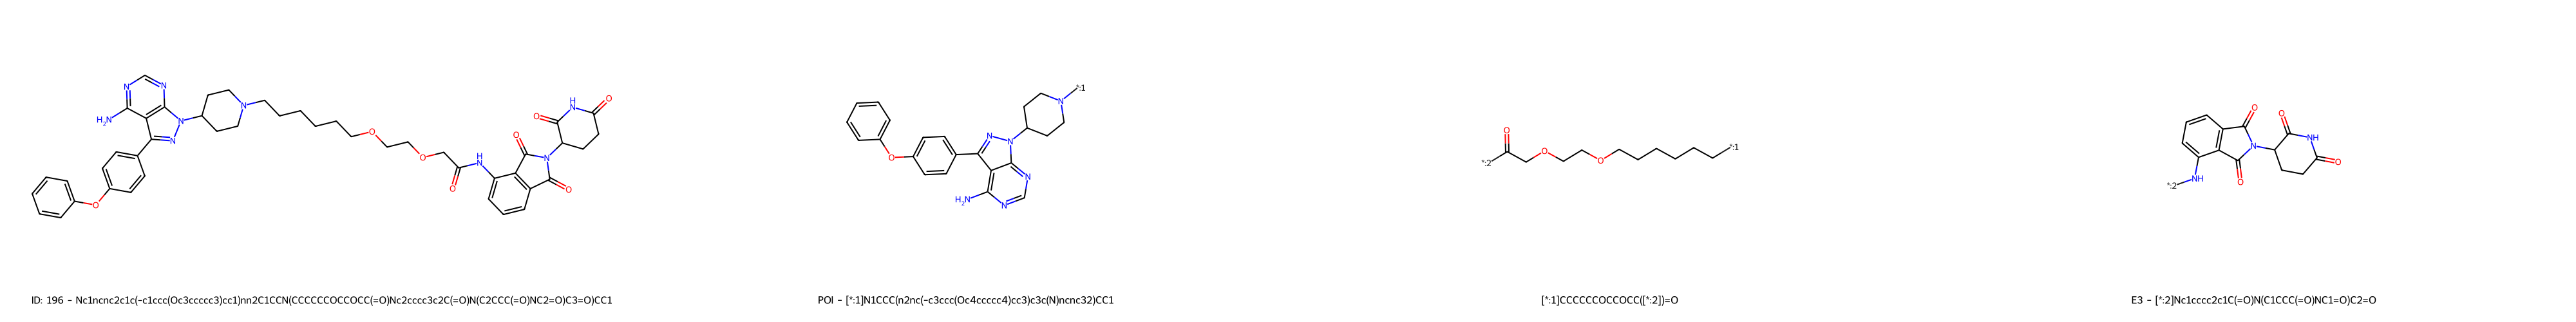

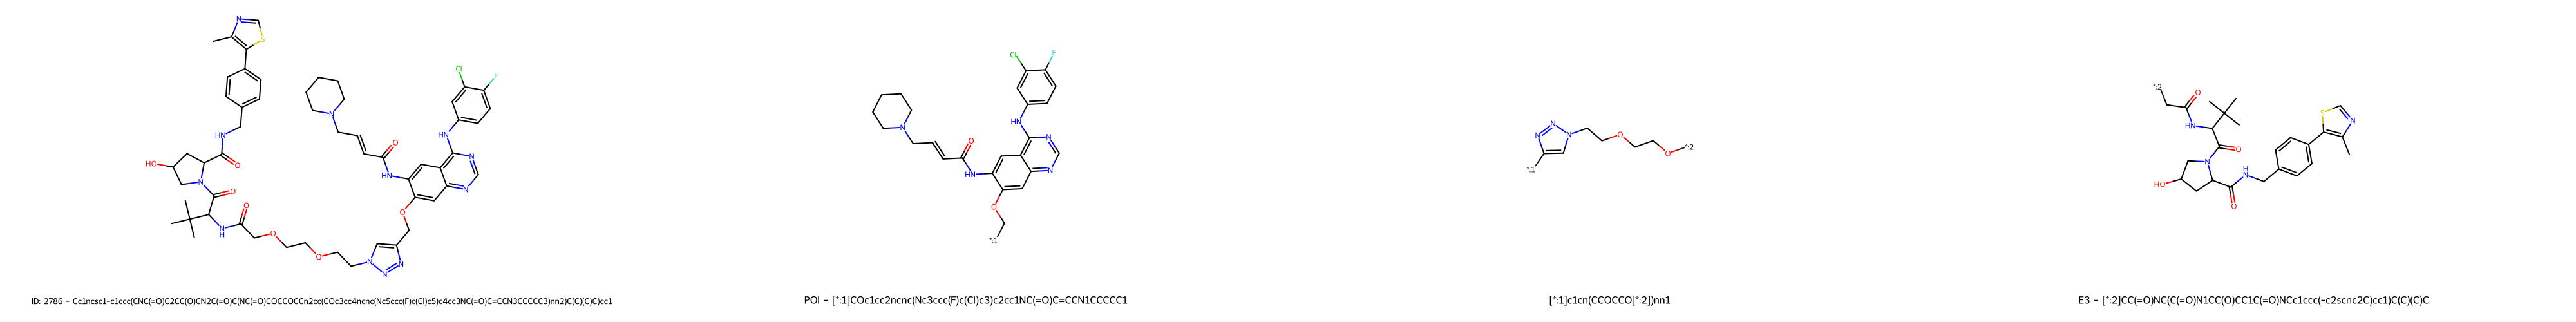

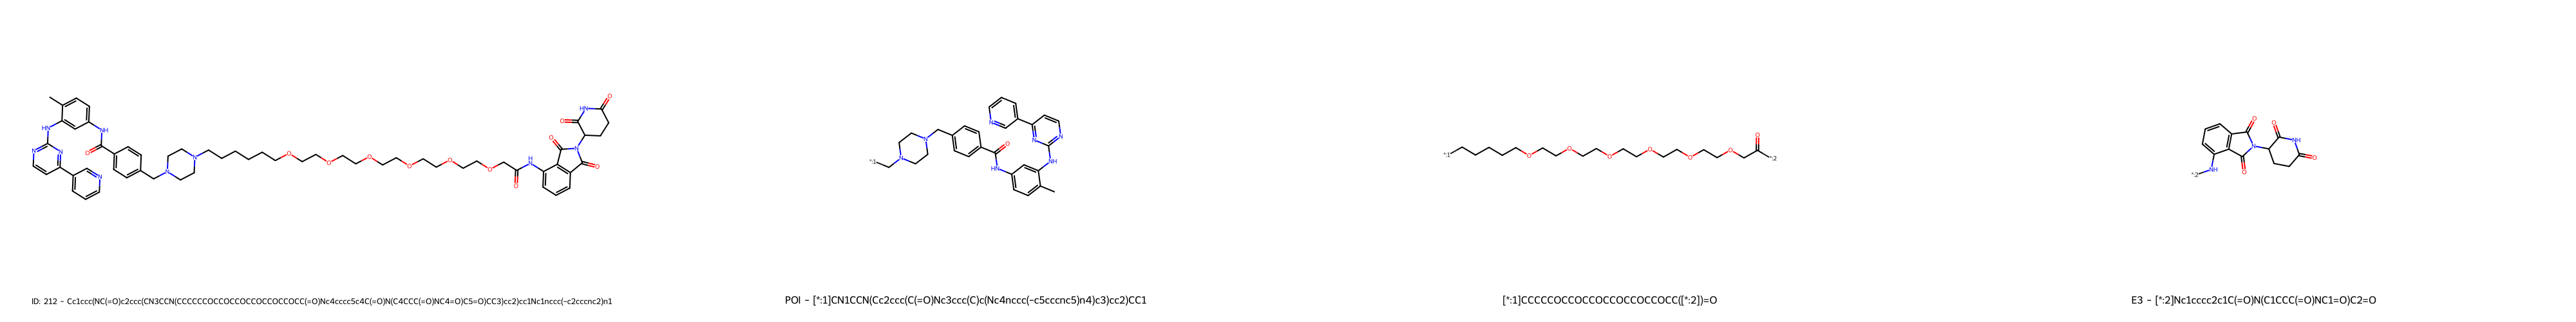

In [186]:
tmp = pd.concat([mapped_protacs, new_mapped_protacs], axis=0)
print(len(tmp))

# Save tmp to a file
tmp[[c for c in tmp.columns if 'SMILES' in c]].to_csv(os.path.join(data_dir, 'processed', 'mapped_protacs.csv'), index=False)

for i, row in tmp.sample(20).iterrows():
    compound_id = row['PROTAC ID']
    protac_smiles = row['PROTAC SMILES']
    e3_smiles = row['E3 Binder SMILES with direction']
    poi_smiles = row['POI Ligand SMILES with direction']
    linker_smiles = row['Linker SMILES with direction']
    
    protac_mol = Chem.MolFromSmiles(protac_smiles)
    e3_mol = Chem.MolFromSmiles(e3_smiles)
    poi_mol = Chem.MolFromSmiles(poi_smiles)
    linker_mol = Chem.MolFromSmiles(linker_smiles)

    legends = [
        f'ID: {compound_id} - {protac_smiles}',
        f'POI - {poi_smiles}',
        f'{linker_smiles}',
        f'E3 - {e3_smiles}',
    ]
    img = Draw.MolsToGridImage([protac_mol, poi_mol, linker_mol, e3_mol], molsPerRow=4, subImgSize=(1000, 500), legends=legends)
    safe_display(img)

## ---------------------------

## Legacy Code From Here On...

Canonize, then drop NaN and duplicates:

In [28]:
# Canonicalize SMILES
# PROTAC-Pedia
smiles_cols = [
    'PROTAC SMILES',
    'E3 Binder SMILES',
    'Linker SMILES',
    'POI Ligand SMILES',
]
for col in smiles_cols:
    tqdm.pandas(desc=f'Canonizing {col}')
    protac_pedia_df[col] = protac_pedia_df[col].progress_apply(canonize_smiles)
# PROTAC-DB related
protac_db_df['PROTAC SMILES'] = protac_db_df['PROTAC SMILES'].progress_apply(canonize_smiles)
protac_db_linker_df['Linker SMILES'] = protac_db_linker_df['Linker SMILES'].progress_apply(canonize_smiles)
# protac_db_linker_df['Linker SMARTS'] = protac_db_linker_df['Linker SMARTS'].progress_apply(clean_smarts)
protac_db_e3_df['E3 Binder SMILES'] = protac_db_e3_df['E3 Binder SMILES'].progress_apply(canonize_smiles)
protac_db_poi_df['POI Ligand SMILES'] = protac_db_poi_df['POI Ligand SMILES'].progress_apply(canonize_smiles)

Canonizing POI Ligand SMILES: 100%|██████████| 1460/1460 [00:00<00:00, 7418.88it/s]


Create a dictionary to map each unique PROTAC, and its substructures, to a manually assigned unique ID:

(NOTE: it also removes any E3 ligand that appears in the POI substructures)

In [ ]:
smiles2id_dict = {
    'PROTAC': {},
    'POI Ligand': [],
    'Linker': [],
    'E3 Binder': [],
}

# Create a PROTAC ID dictionary for all unique PROTACs
protacs_smiles = protac_pedia_df['PROTAC SMILES'].dropna().unique().tolist()
protacs_smiles += protac_db_df['PROTAC SMILES'].dropna().unique().tolist()
for idx, protac_smiles in enumerate(list(set(protacs_smiles))):
    smiles2id_dict['PROTAC'][protac_smiles] = idx
# Create an additional column in the PROTAC-DB and PROTAC-Pedia dataframes
protac_db_df['PROTAC ID'] = protac_db_df['PROTAC SMILES'].map(smiles2id_dict['PROTAC'])
protac_pedia_df['PROTAC ID'] = protac_pedia_df['PROTAC SMILES'].map(smiles2id_dict['PROTAC'])

for substruct in ['POI Ligand', 'Linker', 'E3 Binder']:
    if substruct == 'POI Ligand':
        substruct_smiles = protac_pedia_df['POI Ligand SMILES'].dropna().unique().tolist()
        substruct_smiles += protac_db_poi_df['POI Ligand SMILES'].dropna().unique().tolist()
    elif substruct == 'Linker':
        substruct_smiles = protac_pedia_df['Linker SMILES'].dropna().unique().tolist()
        substruct_smiles += protac_db_linker_df['Linker SMILES'].dropna().unique().tolist()
    elif substruct == 'E3 Binder':
        substruct_smiles = protac_pedia_df['E3 Binder SMILES'].dropna().unique().tolist()
        substruct_smiles += protac_db_e3_df['E3 Binder SMILES'].dropna().unique().tolist()
    else:
        raise ValueError(f'Unknown substructure: {substruct}')

    # Append the substructure to the list (it will become a dictionary later)
    for smiles in list(set(substruct_smiles)):
        smiles2id_dict[substruct].append(smiles)

# Remove from POI, any substructure that appears in E3
for smiles in smiles2id_dict['POI Ligand']:
    if smiles in smiles2id_dict['E3 Binder']:
        smiles2id_dict['POI Ligand'].remove(smiles)

# Assign a cumulative ID to all substructures
for substruct in ['POI Ligand', 'Linker', 'E3 Binder']:
    list_of_smiles = list(smiles2id_dict[substruct]).copy()
    smiles2id_dict[substruct] = {}
    for idx, smiles in enumerate(list_of_smiles):
        smiles2id_dict[substruct][smiles] = idx

# Reporting
for substruct, d in smiles2id_dict.items():
    print(f'{substruct}: {len(d)}')

Later we will use the dictionaries to search for substructures matches, so we need to convert the dictionaries to a format that is more efficient for searching, like a Pandas DataFrame:

In [ ]:
def dict2df(
        data: Dict[str, int],
        substruct_name: str = 'PROTAC',
) -> pd.DataFrame:
    """ Converts a dictionary to a DataFrame with columns '{substruct_name} SMILES' and '{substruct_name} ID'.

    Args:
        data (Dict[str, int]): The input dictionary.
        substruct_name (str, optional): The name of the substructure. Defaults to 'PROTAC'.
    
    Returns:
        pd.DataFrame: The resulting DataFrame.
    """
    return pd.DataFrame(data.items(), columns=[f'{substruct_name} SMILES', f'{substruct_name} ID'])

for substruct, d in smiles2id_dict.items():
    df = dict2df(d, substruct)
    safe_display(df.head())

### Extra Substructures

Some entries reported in the PROTAC-DB and PROTAC-Pedia dataframes are not exact, so we can manually add them to the dictionaries:

In [ ]:
additional_e3 = [
    'CC(C)C[C@H](NC(=O)[C@@H](O)[C@H](N)Cc1ccccc1)C(N)=O',
    'COc1cc(ccc1NC(=O)[C@@H]1N[C@@H](CC(C)(C)C)[C@@](C#N)([C@H]1c1cccc(Cl)c1F)c1ccc(Cl)cc1F)C(N)=O',
    'N[C@@H](CCCNC(N)=N)C(N)=O',
    'N[C@@H](Cc1c[nH]cn1)C(N)=O',
    'CC(C)[C@H](NC(C)=O)C(=O)N1C[C@@H](O)C[C@@H]1C(=O)N[C@@H](CC=O)c1ccccc1',
    'CSC(C)(C)[C@H](N)C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(cc1)-c1scnc1C',
    'Nc1cccc2C(=O)N(C3CCC(=O)NC3=O)C(=O)c12',
    'Cc1cccc2C(=O)N(Cc12)C1CCC(=O)NC1=O',
    'Nc1ccc2C(=O)N(Cc2c1)C1CCC(=O)NC1=O',
    # --------------------------------------------------------------------------
    # The following are manually added entries
    # --------------------------------------------------------------------------
    # 'N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C', #TODO: This is coming from a trained model, so it might be wrong
    # --------------------------------------------------------------------------
    # 'C[C@H](NC(=O)[C@@H]1C[C@@H](O)CN1C(=O)[C@@H](N)C(C)(C)C)c1ccc(cc1)-c1scnc1C',
    # 'Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](N)C(C)(C)C)cc1',
    # 'NC(=O)c1c(N)n(nc1-c1ccc(Oc2ccc(F)cc2F)cc1)[C@@H]1CCCNC1',
    # 'Fc1ccc(Cc2n[nH]c(=O)c3ccccc23)cc1C(=O)N1CCNCC1',
    # 'NC(=O)c1c(N)n(nc1-c1ccc(Oc2ccc(F)cc2F)cc1)[C@@H]1CCCNC1',
    # 'Cc1ccccc1-n1c(C)cc(OCc2ccc(F)cc2F)c(Br)c1=O',
    # 'CC(C)c1cnn2c(NCc3ccc(N)cc3)nc(OC3CCN(C)CC3)nc12',
    # 'CCNc1nc(N2CCN(CC2)C(=O)CC)c2cc(Cl)c(c(F)c2n1)-c1cc(O)cc2ccccc12',
    # 'Fc1c(Cl)cccc1[C@H]1[C@@H](NC2(CCCCC2)[C@@]11C(=O)Nc2cc(Cl)ccc12)C(=O)Nc1ccccc1',
]
additional_poi = [
    'CNCC[C@H](CSc1ccccc1)Nc1ccc(cc1S(=O)(=O)C(F)(F)F)S(=O)(=O)NC(=O)c1ccc(cc1)N1CCN(CC2=C(CCC(C)(C)C2)c2ccc(Cl)cc2)CC1',
    'CNCC[C@H](CSc1ccccc1)Nc1ccc(cc1S(=O)(=O)C(F)(F)F)S(=O)(=O)NC(=O)c1ccc(cc1)N1CCN(CC2=C(CCC(C)(C)C2)c2ccc(Cl)cc2)CC1',
    'CN(C)CC[C@H](CSc1ccccc1)Nc1ccc(cc1S(=O)(=O)C(F)(F)F)S(=O)(=O)NC(=O)c1ccc(cc1)N1CCN(CC2=C(CCC(C)(C)C2)c2ccc(Cl)cc2)CC1',
    'CC(=O)c1c(C)c2cnc(N)nc2n(C2CCCC2)c1=O',
    # --------------------------------------------------------------------------
    # The following are manually added entries
    # --------------------------------------------------------------------------
    # 'CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(cc1)-c1scnc1C)C(C)(C)C', # TODO: Double check this one! I manually fixed it in https://www.rcsb.org/chemical-sketch
    # 'Oc1ccc(N2C(=S)N(c3ccc(C#N)c(C(F)(F)F)c3)C(=O)C2(C)C)cc1', #TODO: This is coming from a trained model, so it might be wrong
    # 'N1CCC(n2nc(-c3ccc(Oc4ccccc4)cc3)c3c(N)ncnc32)CC1', #TODO: This is coming from a trained model, so it might be wrong
    # --------------------------------------------------------------------------
    # 'CCNCCOc1ccc(cc1)C(=O)c1c(sc2cc(O)ccc12)-c1ccc(O)cc1',
    # 'CCNCCOc1ccc(Cn2c(c(C)c3cc(O)ccc23)-c2ccc(O)cc2)cc1',
    # 'CCNCCOc1ccc(cc1)[C@H]1[C@H](CCc2cc(O)ccc12)c1ccccc1',
    # 'CC(C)c1cnn2c(NCc3ccc(N)cc3)nc(OC3CCN(C)CC3)nc12',
    # 'CCCS(=O)(=O)Nc1ccc(F)c(c1F)-n1cc(-c2cncnc2)c2nc(ccc12)N(C)C1CCNCC1',
    # 'NC(=O)CC[C@H](NC(=O)[C@@H]1CC[C@@H]2CCNC[C@H](NC(=O)c3cc4cc(ccc4[nH]3)C(F)(F)P(O)(O)=O)C(=O)N12)C(=O)NC(c1ccccc1)c1ccccc1',
    # 'Cn1cc2-c3cc(CS(C)(=O)=O)ccc3N(Cc3c[nH]c(c23)c1=O)c1ncc(F)cc1F',
    # 'C[C@@H]1N=C(c2c(C)c(C)sc2-n2c(C)nnc12)c1ccc(Cl)cc1',
    # 'Cn1cc2-c3cc(CS(C)(=O)=O)ccc3N(Cc3c[nH]c(c23)c1=O)c1ncc(F)cc1F',
]

# Canonicalize the additional SMILES
additional_e3 = [canonize_smiles(smiles) for smiles in additional_e3]
additional_poi = [canonize_smiles(smiles) for smiles in additional_poi]

# Remove NaNs from the additional SMILES
additional_e3 = [smiles for smiles in additional_e3 if smiles is not np.nan]
additional_poi = [smiles for smiles in additional_poi if smiles is not np.nan]

# Remove duplicates in the additional SMILES
additional_e3 = list(set(additional_e3))
additional_poi = list(set(additional_poi))

# Get new IDs for the fixed SMILES
max_e3_id = max(smiles2id_dict['E3 Binder'].values())
max_poi_id = max(smiles2id_dict['POI Ligand'].values())

idx = 0
for smiles in list(set(additional_e3)):
    if smiles not in smiles2id_dict['E3 Binder']:
        smiles2id_dict['E3 Binder'][smiles] = max_e3_id + 1 + idx
        idx += 1

idx = 0
for smiles in list(set(additional_poi)):
    if smiles not in smiles2id_dict['POI Ligand']:
        smiles2id_dict['POI Ligand'][smiles] = max_poi_id + 1 + idx
        idx += 1

for substruct, d in smiles2id_dict.items():
    print(f'{substruct}: {len(d)}')

PROTAC: 3641
POI Ligand: 640
Linker: 2771
E3 Binder: 159

### Add No-Stereochemistry Entries

The idea is to add the entries without stereochemistry to the dictionaries, so that we can match them with the entries in the dataframes.

Additionally, we keep the same ID as the entry with stereochemistry, so that we can easily handle them later when forming the datasets.

In [ ]:
def remove_stereo(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        Chem.rdmolops.RemoveStereochemistry(mol)
        return Chem.MolToSmiles(mol)
    except Exception as e:
        # print(e)
        return np.nan


for substruct, d in smiles2id_dict.items():
    print(f'Lenght of {substruct}: {len(d)}')
    old_d = d.copy()
    for smiles, idx in tqdm(old_d.items(), desc=f'Removing stereochemistry from {substruct}'):
        smiles_nostereo = remove_stereo(smiles)
        if pd.notna(smiles_nostereo):
            d[smiles_nostereo] = idx
print('-' * 80)
for substruct, d in smiles2id_dict.items():
    print(f'Lenght of {substruct}: {len(d)}')

### Dictionaries to DataFrames

In [ ]:
def get_mol(smiles):
    try:
        return Chem.MolFromSmiles(smiles)
    except:
        return np.nan

def add_mol_col(row, substruct_name='E3 Binder'):
    row[f'{substruct_name} Molecule'] = get_mol(row[f'{substruct_name} SMILES'])
    return row

tqdm.pandas(desc='Adding molecule column', postfix=None)
protac_db_df = protac_db_df.progress_apply(lambda x: add_mol_col(x, substruct_name='PROTAC'), axis=1)
protac_pedia_df = protac_pedia_df.progress_apply(lambda x: add_mol_col(x, substruct_name='PROTAC'), axis=1)

smiles2id_df = {}
for substruct, d in smiles2id_dict.items():
    df = dict2df(d, substruct)
    tqdm.pandas(desc=f'{substruct}', postfix=None)
    df = df.progress_apply(lambda x: add_mol_col(x, substruct_name=substruct), axis=1)
    smiles2id_df[substruct] = df
    safe_display(df.head())

## Check All Same Atoms

To speed up dictionary look-up, we now implement a function to check whether the atoms in the PROTACs all match the atoms in its substructures:

In [ ]:
def same_atom_counts_and_types(
        smiles1: str,
        smiles2: str,
        get_atoms_diff: bool = False,
) -> bool | Dict[str, int]:
    """
    Check if two molecules have the same number and types of atoms.

    Args:
        smiles1 (str): SMILES notation for the first molecule.
        smiles2 (str): SMILES notation for the second molecule.
        get_atoms_diff (bool, optional): If True, returns the difference in atom counts. If False, returns if they match. Defaults to False.

    Returns:
        bool: True if the molecules have the same atom counts and types, False otherwise.
    """
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)
    if mol1 is None or mol2 is None:
        if get_atoms_diff:
            raise ValueError("Invalid SMILES notation provided for one or both molecules.")
        else:
            return False
    atom_counts1, atom_counts2 = {}, {}
    for atom in mol1.GetAtoms():
        if '*' not in atom.GetSmarts():
            atom_counts1[atom.GetSymbol()] = atom_counts1.get(atom.GetSymbol(), 0) + 1
    for atom in mol2.GetAtoms():
        if '*' not in atom.GetSmarts():
            atom_counts2[atom.GetSymbol()] = atom_counts2.get(atom.GetSymbol(), 0) + 1
    # atom_counts1 = {atom.GetSymbol(): atom.GetIdx() for atom in mol1.GetAtoms()}
    # atom_counts2 = {atom.GetSymbol(): atom.GetIdx() for atom in mol2.GetAtoms()}
    if get_atoms_diff:
        tmp = {}
        for atom in atom_counts1.keys():
            tmp[atom] = int(abs(atom_counts1.get(atom, 0) - atom_counts2.get(atom, 0)))
        for atom in atom_counts2.keys():
            tmp[atom] = int(abs(atom_counts1.get(atom, 0) - atom_counts2.get(atom, 0)))
        return tmp # abs(atom_counts1.get('O', 0) - atom_counts2.get('O', 0))
    else:
        num_atoms1 = Chem.rdMolDescriptors.CalcNumHeavyAtoms(mol1)
        num_atoms2 = Chem.rdMolDescriptors.CalcNumHeavyAtoms(mol2)
        return (atom_counts1 == atom_counts2) & (num_atoms1 == num_atoms2)

x = protac_pedia_df.iloc[0]
oxygen_diff = same_atom_counts_and_types(
    x['PROTAC SMILES'],
    '.'.join([x['E3 Binder SMILES'], x['Linker SMILES'], x['POI Ligand SMILES']]),
    get_atoms_diff=True,
)
print(oxygen_diff)
safe_display(Chem.MolFromSmiles(x['PROTAC SMILES']))
safe_display(Chem.MolFromSmiles(x['PROTAC SMILES']))
safe_display(Chem.MolFromSmiles('.'.join([x['E3 Binder SMILES'], x['Linker SMILES'], x['POI Ligand SMILES']])))

## Substructure Search (Improved Version)

The following should be a more streamlined version of the substructure search function.

STILL A WORK IN PROGRESS. But it is promising...

In [410]:
def check_reassembly(protac_smiles: str, substructs_smiles: str, stats=None, verbose=0) -> bool:
    """Check if the reassembled PROTAC matches the original PROTAC SMILES.

    Args:
        protac_smiles (str): The original PROTAC SMILES.
        substructs_smiles (str): The substructure SMILES.

    Returns:
        bool: True if the reassembled PROTAC matches the original PROTAC SMILES, False otherwise.
    """
    substructs_mol = Chem.MolFromSmiles(substructs_smiles, sanitize=True)
    if substructs_mol is None:
        return False
    try:
        reassembled_mol = Chem.molzip(substructs_mol)
    except:
        if stats is not None:
            stats['molzip failed'] += 1
        if verbose:
            print('ERROR: molzip failed')
        return False
    reassembled_smiles = Chem.MolToSmiles(reassembled_mol, canonical=True)
    if verbose:
        print('Original:   ', protac_smiles)
        print('Reassembled:', reassembled_smiles)
    return reassembled_smiles == protac_smiles

def get_attachment_bonds(mol, match_atoms) -> List[int]:
    """ Get the bonds to break to separate the substructure from the PROTAC or R-groups molecule.
    
    Args:
        mol: The molecule to break.
        match_atoms: The atoms matched in the molecule, from the GetSubstructMatch function.
    
    Returns:
        List[int]: The bond indices to break.
    """
    bonds_to_break = []
    for idx in match_atoms:
        atom = mol.GetAtomWithIdx(idx)
        # Skip non-heavy atoms
        if atom.GetAtomicNum() == 1:
            continue
        for bond in atom.GetBonds():
            neighbor_idx = bond.GetOtherAtomIdx(idx)
            # Skip if the neighbor atom if non-heavy
            if mol.GetAtomWithIdx(neighbor_idx).GetAtomicNum() == 1:
                continue
            if neighbor_idx not in match_atoms:
                bonds_to_break.append(bond.GetIdx())
                # If more than one bond is found, e.g., if the substructure is
                # connected to the PROTAC/R-groups in multiple places like in a
                # ring, reset list of bonds and go to the next atom.
                if len(bonds_to_break) > 1:
                    bonds_to_break = []
                    break
    return bonds_to_break

def get_matches(
        protac_smiles: str,
        mol_protac: Chem.Mol,
        mol_poi: Chem.Mol,
        mol_e3: Chem.Mol,
        poi_attachment_id: int = POI_ATTACHMENT_ID,
        e3_attachment_id: int = E3_ATTACHMENT_ID,
        verbose: int = 0,
        stats: Counter = None,
) -> Dict[str, str] | None:
    """ Get the matches of the POI, E3, and linker in the PROTAC molecule.
    
    Args:
        mol_protac: The PROTAC molecule.
        mol_poi: The POI ligand molecule. Must NOT contain the attachment point.
        mol_e3: The E3 binder molecule. Must NOT contain the attachment point.
        verbose: The verbosity level.

    Returns:
        Dict: The matches of the POI, E3, and linker in the PROTAC molecule. None if no match is found.
    """
    if verbose:
        safe_display(mol_protac)

    poi_match = mol_protac.GetSubstructMatch(mol_poi, useChirality=True)

    # Get bonds to break to separate the POI ligand
    bonds_to_break_poi = get_attachment_bonds(mol_protac, poi_match)

    # Return if no bonds are found
    if len(bonds_to_break_poi) != 1:
        if stats is not None:
            stats['multiple POI attachment bonds'] += 1
        if verbose:
            print('ERROR: Multiple POI attachment bonds')
        return None

    # Break the bonds to isolate the POI ligand
    frag_mol_poi = Chem.FragmentOnBonds(mol_protac, bonds_to_break_poi, addDummies=True, dummyLabels=[(poi_attachment_id, poi_attachment_id)])

    # Get the fragments resulting from bond breaking
    frags = Chem.GetMolFrags(frag_mol_poi, asMols=True, sanitizeFrags=True)

    # Identify the POI ligand fragment
    poi_fragment = None
    for frag in frags:
        if frag.HasSubstructMatch(mol_poi):
            poi_fragment = frag
            break
    if poi_fragment is None:
        if stats is not None:
            stats['POI fragment not found'] += 1
        if verbose:
            print('ERROR: POI fragment not found')
        return None

    # Combine the remaining fragments to get the R-groups
    # TODO: Check that the length of frags is 1, otherwise, there are multiple fragments
    r_group_mol = [frag for frag in frags if frag != poi_fragment]
    if len(r_group_mol) != 1:
        if stats is not None:
            stats['multiple POI fragments'] += 1
        if verbose:
            for frag in frags:
                safe_display(frag)
            print('ERROR: Multiple POI fragments')
        return None
    r_group_mol = r_group_mol[0]

    if verbose:
        print('POI:', Chem.MolToSmiles(poi_fragment, canonical=True))
        safe_display(poi_fragment)

    e3_match = r_group_mol.GetSubstructMatch(mol_e3, useChirality=True)

    # Get bonds to break to isolate the E3 binder
    bonds_to_break_e3 = get_attachment_bonds(r_group_mol, e3_match)

    # Return if no bonds are found
    if len(bonds_to_break_e3) != 1:
        if stats is not None:
            stats['multiple E3 attachment bonds'] += 1
        if verbose:
            safe_display(r_group_mol)
            print('ERROR: Multiple E3 attachment bonds')
        return None

    # Break the bonds to isolate the E3 binder
    frag_mol_e3 = Chem.FragmentOnBonds(r_group_mol, bonds_to_break_e3, addDummies=True, dummyLabels=[(e3_attachment_id, e3_attachment_id)])

    # Get fragments after breaking bonds in R-groups
    frags = Chem.GetMolFrags(frag_mol_e3, asMols=True, sanitizeFrags=True)

    # Identify the E3 binder fragment
    e3_fragment = None
    for frag in frags:
        if frag.HasSubstructMatch(mol_e3):
            e3_fragment = frag
            break
    if e3_fragment is None:
        if stats is not None:
            stats['E3 fragment not found'] += 1
        if verbose:
            print('ERROR: E3 fragment not found')
        return None

    if verbose:
        print('E3:', Chem.MolToSmiles(e3_fragment, canonical=True))
        safe_display(e3_fragment)

    # The remaining fragment is the linker
    # TODO: Check that the length of frags is 1, otherwise, there are multiple fragments
    linker_mol = [frag for frag in frags if frag != e3_fragment]
    if len(linker_mol) != 1:
        if stats is not None:
            stats['multiple E3 fragments'] += 1
        if verbose:
            for frag in frags:
                safe_display(frag)
            print('ERROR: Multiple E3 fragments')
        return None
    linker_mol = linker_mol[0]

    poi_smiles = Chem.MolToSmiles(poi_fragment, canonical=True).replace(f'[{poi_attachment_id}*]', f'[*:{poi_attachment_id}]')
    e3_smiles = Chem.MolToSmiles(e3_fragment, canonical=True).replace(f'[{e3_attachment_id}*]', f'[*:{e3_attachment_id}]')
    linker_smiles = Chem.MolToSmiles(linker_mol, canonical=True).replace(f'[{poi_attachment_id}*]', f'[*:{poi_attachment_id}]').replace(f'[{e3_attachment_id}*]', f'[*:{e3_attachment_id}]')

    if verbose:
        print('Linker:', Chem.MolToSmiles(linker_mol, canonical=True))
        safe_display(linker_mol)

    if check_reassembly(protac_smiles, f'{e3_smiles}.{linker_smiles}.{poi_smiles}', stats, verbose):
        return {'poi': poi_smiles, 'e3': e3_smiles, 'linker': linker_smiles}
    
    if stats is not None:
        stats['reassembling failed'] += 1
    if verbose:
        print('ERROR: Reassembling failed')
    return None


# tmp = {
#     'PROTAC SMILES': 'O=C1CCC(N2C(=O)c3cccc(NCCCCNC(=O)c4ccc(NC(=O)[C@@H]5NC6(CCCCC6)[C@@]6(C(=O)Nc7cc(Cl)ccc76)[C@H]5c5cccc(Cl)c5F)cc4)c3C2=O)C(=O)N1',
#     'E3 Binder SMILES': 'Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O',
#     'Linker SMILES': 'CCC',
#     'POI Ligand SMILES': 'CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(=O)Nc4cc(Cl)ccc43)[C@H]2c2cccc(Cl)c2F)cc1',
#     'E3 Binder SMILES with direction': '[*:2]Nc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O',
#     'Linker SMILES with direction': '[*:2]CCC[*:1]',
#     'POI Ligand SMILES with direction': '[*:1]CNC(=O)c1ccc(NC(=O)[C@@H]2NC3(CCCCC3)[C@@]3(C(=O)Nc4cc(Cl)ccc43)[C@H]2c2cccc(Cl)c2F)cc1',
# }
# protac_smiles = tmp['PROTAC SMILES']
# e3_smiles = tmp['E3 Binder SMILES']
# linker_smiles = tmp['Linker SMILES']
# poi_smiles = tmp['POI Ligand SMILES']

# mol_protac = Chem.MolFromSmiles(protac_smiles)
# mol_poi = Chem.MolFromSmiles(poi_smiles)
# mol_e3 = Chem.MolFromSmiles(e3_smiles)
# mol_linker = Chem.MolFromSmiles(linker_smiles)

# print(mol_protac.HasSubstructMatch(mol_poi))
# print(mol_protac.HasSubstructMatch(mol_e3))
# print(mol_protac.HasSubstructMatch(mol_linker))

# safe_display(mol_protac)

# get_matches(protac_smiles, mol_protac, mol_poi, mol_e3)

In [ ]:
from rdkit.Chem import rdRGroupDecomposition

def extract_substructure(
        protac_mol: Chem.Mol,
        substruct_mol: Chem.Mol,
        attachment_id: int,
) -> Tuple[Chem.Mol, str]:
    """ Extract the correct substructure from a PROTAC molecule, given the SMILES of a wrong substructure resulting in many fragments and matches.

    Args:
        protac_mol (Chem.Mol): The PROTAC molecule.
        substruct_smiles (Chem.Mol): The molecule of the wrong substructure.
        attachment_id (int): The attachment ID.

    Returns:
        Chem.Mol: The extracted substructure molecule.
        str: The extracted substructure SMILES.
    """
    # Remove the substructure, even if there are "dangling" fragments, to obtain: PROTAC - substruct = (POI + Linker) + remainders
    linker_and_other_mol = Chem.DeleteSubstructs(protac_mol, substruct_mol, useChirality=True)

    # Get the largest fragment, i.e., the PROTAC - substruct = POI + Linker
    try:
        largest_fragment = max(Chem.GetMolFrags(linker_and_other_mol, asMols=True), key=lambda x: x.GetNumAtoms())
    except Exception as e:
        print(e)
        return None, None

    # Get the match of the largest fragment in the PROTAC molecule
    largest_match = protac_mol.GetSubstructMatch(largest_fragment, useChirality=True)

    # Get bonds to break to isolate the substructure, i.e., the opposite of the POI + Linker
    bonds_to_break = get_attachment_bonds(protac_mol, largest_match)

    if len(bonds_to_break) != 1:
        # print('Multiple attachment bonds')
        return None, None

    # Break the bonds to isolate the substructure
    frag_mol_substruct = Chem.FragmentOnBonds(protac_mol, bonds_to_break, addDummies=True, dummyLabels=[(attachment_id, attachment_id)])

    # Get fragments after breaking bonds, i.e., the POI + Linker and the substructure without "remainders"
    frags = Chem.GetMolFrags(frag_mol_substruct, asMols=True, sanitizeFrags=True)

    # Get the smallest between the substructure and the POI+Linker fragments
    substruct_mol = min(frags, key=lambda x: x.GetNumAtoms())

    # Check that the substructure matches in the PROTAC molecule
    if not protac_mol.HasSubstructMatch(substruct_mol, useChirality=True):
        # print('Substructure does not match in PROTAC molecule:')
        # safe_display(protac_mol)
        # safe_display(substruct_mol)
        return None, None

    substruct_smiles = Chem.MolToSmiles(substruct_mol, canonical=True).replace(f'[{attachment_id}*]', f'[*:{attachment_id}]')
    return substruct_mol, substruct_smiles


protac_smiles = 'C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)CCOCCOCCOCCOCC(=O)Nc1cccc2c1CN(C1CCC(=O)NC1=O)C2=O'
# Dangling POI matches:
dangling_pois = ['Nc1ccccc1NC=O']
# Dangling E3 matches:
dangling_e3s = ['O=C1CCC(NC(=O)c2ccccc2)C(=O)N1']

protac_mol = Chem.MolFromSmiles(protac_smiles)
print(protac_smiles)
safe_display(protac_mol)
print('-' * 80)

for e3 in dangling_e3s:
    e3_mol = Chem.MolFromSmiles(e3)
    safe_display(e3_mol)
    e3_mol, e3_smiles = extract_substructure(protac_mol, e3_mol, E3_ATTACHMENT_ID)
    print('Final E3 mol:')
    safe_display(e3_mol)
    print('E3 SMILES:', e3_smiles)
    print('-' * 80)

for poi in dangling_pois:
    poi_mol = Chem.MolFromSmiles(poi)
    safe_display(poi_mol)
    poi_mol, poi_smiles = extract_substructure(protac_mol, poi_mol, POI_ATTACHMENT_ID)
    print('Final POI mol:')
    safe_display(poi_mol)
    print('POI SMILES:', poi_smiles)
    print('-' * 80)


def dummy2query(mol: Chem.Mol) -> Chem.Mol:
    """ Converts dummy atoms to query atoms, so that a molecule with attachment points can be used in HasSubstructMatch.
    
    Args:
        mol: The molecule to convert.

    Returns:
        The molecule with dummy atoms converted to query atoms
    """
    if mol is None:
        return None
    p = Chem.AdjustQueryParameters.NoAdjustments()
    p.makeDummiesQueries = True
    return Chem.AdjustQueryProperties(mol, p)



# # e3_linker = Chem.DeleteSubstructs(protac_mol, Chem.MolFromSmiles(f'{e3_smiles}.{poi_smiles}'), useChirality=True, onlyFrags=True)
# # e3_linker = Chem.DeleteSubstructs(protac_mol, dummy2query(Chem.MolFromSmiles(f'{e3_smiles}.{poi_smiles}')), useChirality=True)
# e3_linker = Chem.DeleteSubstructs(protac_mol, dummy2query(poi_mol), useChirality=True)
# safe_display(e3_linker)

# # poi_linker = Chem.DeleteSubstructs(protac_mol, dummy2query(e3_mol), useChirality=True)
# poi_linker = Chem.DeleteSubstructs(protac_mol, e3_mol, useChirality=True)
# safe_display(poi_linker)

# groups, _ = rdRGroupDecomposition.RGroupDecompose([poi_mol, e3_mol], [protac_mol], asSmiles=False, asRows=False)

# for group, mol in groups.items():
#     print(group)
#     safe_display(mol[0])
# # check_reassembly(protac_smiles: str, substructs_smiles:)

In [ ]:
def extract_linker(
        mol_protac: Chem.Mol,
        mol_e3: Chem.Mol,
        mol_poi: Chem.Mol,
        e3_attachment_id: int = E3_ATTACHMENT_ID,
        poi_attachment_id: int = POI_ATTACHMENT_ID,
) -> Tuple[Chem.Mol, str]:
    # DEPRECATED: Remove dummy atoms and use get_matches instead!
    """ Extract the linker from a PROTAC molecule given the E3 binder and POI ligand molecules.
    
    Args:
        mol_protac: The PROTAC molecule.
        mol_e3: The E3 binder molecule. Must have attachment points.
        mol_poi: The POI ligand molecule. Must have attachment points.
        e3_attachment_id: The attachment ID for the E3 binder.
        poi_attachment_id: The attachment ID for the POI ligand.
    """
    
    # Find substructure matches for E3 and POI in the PROTAC
    match_e3 = mol_protac.GetSubstructMatch(mol_e3, useChirality=True)
    match_poi = mol_protac.GetSubstructMatch(mol_poi, useChirality=True)
    if not match_poi or not match_e3:
        return None, None
    
    # Identify bonds to break (between E3/POI and the linker)
    bonds_to_break = []
    dummy_labels = []
    for match in [match_e3, match_poi]:
        atoms_in_match = set(match)
        for idx in match:
            atom = mol_protac.GetAtomWithIdx(idx)
            for bond in atom.GetBonds():
                nbr_idx = bond.GetOtherAtomIdx(idx)
                if nbr_idx not in atoms_in_match:
                    bonds_to_break.append(bond.GetIdx())
                    # dummy_labels.append((poi_attachment_id, e3_attachment_id) if idx in match_e3 else (e3_attachment_id, poi_attachment_id))
                    dummy_labels.append((poi_attachment_id, e3_attachment_id))
    bonds_to_break = list(set(bonds_to_break))
    
    # Break the bonds and create fragments with dummy atoms
    mol_frag = Chem.FragmentOnBonds(mol_protac, bonds_to_break, addDummies=True, dummyLabels=dummy_labels)
    
    # Extract fragments
    frags = Chem.GetMolFrags(mol_frag, asMols=True, sanitizeFrags=True)
    
    # Identify the linker fragment (not matching E3 or POI)
    linker_frag = None
    for frag in frags:
        if not frag.HasSubstructMatch(mol_e3) and not frag.HasSubstructMatch(mol_poi, useChirality=True):
            linker_frag = frag
            break
    if not linker_frag:
        return None, None
    
    # Generate SMILES with attachment points
    linker_smiles = Chem.MolToSmiles(linker_frag, canonical=True, isomericSmiles=True)
    
    # Assign attachment point labels to dummy atoms
    linker_smiles = linker_smiles.replace(f'[{poi_attachment_id}*]', f'[*:{poi_attachment_id}]').replace(f'[{e3_attachment_id}*]', f'[*:{e3_attachment_id}]')
    linker_mol = Chem.MolFromSmiles(linker_smiles)

    return linker_mol, linker_smiles

def remove_dummy_atoms(mol):
    """
    Removes all dummy atoms (attachment points) from a molecule.
    
    Args:
        mol: RDKit Mol object with dummy atoms.

    Returns:
        A new RDKit Mol object without dummy atoms.
    """
    # Create an editable molecule to remove atoms
    editable_mol = Chem.EditableMol(mol)
    
    # List of atoms to remove (dummy atoms have atomic number 0)
    dummy_atoms = [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetAtomicNum() == 0]
    
    # Remove dummy atoms
    for atom_idx in sorted(dummy_atoms, reverse=True):  # Remove from the highest index to avoid index shifts
        editable_mol.RemoveAtom(atom_idx)
    
    # Return the modified molecule
    return editable_mol.GetMol()

tmp = {
    'PROTAC SMILES': 'COc1cc(N(C)CCN(C)C)c(NC(=O)/C=C/CN(C)CCN(C)C(=O)CCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)NCc2ccc(-c3scnc3C)cc2)C(C)(C)C)cc1Nc1nccc(-c2cn(C)c3ccccc23)n1',
    'e3 with direction': '[*:2]CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C',
    'poi with direction': '[*:1]/C=C/C(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C',
    'linker with direction': '[*:1]CN(C)CCN(C)C(=O)CCCC[*:2]',
    'e3': 'CC(=O)N[C@H](C(=O)N1C[C@H](O)C[C@H]1C(=O)NCc1ccc(-c2scnc2C)cc1)C(C)(C)C',
    'poi': 'C=CC(=O)Nc1cc(Nc2nccc(-c3cn(C)c4ccccc34)n2)c(OC)cc1N(C)CCN(C)C',
    'linker': '[*:1]CN(C)CCN(C)C(=O)CCCC[*:2]',
}

protac_smiles = tmp['PROTAC SMILES']
e3_smiles = tmp['e3']
linker_smiles = tmp['linker']
poi_smiles = tmp['poi']
linker_ref_smiles = tmp['linker']

protac_mol = Chem.MolFromSmiles(protac_smiles)
e3_mol = Chem.MolFromSmiles(e3_smiles)
poi_mol = Chem.MolFromSmiles(poi_smiles)
linker_ref_mol = Chem.MolFromSmiles(linker_ref_smiles)

safe_display(protac_mol)
safe_display(e3_mol)
safe_display(poi_mol)

linker_mol, linker_smiles = extract_linker(protac_mol, e3_mol, poi_mol)

safe_display(linker_ref_mol)
safe_display(linker_mol)
print(linker_ref_smiles)
print(linker_smiles)

matches = get_matches(
    protac_smiles,
    protac_mol,
    remove_dummy_atoms(Chem.MolFromSmiles(tmp['poi with direction'])),
    remove_dummy_atoms(Chem.MolFromSmiles(tmp['e3 with direction'])),
)
if matches:
    for name, sub in matches.items():
        print(name)
        safe_display(Chem.MolFromSmiles(sub))
        print(Chem.MolToSmiles(Chem.MolFromSmiles(sub)) == Chem.MolToSmiles(Chem.MolFromSmiles(tmp[f'{name} with direction'])))

In [431]:
# print(protac_curated_df[['PROTAC SMILES', 'E3 Binder SMILES with direction', 'POI Ligand SMILES with direction', 'Linker SMILES with direction']].iloc[0].to_dict())

In [ ]:
from collections import Counter
from typing import Optional
from datasets import Dataset


def has_many_frags(protac_mol: Chem.Mol, mol: Chem.Mol, min_frags: int = 1):
    """ This function is used to filter out matches of "small" substructures,
    for which the GetSubstructMatch would return more than `min_frags` fragment(s).
    """
    # mol_match = protac_mol.GetSubstructMatch(mol, useChirality=True)
    # rgroups_len = len(Chem.GetMolFrags(Chem.ReplaceCore(protac_mol, mol, mol_match)))
    rgroups_len = len(Chem.GetMolFrags(Chem.DeleteSubstructs(protac_mol, mol)))
    return rgroups_len > min_frags

def get_substructures_from_dict(
        row: pd.Series,
        poi_dict: pd.DataFrame,
        e3_dict: pd.DataFrame,
        stats: Optional[Counter] = None,
        use_local_stats: bool = True,
) -> pd.Series:
    """ Get the substructures of a PROTAC from the dictionaries.
    
    Args:
        row (pd.Series): A row from the PROTAC-Pedia DataFrame.
        poi_dict (pd.DataFrame): The dictionary of POI ligands.
        e3_dict (pd.DataFrame): The dictionary of E3 binders.
    
    Returns:
        pd.Series: The row with the substructures added.
    """
    # The algorithm is as follows:
    # 1. Given the molecule of the PROTAC, get all POI and E3 matches
    # 2. Among the POI and E3 matches, filter the ones that do not produce "dangling" groups
    # 3. Sort the POI and E3 matches by the number of atoms in the molecule
    # 4. After removing first the POI and then the E3 from the PROTAC, get the linker as the remaining part.
    # NOTE: This will prioritize the largest POI and E3 substructures and the smallest possible linker.

    # Set default values
    row['POI Ligand ID'] = float('nan')
    row['POI Ligand SMILES'] = float('nan')
    row['POI Ligand SMILES with direction'] = float('nan')
    row['E3 Binder ID'] = float('nan')
    row['E3 Binder SMILES'] = float('nan')
    row['E3 Binder SMILES with direction'] = float('nan')
    row['Linker ID'] = float('nan')
    row['Linker SMILES'] = float('nan')
    row['Linker SMILES with direction'] = float('nan')
    row['poi_exact_match'] = False
    row['e3_exact_match'] = False
    row['error'] = float('nan')
    row['num_e3_matches'] = 0
    row['num_poi_matches'] = 0

    protac_smiles = row["PROTAC SMILES"]
    protac_mol = row["PROTAC Molecule"]

    # Get all the POIs that are substructure matches of the PROTAC
    poi_matches = poi_dict['POI Ligand Molecule'].apply(lambda poi: protac_mol.HasSubstructMatch(poi, useChirality=True))
    poi_matches = poi_dict[poi_matches]
    if poi_matches.empty:
        if stats is not None:
            stats['no_poi_match'] += 1
        row['error'] = 'no_poi_match'
        return row

    # Get all the E3s that are substructure matches of the PROTAC
    e3_matches = e3_dict['E3 Binder Molecule'].apply(lambda e3: protac_mol.HasSubstructMatch(e3, useChirality=True))
    e3_matches = e3_dict[e3_matches]
    if e3_matches.empty:
        if stats is not None:
            stats['no_e3_match'] += 1
        row['error'] = 'no_e3_match'
        return row

    row['num_poi_matches'] = len(poi_matches)
    
    # # Filter the matching POI and E3 substructures so that they appear at the
    # # sides of the PROTAC molecule, without leaving any "dangling" groups.
    # non_dangling = poi_matches['POI Ligand Molecule'].apply(lambda poi: not has_many_frags(protac_mol, poi))

    # dangling = poi_matches['POI Ligand Molecule'].apply(lambda poi: has_many_frags(protac_mol, poi))
    # dangling_pois = poi_matches[dangling]['POI Ligand SMILES'].to_list()

    # poi_matches = poi_matches[non_dangling]
    # if poi_matches.empty:
    #     if stats is not None:
    #         stats['poi_dangling_groups'] += 1
    #     row['error'] = 'poi_dangling_groups'
    #     return row
    
    # non_dangling = e3_matches['E3 Binder Molecule'].apply(lambda e3: not has_many_frags(protac_mol, e3))

    # dangling = e3_matches['E3 Binder Molecule'].apply(lambda e3: has_many_frags(protac_mol, e3))
    # dangling_e3s = e3_matches[dangling]['E3 Binder SMILES'].to_list()

    # e3_matches = e3_matches[non_dangling]
    # if e3_matches.empty:
    #     if stats is not None:
    #         stats['e3_dangling_groups'] += 1
    #     row['error'] = 'e3_dangling_groups'
    #     return row

    # if dangling_pois:
    #     pass
    #     print(f"protac_smiles = '{protac_smiles}'")
    #     print('# Dangling POI matches:')
    #     print(f'dangling_pois = {dangling_pois}')
    #     print('-' * 80)
    # if dangling_e3s:
    #     pass
    #     print(f"protac_smiles = '{protac_smiles}'")
    #     print('# Dangling E3 matches:')
    #     print(f'dangling_e3s = {dangling_e3s}')
    #     print('-' * 80)
    
    row['num_e3_matches'] = len(e3_matches)

    # Sort the matches by the number of atoms in the molecule
    poi_matches = poi_matches.sort_values(by='POI Ligand Molecule', key=lambda s: s.apply(lambda m: m.GetNumAtoms()), ascending=False)
    e3_matches = e3_matches.sort_values(by='E3 Binder Molecule', key=lambda s: s.apply(lambda m: m.GetNumAtoms()), ascending=False)

    if stats is None and use_local_stats:
        stats = Counter()

    for i, row_p in poi_matches.iterrows():
        # Even if do not find  all three substructures, we set the largest
        # matching POI
        if i == 0:
            row['POI Ligand SMILES'] = row_p['POI Ligand SMILES']
            row['POI Ligand ID'] = row_p['POI Ligand ID']
        for j, row_e in e3_matches.iterrows():
            # Even if do not find  all three substructures, we set the largest
            # matching E3
            if i == 0 and j == 0:
                row['E3 Binder SMILES'] = row_e['E3 Binder SMILES']
                row['E3 Binder ID'] = row_e['E3 Binder ID']

            poi_mol = row_p['POI Ligand Molecule']
            e3_mol = row_e['E3 Binder Molecule']

            # Get the substructures of the PROTAC, if possible
            # NOTE: This will prioritize the largest POI and E3 substructures
            # and the smallest linker.

            matches = get_matches(protac_smiles, protac_mol, poi_mol, e3_mol, poi_attachment_id=POI_ATTACHMENT_ID, e3_attachment_id=E3_ATTACHMENT_ID, stats=stats)
            if matches is not None:
                row['POI Ligand SMILES with direction'] = matches['poi']
                row['E3 Binder SMILES with direction'] = matches['e3']
                row['Linker SMILES with direction'] = matches['linker']
                row['POI Ligand SMILES'] = row_p['POI Ligand SMILES']
                row['E3 Binder SMILES'] = row_e['E3 Binder SMILES']
                row['Linker SMILES'] = matches['linker']
                row['POI Ligand ID'] = row_p['POI Ligand ID']
                row['E3 Binder ID'] = row_e['E3 Binder ID']

                # Update the linker dictionary if not there
                if row['Linker SMILES'] not in smiles2id_dict['Linker']:
                    smiles2id_dict['Linker'][row['Linker SMILES']] = len(smiles2id_dict['Linker'])
                row['Linker ID'] = smiles2id_dict['Linker'][row['Linker SMILES']]

                row['poi_exact_match'] = True
                row['e3_exact_match'] = True
                return row
            
            # # Invert the order of deletion of the substructures
            # matches = get_matches(protac_smiles, protac_mol, e3_mol, poi_mol, poi_attachment_id=E3_ATTACHMENT_ID, e3_attachment_id=POI_ATTACHMENT_ID, stats=stats)
            # if matches is not None:
            #     row['POI Ligand SMILES with direction'] = matches['e3']
            #     row['E3 Binder SMILES with direction'] = matches['poi']
            #     row['Linker SMILES with direction'] = matches['linker']
            #     row['POI Ligand SMILES'] = row_p['POI Ligand SMILES']
            #     row['E3 Binder SMILES'] = row_e['E3 Binder SMILES']
            #     row['Linker SMILES'] = matches['linker']
            #     row['POI Ligand ID'] = row_p['POI Ligand ID']
            #     row['E3 Binder ID'] = row_e['E3 Binder ID']

            #     # Update the linker dictionary if not there
            #     if row['Linker SMILES'] not in smiles2id_dict['Linker']:
            #         smiles2id_dict['Linker'][row['Linker SMILES']] = len(smiles2id_dict['Linker'])
            #     row['Linker ID'] = smiles2id_dict['Linker'][row['Linker SMILES']]

            #     row['poi_exact_match'] = True
            #     row['e3_exact_match'] = True
            #     return row

            # Try to extract the substructures when they are not exact matches
            # NOTE: The function `get_matches` expects the substructures to NOT have their attachment points
            if has_many_frags(protac_mol, poi_mol):
                poi_mol, _ = extract_substructure(protac_mol, poi_mol, POI_ATTACHMENT_ID)
                if poi_mol is None:
                    if stats is not None:
                        stats['[get_matches] poi_substructure_extraction_failed'] += 1
                    row['error'] = 'poi_substructure_extraction_failed'
                    continue
                poi_mol = remove_dummy_atoms(poi_mol)
            if has_many_frags(protac_mol, e3_mol):
                e3_mol, _ = extract_substructure(protac_mol, e3_mol, E3_ATTACHMENT_ID)
                if e3_mol is None:
                    if stats is not None:
                        stats['[get_matches] e3_substructure_extraction_failed'] += 1
                    row['error'] = 'e3_substructure_extraction_failed'
                    continue
                e3_mol = remove_dummy_atoms(e3_mol)
            matches = get_matches(protac_smiles, protac_mol, poi_mol, e3_mol, poi_attachment_id=POI_ATTACHMENT_ID, e3_attachment_id=E3_ATTACHMENT_ID, stats=stats)
            if matches is not None:
                row['POI Ligand SMILES with direction'] = matches['poi']
                row['E3 Binder SMILES with direction'] = matches['e3']
                row['Linker SMILES with direction'] = matches['linker']
                row['POI Ligand SMILES'] = row_p['POI Ligand SMILES']
                row['E3 Binder SMILES'] = row_e['E3 Binder SMILES']
                row['Linker SMILES'] = matches['linker']
                row['POI Ligand ID'] = row_p['POI Ligand ID']
                row['E3 Binder ID'] = row_e['E3 Binder ID']

                # Update the linker dictionary if not there
                if row['Linker SMILES'] not in smiles2id_dict['Linker']:
                    smiles2id_dict['Linker'][row['Linker SMILES']] = len(smiles2id_dict['Linker'])
                row['Linker ID'] = smiles2id_dict['Linker'][row['Linker SMILES']]

                row['poi_exact_match'] = True
                row['e3_exact_match'] = True
                return row

    # Add a column `error` to the DataFrame to indicate the error
    if stats is not None:
        row['error'] = '[get_matches] '
        for error_type, error_cnt in stats.items():
            row['error'] += f'{error_type}: {error_cnt}, '
            row[f'[get_matches] {error_type}'] = error_cnt

    return row


smi_cols = ['E3 Binder SMILES', 'Linker SMILES', 'POI Ligand SMILES']
dir_cols = [f'{s} with direction' for s in smi_cols]

poi_dict = smiles2id_df['POI Ligand']
e3_dict = smiles2id_df['E3 Binder']

# NOTE: Remove the duplicates later by keeping the largest substructures

# ------------------------------------------------------------------------------

pedia = protac_pedia_df.drop_duplicates(subset=['PROTAC SMILES'])
db = protac_db_df.drop_duplicates(subset=['PROTAC SMILES'])
protac_curated_df = pd.concat([db, pedia], axis=0, ignore_index=True)
protac_curated_df = protac_curated_df.drop_duplicates(subset=['PROTAC SMILES'])

tqdm.pandas(desc='Get substructures', postfix=None)
protac_curated_df = protac_curated_df.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
failed_protacs_df = protac_curated_df[(~protac_curated_df['poi_exact_match']) | (~protac_curated_df['e3_exact_match'])]
protac_curated_df = protac_curated_df.dropna(subset=smi_cols)

# ------------------------------------------------------------------------------

# stats = Counter()
# print(f'Length of PROTAC-Pedia: {len(protac_pedia_df)}')
# tqdm.pandas(desc='Get substructures for PROTAC-Pedia', postfix=None)
# pedia = protac_pedia_df.drop_duplicates(subset=['PROTAC SMILES'])
# pedia = pedia.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)

# failed_protacs_df = pedia[(~pedia['poi_exact_match']) | (~pedia['e3_exact_match'])][['PROTAC SMILES', 'error']]

# pedia = pedia.dropna(subset=smi_cols)
# print(f'Length of PROTAC-Pedia: {len(pedia)} (after substructure matching)')

# # Sort the statistics by value
# stats = dict(sorted(stats.items(), key=lambda item: item[1], reverse=True))

# # Print the statistics and then reset the counter
# print('-' * 80)
# for k, v in stats.items():
#     print(f'{k}: {v}')
# print('-' * 80)

# if len(pedia) == 0:
#     raise ValueError('No PROTAC-Pedia entries were matched with the dictionaries.')

# print('')

# stats = Counter()

# print(f'Length of PROTAC-DB: {len(protac_db_df)}')
# tqdm.pandas(desc='Get substructures for PROTAC-DB', postfix=None)
# db = protac_db_df.drop_duplicates(subset=['PROTAC SMILES'])
# db = db.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)

# failed_protacs_df = pd.concat([failed_protacs_df, db[(~db['poi_exact_match']) | (~db['e3_exact_match'])][['PROTAC SMILES', 'error']])

# db = db.dropna(subset=smi_cols)
# print(f'Length of PROTAC-DB: {len(db)} (after substructure matching)')

# # NOTE: protac_pedia_curated_df is the DataFrame with the curated PROTAC-Pedia
# # entries that matched already with its entries
# protac_curated_df = pd.concat([db, pedia], axis=0, ignore_index=True)
# protac_curated_df = protac_curated_df.dropna(subset=dir_cols)

# # Print the statistics and then reset the counter
# stats = dict(sorted(stats.items(), key=lambda item: item[1], reverse=True))
# print('-' * 80)
# for k, v in stats.items():
#     print(f'{k}: {v}')
# stats.clear()
# print('-' * 80)

# ------------------------------------------------------------------------------

# safe_display(protac_curated_df[smi_cols].head())
# safe_display(protac_curated_df[dir_cols].head())
print(f'Length of PROTAC-Curated: {len(protac_curated_df)}')

# safe_display(protac_curated_df[dir_cols + ['PROTAC SMILES', 'error']])
# safe_display(failed_protacs_df)
safe_display(failed_protacs_df['error'].value_counts())

In [ ]:
# Get all columns that starts with '[get_matches] ' in failed_protacs_df and print some statistics
failed_cols = failed_protacs_df.filter(regex=r'^\[get_matches\]', axis=1)
failed_cols = failed_cols.dropna(axis=1, how='all')
failed_cols = pd.concat([failed_protacs_df[['num_e3_matches', 'num_poi_matches']], failed_cols], axis=1)
safe_display(failed_cols.describe().T)

```
error
no_poi_match                                                                                 1169
poi_dangling_groups                                                                           276
no_e3_match                                                                                    52
e3_dangling_groups                                                                             33
[get_matches] multiple E3 attachment bonds=8 |                                                 31
[get_matches] multiple POI attachment bonds=4 |                                                28
[get_matches] multiple E3 attachment bonds=2 | reassembling failed=2 |                         17
[get_matches] reassembling failed=4 |                                                          16
[get_matches] multiple E3 attachment bonds=4 |                                                 14
[get_matches] reassembling failed=8 |                                                          13
[get_matches] reassembling failed=2 |                                                          11
[get_matches] multiple POI attachment bonds=2 |                                                 8
[get_matches] multiple POI attachment bonds=3 |                                                 8
[get_matches] multiple POI attachment bonds=4 | multiple E3 attachment bonds=4 |                4
[get_matches] multiple E3 attachment bonds=2 |                                                  3
[get_matches] multiple E3 attachment bonds=1 |                                                  2
[get_matches] multiple E3 attachment bonds=1 | reassembling failed=1 |                          1
[get_matches] molzip failed=2 | reassembling failed=2 |                                         1
[get_matches] reassembling failed=6 |                                                           1
[get_matches] reassembling failed=1 |                                                           1
[get_matches] multiple E3 attachment bonds=2 | molzip failed=1 | reassembling failed=1 |        1
Name: count, dtype: int64
```

### Plotting failing matches:

In [ ]:
tmp = failed_protacs_df[(failed_protacs_df['num_e3_matches'] == 0) | (failed_protacs_df['num_poi_matches'] == 0)]
for i, smi in enumerate(tmp['PROTAC SMILES'].unique()):
    print(smi)
    mols = [Chem.MolFromSmiles(smi)]
    img = Draw.MolsToGridImage(mols, molsPerRow=1, subImgSize=(1000, 300))
    safe_display(img)

In [ ]:
for error_type in ['no_poi_match', 'no_e3_match', 'poi_dangling_groups', 'e3_dangling_groups']:
    print('-' * 80)
    print(f'Error type: {error_type}')
    print('-' * 80)
    tmp = failed_protacs_df[failed_protacs_df['error'] == error_type]
    for i, smi in enumerate(tmp['PROTAC SMILES'].unique()):
        print(smi)
        mols = [Chem.MolFromSmiles(smi)]
        img = Draw.MolsToGridImage(mols, molsPerRow=1, subImgSize=(1000, 300))
        safe_display(img)
        if i > 50:
            break

## Substructure Search

The following is an old version of the substructure search function. It is slightly slower and more complex to understand and improve, but it is still useful for testing and comparison.

In [97]:
# def remove_bond_attachments(smiles):
#     smiles = smiles.replace(f'[*:{POI_ATTACHMENT_ID}]=', f'[*:{POI_ATTACHMENT_ID}]')
#     smiles = smiles.replace(f'[*:{POI_ATTACHMENT_ID}]#', f'[*:{POI_ATTACHMENT_ID}]')

#     smiles = smiles.replace(f'[*:{E3_ATTACHMENT_ID}]=', f'[*:{E3_ATTACHMENT_ID}]')
#     smiles = smiles.replace(f'[*:{E3_ATTACHMENT_ID}]#', f'[*:{E3_ATTACHMENT_ID}]')

#     smiles = smiles.replace(f'=[*:{POI_ATTACHMENT_ID}]', f'[*:{POI_ATTACHMENT_ID}]')
#     smiles = smiles.replace(f'#[*:{POI_ATTACHMENT_ID}]', f'[*:{POI_ATTACHMENT_ID}]')

#     smiles = smiles.replace(f'=[*:{E3_ATTACHMENT_ID}]', f'[*:{E3_ATTACHMENT_ID}]')
#     smiles = smiles.replace(f'#[*:{E3_ATTACHMENT_ID}]', f'[*:{E3_ATTACHMENT_ID}]')
    
#     return smiles


# def remove_attachment_points(smiles: str) -> str:
#     """
#     Remove attachment points labeled as "[*:1]" or "[*:2]" from a molecule represented by SMILES.

#     Args:
#         smiles (str): The SMILES notation of the molecule.

#     Returns:
#         str: SMILES notation of the molecule with attachment points removed.
#     """
#     # TODO: Barely removing the attachment points can result in
#     # invalid SMILES... Why?
#     smiles = remove_bond_attachments(smiles)
#     return smiles.replace(f"[*:{POI_ATTACHMENT_ID}]", "").replace(f"[*:{E3_ATTACHMENT_ID}]", "")


# def add_e3_poi_directionality_v2(row: pd.Series) -> pd.Series:
#     """ This gets both E3 and POI with attachment points.
    
#     Args:
#         row (pd.Series): A row from a DataFrame.

#     Returns:
#         pd.Series: The same row with the E3 and POI ligands with attachment points
#     """
#     # Set default values
#     e3_smiles_dir = float('nan')
#     poi_smiles_dir = float('nan')
#     row['E3 Binder SMILES with direction'] = e3_smiles_dir
#     row['POI Ligand SMILES with direction'] = poi_smiles_dir

#     # Get the molecules
#     protac_mol = Chem.MolFromSmiles(row['PROTAC SMILES'])
#     poi_mol = Chem.MolFromSmiles(row['POI Ligand SMILES'])
#     e3_mol = Chem.MolFromSmiles(row['E3 Binder SMILES'])
#     linker_mol = Chem.MolFromSmarts(row['Linker SMILES'])

#     # If any of the above is None, return the row as is
#     if any([protac_mol is None, poi_mol is None, e3_mol is None, linker_mol is None]):
#         return row

#     # Remove the E3 and POI ligands from the PROTAC molecule to get the R-groups
#     rgroups_linker_poi_mol = Chem.DeleteSubstructs(protac_mol, e3_mol)
#     rgroups_linker_e3_mol = Chem.DeleteSubstructs(protac_mol, poi_mol)

#     e3_mol_dir = Chem.ReplaceCore(protac_mol, rgroups_linker_poi_mol, labelByIndex=False, replaceDummies=False)
#     poi_mol_dir = Chem.ReplaceCore(protac_mol, rgroups_linker_e3_mol, labelByIndex=False, replaceDummies=False)

#     # Add attachment points to the E3 ligand
#     e3_smiles_dir = Chem.MolToSmiles(e3_mol_dir, canonical=True)
#     # Remove the linker from the R-groups instead
#     if len(e3_smiles_dir.split(".")) > 2 or len(e3_smiles_dir.split("*")) > 2:
#         e3_mol_dir = Chem.ReplaceCore(rgroups_linker_e3_mol, linker_mol, labelByIndex=False, replaceDummies=False)
#         if len(e3_smiles_dir.split(".")) > 2:
#             # print(f'ERROR: E3 has multiple substructures: {e3_smiles_dir}')
#             return row
#         if len(e3_smiles_dir.split("*")) > 2:
#             # print(f'ERROR: E3 has multiple attachment points: {e3_smiles_dir}')
#             return row
        
#     for i, substruct_smiles in enumerate(e3_smiles_dir.split(".")):
#         substruct_mol = Chem.MolFromSmiles(substruct_smiles, sanitize=True)
#         if not substruct_mol:
#             return row

#         if substruct_mol.HasSubstructMatch(e3_mol):
#             e3_smiles_dir = substruct_smiles.replace(f'[{i+1}*]', f'[*:{E3_ATTACHMENT_ID}]')
#             break

#     # Add attachment points to the POI ligand
#     poi_smiles_dir = Chem.MolToSmiles(poi_mol_dir, canonical=True)
#     # Remove the linker from the R-groups instead
#     if len(e3_smiles_dir.split(".")) > 2 or len(e3_smiles_dir.split("*")) > 2:
#         poi_mol_dir = Chem.ReplaceCore(rgroups_linker_poi_mol, linker_mol, labelByIndex=False, replaceDummies=False)
#         if len(poi_smiles_dir.split(".")) > 2:
#             # print(f'ERROR: POI has multiple substructures: {poi_smiles_dir}')
#             return row
#         if len(poi_smiles_dir.split("*")) > 2:
#             # print(f'ERROR: POI has multiple attachment points: {poi_smiles_dir}')
#             return row

#     for i, substruct_smiles in enumerate(poi_smiles_dir.split(".")):
#         substruct_mol = Chem.MolFromSmiles(substruct_smiles, sanitize=True)
#         if not substruct_mol:
#             poi_smiles_dir = float('nan')
#             safe_display(protac_mol)
#             safe_display(poi_mol)
#             safe_display(linker_mol)
#             safe_display(e3_mol)
#             print(f'poi smiles:   {row["POI Ligand SMILES"]}')
#             print(f'poi modified: {substruct_smiles}')
#             print('=' * 80)
#         else:
#             if substruct_mol.HasSubstructMatch(poi_mol):
#                 poi_smiles_dir = substruct_smiles.replace(f'[{i+1}*]', f'[*:{POI_ATTACHMENT_ID}]')
#                 break

#     # Set the output fields
#     row['E3 Binder SMILES with direction'] = e3_smiles_dir
#     row['POI Ligand SMILES with direction'] = poi_smiles_dir

#     return row


# def reset_row(
#         row: pd.Series,
#         how: Literal['all', 'poi', 'e3', 'linker'] = 'all',
# ) -> pd.Series:
#     """ Reset the row to the original values.

#     Args:
#         row (pd.Series): A row from a DataFrame.

#     Returns:
#         pd.Series: The same row with the E3 and POI ligands with attachment points
#     """
#     if how == 'poi' or how == 'all':
#         row['POI Ligand ID'] = float('nan')
#         row['POI Ligand SMILES'] = float('nan')
#         row['POI Ligand SMILES with direction'] = float('nan')
#     if how == 'e3' or how == 'all':
#         row['E3 Binder ID'] = float('nan')
#         row['E3 Binder SMILES'] = float('nan')
#         row['E3 Binder SMILES with direction'] = float('nan')
#     if how == 'linker' or how == 'all':
#         row['Linker ID'] = float('nan')
#         row['Linker SMILES'] = float('nan')
#         row['Linker SMILES with direction'] = float('nan')
#     row['poi_exact_match'] = False
#     row['e3_exact_match'] = False
#     return row


# def dummy2query(mol: Chem.Mol) -> Chem.Mol:
#     """ Converts dummy atoms to query atoms, so that a molecule with attachment points can be used in HasSubstructMatch.
    
#     Args:
#         mol: The molecule to convert.

#     Returns:
#         The molecule with dummy atoms converted to query atoms
#     """
#     if mol is None:
#         return None
#     p = Chem.AdjustQueryParameters.NoAdjustments()
#     p.makeDummiesQueries = True
#     return Chem.AdjustQueryProperties(mol, p)


# # TODO: Collect more advanced statistics, like the SMILES, et cetera...
# from collections import Counter

# stats = Counter()
# failed_protacs = []

# def get_substructures_from_dict(
#         row: pd.Series,
#         poi_dict: pd.DataFrame,
#         e3_dict: pd.DataFrame,
# ) -> pd.Series:
#     """ Get the substructures of a PROTAC from the dictionaries.
    
#     Args:
#         row (pd.Series): A row from the PROTAC-Pedia DataFrame.
#         poi_dict (pd.DataFrame): The dictionary of POI ligands.
#         e3_dict (pd.DataFrame): The dictionary of E3 binders.
    
#     Returns:
#         pd.Series: The row with the substructures added.
#     """
#     # The algorithm is as follows:
#     # 1. Given the molecule of the PROTAC, try to match a POI from the POI dictionary first.
#     # 2. If the POI is found, get the R-groups, i.e., the E3 and linker together.
#     # 3. If the E3 from the E3 dictionary is found in the R-groups, get the linker as the remaining part.

#     # Set default values
#     row = reset_row(row)

#     protac_smiles = row["PROTAC SMILES"]
#     protac_mol = row["PROTAC Molecule"]
#     rgroups_smiles = ""

#     # --------------------------------------------------------------------------
#     # NOTE: The following is an attempt of using the linker matches to get the R-groups...
#     # --------------------------------------------------------------------------
#     # linker_matches = linker_dict["Molecule"].apply(lambda linker: protac_mol.HasSubstructMatch(linker))
#     # # Sort the Linker matches by the number of atoms in the molecule
#     # if linker_matches.any():
#     #     linker_matches = linker_dict[linker_matches]
#     #     linker_matches = linker_matches.sort_values(by="Molecule", key=lambda s: s.apply(lambda m: m.GetNumAtoms()))
#     #
#     #     for _, row_l in linker_matches.iterrows():
#     #         linker_mol = row_l["Molecule"]
#     #         rgroups_mol = Chem.ReplaceCore(protac_mol, linker_mol, protac_mol.GetSubstructMatch(linker_mol), labelByIndex=False)
#     #
#     #         e3_poi_mol = Chem.GetMolFrags(rgroups_mol, asMols=True)
#     #         if len(e3_poi_mol) != 2:
#     #             continue
#     #         else:
#     #             e3_mol, poi_mol = e3_poi_mol
#     #             e3_mol_dir = Chem.ReplaceSidechains(protac_mol, e3_mol, useChirality=True)
#     #             poi_mol_dir = Chem.ReplaceSidechains(protac_mol, poi_mol, useChirality=True)
#     #             print(Chem.MolToSmiles(e3_mol_dir, canonical=True))
#     #             print(Chem.MolToSmiles(poi_mol_dir, canonical=True))
#     #             break
#     # --------------------------------------------------------------------------

#     # Get all the POIs and E3s that are substructure matches of the PROTAC
#     poi_matches = poi_dict['POI Ligand Molecule'].apply(lambda poi: protac_mol.HasSubstructMatch(poi))
#     poi_matches = poi_dict[poi_matches]
#     if poi_matches.empty:
#         stats['no_poi_match'] += 1
#         failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'no_poi_match'})
#         return row
#     e3_matches = e3_dict['E3 Binder Molecule'].apply(lambda e3: protac_mol.HasSubstructMatch(e3))
#     e3_matches = e3_dict[e3_matches]
#     if e3_matches.empty:
#         stats['no_e3_match'] += 1
#         failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'no_e3_match'})
#         return row
    
#     def is_dangling(mol):
#         """ This function is used to filter out matches of "small" substructures,
#         for which the GetSubstructMatch would return more than one fragment.
#         """
#         return len(Chem.GetMolFrags(Chem.ReplaceCore(protac_mol, mol, protac_mol.GetSubstructMatch(mol), labelByIndex=False))) != 1
    
#     non_dangling = poi_matches['POI Ligand Molecule'].apply(lambda poi: not is_dangling(poi))
#     poi_matches = poi_matches[non_dangling]
#     if poi_matches.empty:
#         stats['poi_dangling_groups'] += 1
#         failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'poi_dangling_groups'})
#         return row
    
#     non_dangling = e3_matches['E3 Binder Molecule'].apply(lambda e3: not is_dangling(e3))
#     e3_matches = e3_matches[non_dangling]
#     if e3_matches.empty:
#         stats['e3_dangling_groups'] += 1
#         failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'e3_dangling_groups'})
#         return row

#     row['poi_exact_match'] = True
#     row['e3_exact_match'] = True

#     # Sort the matches by the number of atoms in the molecule
#     poi_matches = poi_matches.sort_values(by='POI Ligand Molecule', key=lambda s: s.apply(lambda m: m.GetNumAtoms()), ascending=False)
#     e3_matches = e3_matches.sort_values(by='E3 Binder Molecule', key=lambda s: s.apply(lambda m: m.GetNumAtoms()), ascending=False)

#     # Flag to stop the outer POI-loop if the inner E3-loop succeeded
#     all3_matching = False

#     for _, row_p in poi_matches.iterrows():
#         # First check that the POI is a perfect match with no "dangling" groups
#         poi_mol = row_p['POI Ligand Molecule']
#         rgroups_mol = Chem.ReplaceCore(protac_mol, poi_mol, protac_mol.GetSubstructMatch(poi_mol), labelByIndex=False)
#         if len(Chem.GetMolFrags(rgroups_mol)) != 1:
#             row = reset_row(row)
#             stats['poi_dangling_groups'] += 1
#             failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'poi_dangling_groups'})
#             continue

#         rgroups_smiles = Chem.MolToSmiles(rgroups_mol, canonical=True)

#         # Extra check the R-group SMILES: if there are 'floating' groups, i.e.,
#         # non perfect matches, then go to the next POI match.
#         if len(rgroups_smiles.split('*')) != 2:
#             row = reset_row(row)
#             stats['multiple * in R-Group=PROTAC-POI'] += 1
#             failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'multiple * in R-Group=PROTAC-POI'})
#             continue

#         rgroups_smiles = rgroups_smiles.replace('[1*]', f'[*:{POI_ATTACHMENT_ID}]')
#         rgroups_mol = Chem.MolFromSmiles(rgroups_smiles)

#         # Extract the E3 Binders that are a substructure match in R-groups
#         # NOTE: Do the search here, so that "quick checks" can be done before
#         # e3_matches = e3_dict['E3 Binder Molecule'].apply(lambda e3: protac_mol.HasSubstructMatch(e3))
#         # e3_matches = e3_dict[e3_matches]
#         # if e3_matches.empty:
#         #     row = reset_row(row)
#         #     continue
#         # # Sort the E3 matches by the number of atoms in the molecule
#         # e3_matches = e3_matches.sort_values(by='E3 Binder Molecule', key=lambda s: s.apply(lambda m: m.GetNumAtoms()), ascending=False)

#         # Set the POI based on the found one
#         row['POI Ligand ID'] = row_p['POI Ligand ID']
#         row['POI Ligand SMILES'] = Chem.MolToSmiles(poi_mol, canonical=True)

#         for _, row_e in e3_matches.iterrows():
#             e3_mol = row_e['E3 Binder Molecule']

#             # Check that the R-group (= PROTAC - POI) also 
#             if not rgroups_mol.HasSubstructMatch(e3_mol):
#                 row = reset_row(row, how='e3')
#                 stats['rgroup_not_match_e3'] += 1
#                 failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'rgroup_not_match_e3'})
#                 continue

#             # linker_mol = Chem.ReplaceCore(rgroups_mol, e3_mol, labelByIndex=False, replaceDummies=False) # Original
#             linker_mol = Chem.ReplaceCore(rgroups_mol, e3_mol, dummy2query(rgroups_mol).GetSubstructMatch(e3_mol), labelByIndex=False, replaceDummies=False)

#             if linker_mol is None:
#                 row = reset_row(row, how='e3')
#                 stats['linker_invalid'] += 1
#                 failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'linker_invalid'})
#                 continue

#             # # Get the linker from the E3 and R-groups
#             # linker_mol = Chem.ReplaceCore(rgroups_mol, e3_mol, rgroups_mol.GetSubstructMatch(e3_mol), labelByIndex=False)
#             # if linker_mol is None:
#             #     # linker_mol = Chem.ReplaceSidechains(rgroups_mol, e3_mol) # Original
#             #     linker_mol = Chem.ReplaceSidechains(rgroups_mol, e3_mol, useChirality=True)
#             #     # linker_mol = Chem.ReplaceCore(rgroups_mol, e3_mol, labelByIndex=False)
#             #     if linker_mol is None:
#             #         continue

#             linker_smiles = Chem.MolToSmiles(linker_mol, canonical=True)

#             # If there are 'floating' groups other than the linker, continue
#             if '.' in linker_smiles:
#                 row = reset_row(row, how='e3')
#                 stats['multiple_linker_substructures'] += 1
#                 failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'multiple_linker_substructures'})
#                 continue

#             linker_smiles = linker_smiles.replace('[1*]', f'[*:{E3_ATTACHMENT_ID}]')

#             # # if not protac_mol.HasSubstructMatch(Chem.MolFromSmarts(linker_smiles)):
#             # linker_as_query = dummy2query(Chem.MolFromSmiles(linker_smiles))
#             # if linker_as_query is not None:
#             #     if not protac_mol.HasSubstructMatch(linker_as_query):
#             #         row = reset_row(row, how='e3')
#             #         stats['linker_not_match_protac'] += 1
#             # failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'linker_not_match_protac'})
#             #         continue

#             # Get attachment points for the E3 and POI ligands
#             e3_mol_dir = Chem.ReplaceSidechains(rgroups_mol, e3_mol, useChirality=True)
#             poi_mol_dir = Chem.ReplaceSidechains(protac_mol, poi_mol, useChirality=True)

#             # Try a more advanced method to get the attachment points
#             # NOTE: It requires the current substructures' SMILES to be set.
#             row['POI Ligand SMILES'] = Chem.MolToSmiles(poi_mol, canonical=True)
#             row['E3 Binder SMILES'] = Chem.MolToSmiles(e3_mol, canonical=True)
#             row['Linker SMILES'] = linker_smiles

#             if pd.isnull(e3_mol_dir) or pd.isnull(poi_mol_dir):
#                 row = add_e3_poi_directionality_v2(row.copy())
                
#                 if pd.isnull(row['E3 Binder SMILES with direction']) or pd.isnull(row['POI Ligand SMILES with direction']):
#                     row = reset_row(row, how='e3')
#                     row = reset_row(row, how='linker')
#                     stats['advanced_directionality_failed'] += 1
#                     failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'advanced_directionality_failed'})
#                     continue

#                 e3_mol_dir = Chem.MolFromSmiles(row['E3 Binder SMILES with direction'])
#                 poi_mol_dir = Chem.MolFromSmiles(row['POI Ligand SMILES with direction'])

#                 if pd.isnull(e3_mol_dir) or pd.isnull(poi_mol_dir):
#                     row = reset_row(row, how='e3')
#                     row = reset_row(row, how='linker')
#                     stats['mol from advanced_directionality are invalid'] += 1
#                     failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'mol from advanced_directionality are invalid'})
#                     continue

#             row['E3 Binder SMILES with direction'] = Chem.MolToSmiles(e3_mol_dir, canonical=True).replace('[1*]', f'[*:{E3_ATTACHMENT_ID}]')
#             row['POI Ligand SMILES with direction'] = Chem.MolToSmiles(poi_mol_dir, canonical=True).replace('[1*]', f'[*:{POI_ATTACHMENT_ID}]')

#             # Check that there are no more than one '*' in the POI ligand SMILES
#             if row['POI Ligand SMILES with direction'].count('*') > 1:
#                 row = reset_row(row)
#                 stats['poi_multiple_attachment_points'] += 1
#                 failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'poi_multiple_attachment_points'})
#                 continue

#             # Check that there are no more than one '*' in the E3 binder SMILES
#             if row['E3 Binder SMILES with direction'].count('*') > 1:
#                 row = reset_row(row, how='e3')
#                 stats['e3_multiple_attachment_points'] += 1
#                 failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'e3_multiple_attachment_points'})
#                 continue

#             # Set the other fields in the row
#             row['POI Ligand ID'] = row_p['POI Ligand ID']
#             row['E3 Binder ID'] = row_e['E3 Binder ID']
#             row['Linker SMILES with direction'] = linker_smiles
#             row['Linker SMILES'] = remove_attachment_points(linker_smiles)

#             # ------------------------------------------------------------------
#             # # Final check on the reassembled PROTAC
#             # is_reassembled = check_substructs(
#             #     protac_smiles=protac_smiles,
#             #     poi_smiles=row['POI Ligand SMILES with direction'],
#             #     linker_smiles=row['Linker SMILES with direction'],
#             #     e3_smiles=row['E3 Binder SMILES with direction'],
#             # )
#             # ------------------------------------------------------------------

#             substructs_smiles = f"{row['E3 Binder SMILES with direction']}.{row['Linker SMILES with direction']}.{row['POI Ligand SMILES with direction']}"
#             substructs_mol = Chem.MolFromSmiles(substructs_smiles, sanitize=True)
#             if substructs_mol is None:
#                 row = reset_row(row, how='e3')
#                 row = reset_row(row, how='linker')
#                 stats['invalid_substructs'] += 1
#                 failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'invalid_substructs'})
#                 continue
#             try:
#                 reassembled_mol = Chem.molzip(substructs_mol)
#             except:
#                 reassembled_mol = None
#             if reassembled_mol is None:
#                 row = reset_row(row, how='e3')
#                 row = reset_row(row, how='linker')
#                 stats['reassembled_failed'] += 1
#                 failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'reassembled_failed'})
#                 continue

#             reassembled_smiles = Chem.MolToSmiles(reassembled_mol, canonical=True)
#             is_reassembled = reassembled_smiles == row['PROTAC SMILES']
#             # ------------------------------------------------------------------

#             if not is_reassembled:
#                 row = reset_row(row, how='e3')
#                 row = reset_row(row, how='linker')
#                 stats['not_reassembled'] += 1
#                 failed_protacs.append({'PROTAC SMILES': protac_smiles, 'error': 'not_reassembled'})
#                 continue

#             # Update the linker dictionary if not there
#             if row['Linker SMILES'] not in smiles2id_dict['Linker']:
#                 smiles2id_dict['Linker'][row['Linker SMILES']] = len(smiles2id_dict['Linker'])
#             row['Linker ID'] = smiles2id_dict['Linker'][row['Linker SMILES']]

#             all3_matching = True
#             break

#         # If all 3 components are matching, break the outer POI loop as well and
#         # return the updated row with the found matches
#         if all3_matching:
#             break

#     return row


# smi_cols = ['E3 Binder SMILES', 'Linker SMILES', 'POI Ligand SMILES']
# dir_cols = [f'{s} with direction' for s in smi_cols]

# poi_dict = smiles2id_df['POI Ligand']
# e3_dict = smiles2id_df['E3 Binder']

# # NOTE: Remove the duplicates later by keeping the largest substructures

# # ------------------------------------------------------------------------------

# # pedia = protac_pedia_df.drop_duplicates(subset=['PROTAC SMILES'])
# # db = protac_db_df.drop_duplicates(subset=['PROTAC SMILES'])
# # protac_curated_df = pd.concat([db, pedia], axis=0, ignore_index=True)
# # protac_curated_df = protac_curated_df.drop_duplicates(subset=['PROTAC SMILES'])

# # tqdm.pandas(desc='Get substructures', postfix=None)
# # protac_curated_df = protac_curated_df.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
# # protac_curated_df = protac_curated_df.dropna(subset=smi_cols)

# # ------------------------------------------------------------------------------

# print(f'Length of PROTAC-Pedia: {len(protac_pedia_df)}')
# tqdm.pandas(desc='Get substructures for PROTAC-Pedia', postfix=None)
# pedia = protac_pedia_df.drop_duplicates(subset=['PROTAC SMILES'])
# pedia = pedia.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
# pedia = pedia.dropna(subset=smi_cols)
# print(f'Length of PROTAC-Pedia: {len(pedia)} (after substructure matching)')

# # Print the statistics and then reset the counter
# print('-' * 80)
# for k, v in stats.items():
#     print(f'{k}: {v}')
# stats.clear()
# print('-' * 80)

# if len(pedia) == 0:
#     raise ValueError('No PROTAC-Pedia entries were matched with the dictionaries.')

# print('')

# print(f'Length of PROTAC-DB: {len(protac_db_df)}')
# tqdm.pandas(desc='Get substructures for PROTAC-DB', postfix=None)
# db = protac_db_df.drop_duplicates(subset=['PROTAC SMILES'])
# db = db.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
# db = db.dropna(subset=smi_cols)
# print(f'Length of PROTAC-DB: {len(db)} (after substructure matching)')

# # NOTE: protac_pedia_curated_df is the DataFrame with the curated PROTAC-Pedia
# # entries that matched already with its entries
# protac_curated_df = pd.concat([db, pedia], axis=0, ignore_index=True)
# protac_curated_df = protac_curated_df.dropna(subset=dir_cols)

# # Print the statistics and then reset the counter
# print('-' * 80)
# for k, v in stats.items():
#     print(f'{k}: {v}')
# stats.clear()
# print('-' * 80)

# # ------------------------------------------------------------------------------

# # safe_display(protac_curated_df[smi_cols].head())
# # safe_display(protac_curated_df[dir_cols].head())
# print(f'Length of PROTAC-Curated: {len(protac_curated_df)}')

# failed_protacs_df = pd.DataFrame(failed_protacs).drop_duplicates(subset=['PROTAC SMILES'])
# failed_protacs_df['error'].value_counts()

**NOTE**: the duplicates in the dataframes are not removed according to their substructures (with direction). The reason is that there might be _different PROTACs_ for which the _same_ substructures are used, but linked together with _different bonds_.

In [ ]:
# For each error type in failed_protacs_df, draw a large image of the first 10 PROTACs
# that failed with that error type
show_top_n = 5

for error_type in failed_protacs_df['error'].unique():
    failed_protacs_df_error = failed_protacs_df[failed_protacs_df['error'] == error_type]

    print(f'Error type: {error_type}')
    print(f'Number of PROTACs with this error: {len(failed_protacs_df_error):,}')

    failed_protacs_df_error = failed_protacs_df_error.head(show_top_n)

    # Use RDKit to draw the molecules
    mols = []
    for i, row in failed_protacs_df_error.iterrows():
        mols.append(Chem.MolFromSmiles(row['PROTAC SMILES']))
    img = Draw.MolsToGridImage(mols, molsPerRow=1, subImgSize=(1000, 300))
    safe_display(img)

    # Print the SMILES
    for i, row in failed_protacs_df_error.iterrows():
        print(row['PROTAC SMILES'])

    print('-' * 100)

Double check that all substructures can be re-assembled into the original PROTACs:

In [ ]:
def check_dataframe(df: pd.DataFrame) -> pd.Series:
    tqdm.pandas(desc='Checking dataframe')
    return df.progress_apply(lambda x: check_substructs(
            protac_smiles=x['PROTAC SMILES'],
            poi_smiles=x['POI Ligand SMILES with direction'],
            linker_smiles=x['Linker SMILES with direction'],
            e3_smiles=x['E3 Binder SMILES with direction'],
        ), axis=1)

print('Number of incorrect re-assembled samples:', len(protac_curated_df[~check_dataframe(protac_curated_df)]))

## Add Removed Stereochemistry PROTACs

In [ ]:
tqdm.pandas(desc='Removing stereochemistry', postfix=None)

pedia_nostereo_df = protac_pedia_df.copy()
pedia_nostereo_df['PROTAC SMILES'] = pedia_nostereo_df['PROTAC SMILES'].progress_apply(remove_stereo)
pedia_nostereo_df = pedia_nostereo_df.dropna(subset=['PROTAC SMILES'])

db_nostereo_df = protac_db_df.copy()
db_nostereo_df['PROTAC SMILES'] = db_nostereo_df['PROTAC SMILES'].progress_apply(remove_stereo)
db_nostereo_df = db_nostereo_df.dropna(subset=['PROTAC SMILES'])

poi_dict = smiles2id_df['POI Ligand'].copy()
e3_dict = smiles2id_df['E3 Binder'].copy()

In [ ]:
pedia = pedia_nostereo_df.drop_duplicates(subset=['PROTAC SMILES'])
db = db_nostereo_df.drop_duplicates(subset=['PROTAC SMILES'])
curated_nostereo_df = pd.concat([db, pedia], axis=0, ignore_index=True)
curated_nostereo_df = curated_nostereo_df.drop_duplicates(subset=['PROTAC SMILES'])

# Get all entries with SMILES not in protac_curated_df
curated_nostereo_df = curated_nostereo_df[~curated_nostereo_df['PROTAC SMILES'].isin(protac_curated_df['PROTAC SMILES'])]

tqdm.pandas(desc='Get substructures', postfix=None)
curated_nostereo_df = curated_nostereo_df.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
curated_nostereo_df = curated_nostereo_df.dropna(subset=dir_cols)

# ------------------------------------------------------------------------------

# print(f'Length of PROTAC-Pedia: {len(pedia_nostereo_df)}')
# tqdm.pandas(desc='Get substructures for PROTAC-Pedia', postfix=None)
# pedia = pedia_nostereo_df.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
# pedia = pedia.dropna(subset=smi_cols)
# print(f'Length of PROTAC-Pedia: {len(pedia)} (after substructure matching)')

# print(f'Length of PROTAC-DB: {len(db_nostereo_df)}')
# tqdm.pandas(desc='Get substructures for PROTAC-DB', postfix=None)
# db = db_nostereo_df.progress_apply(lambda x: get_substructures_from_dict(x, poi_dict, e3_dict), axis=1)
# db = db.dropna(subset=smi_cols)
# print(f'Length of PROTAC-DB: {len(db)} (after substructure matching)')

# # NOTE: protac_pedia_curated_df is the DataFrame with the curated PROTAC-Pedia
# # entries that matched already with its entries
# curated_nostereo_df = pd.concat([db, pedia], axis=0, ignore_index=True)
# curated_nostereo_df = curated_nostereo_df.dropna(subset=dir_cols)

# ------------------------------------------------------------------------------

safe_display(curated_nostereo_df[smi_cols].head())
safe_display(curated_nostereo_df[dir_cols].head())
print(f'Length of PROTAC-Curated: {len(curated_nostereo_df)} (without stereochemistry)')

Double check that all substructures can be re-assembled into the original PROTACs:

In [76]:
print('Number of incorrect re-assembled samples:', len(curated_nostereo_df[~check_dataframe(curated_nostereo_df)]))

## Remove Duplicates

Check if there are and how any duplicates look like in the PROTAC SMIILES column:

In [77]:
print(f'Number of duplicates in PROTAC SMILES: {protac_curated_df["PROTAC SMILES"].duplicated().sum()}')

# Display duplicated PROTACs and their substructures
i = 0
for protac_smiles, group in protac_curated_df.drop_duplicates(subset=dir_cols).groupby("PROTAC SMILES"):
    # Reset index and print every row in the group
    group = group.reset_index().drop_duplicates(subset=smiles_cols + dir_cols)
    if len(group) == 1:
        continue
    print(f'PROTAC: {protac_smiles}')
    print("-" * 80)
    for c in dir_cols:
        for s in group[c].unique():
            print(f'\t{c.capitalize().split(" ")[0]}:\t{s}')
        print('')
    print("=" * 80)
    print('')
    i += 1
    if i > 10:
        break

Let's remove duplicates for the same PROTAC, by keeping the entry with the longest SMILES (in terms of atoms):

In [78]:
substruct_smiles_cols = [
    'POI Ligand SMILES',
    'Linker SMILES',
    'E3 Binder SMILES',
]
relevant_cols = substruct_smiles_cols + dir_cols

final_df = pd.concat([protac_curated_df, curated_nostereo_df], axis=0, ignore_index=True)

no_duplicates_df = []
no_duplicates_sr = []
i = 0
for protac_smiles, group in final_df.groupby("PROTAC SMILES"):
    # Reset index and print every row in the group
    if len(group) == 1:
        no_duplicates_df.append(group.copy())
        continue

    # if i < 5:
    #     print(f'PROTAC: {protac_smiles}')
    #     display(group)
    #     display(group.reset_index().drop_duplicates(subset=dir_cols))
    #     print('-' * 80)
    # group = group.reset_index().drop_duplicates(subset=dir_cols)

    # Loop over the rows in the group to get the one with the longest linker
    max_atoms = 0
    row_w_longest_linker = None
    for j, row in group.iterrows():
        # Get the number of atoms in the linker substructures
        linker_mol = Chem.MolFromSmiles(row["Linker SMILES with direction"])
        num_atoms = Chem.rdMolDescriptors.CalcNumHeavyAtoms(linker_mol)
        # NOTE: We leave in empty linkers (i.e., with no atoms)
        if num_atoms >= max_atoms:
            max_atoms = num_atoms
            row_w_longest_linker = row.copy()
            if i < 5:
                print(f'Linker n.{j}: {row["Linker SMILES with direction"]}')

    # if row_w_longest_linker is None:
    #     safe_display(group.iloc[0]['PROTAC SMILES'])
    #     safe_display(group.iloc[0]['POI Ligand SMILES with direction'])
    #     safe_display(group.iloc[1]['POI Ligand SMILES with direction'])
    #     safe_display(group[dir_cols])

    if i < 5:
        print(f'Linker with max atoms: {row_w_longest_linker["Linker SMILES with direction"]} ({max_atoms} atoms)')
        print('')
    # Append the row with the longest linker
    no_duplicates_sr.append(row_w_longest_linker.copy())
    i += 1

# Concatenate the DataFrames
final_no_duplicates_df = pd.concat(no_duplicates_df, axis=0, ignore_index=True)
final_no_duplicates_sr = pd.DataFrame(no_duplicates_sr)
final_no_duplicates_df = pd.concat([final_no_duplicates_df, final_no_duplicates_sr], axis=0, ignore_index=True)

print(f'Lenght before removing duplicates: {len(final_df)}')
num_duplicates = final_df["PROTAC SMILES"].duplicated().sum()
print(f'Number of duplicates in PROTAC SMILES: {num_duplicates}')
print(f'Length after removal: {len(final_no_duplicates_df)} (Expected: {len(final_df) - num_duplicates})')

final_no_duplicates_df = final_no_duplicates_df.dropna(subset=dir_cols)
print(f'Length after dropna: {len(final_no_duplicates_df)}')

final_no_duplicates_df = final_no_duplicates_df.drop_duplicates(subset='PROTAC SMILES')
print(f'Length after drop_duplicates: {len(final_no_duplicates_df)}')

num_duplicates = final_no_duplicates_df["PROTAC SMILES"].duplicated().sum()
print(f'Number of duplicates in PROTAC SMILES: {num_duplicates}')
final_no_duplicates_df.head()[dir_cols]

## Cleanup Dummy Atoms

Some of the dummy atoms entries might not be "perfect", _e.g._, instead of `[*:1]` they might be `[1:*1]`. Let's fix this:

In [79]:
# For each substructure column with direction, check the dummy atoms with a
# regex, i.e, if there is a '*' within [] brackets: if there are not [*:1] nor [*:2],
# convert them to the correct attachment points.
dummy_rgx = re.compile(r'\[\*[\:\d+]*\]')

for col in dir_cols:
    print('-' * 80)
    print(f'Checking {col}')
    print('-' * 80)
    for smiles in final_no_duplicates_df[col].unique():
        if not dummy_rgx.search(smiles):
            print(f'ERROR: No dummy atoms found in: {smiles}')
        for match in dummy_rgx.finditer(smiles):
            # Check if match not equal to '[*:1]' nor '[*:2]'
            if match.group() not in ['[*:1]', '[*:2]']:
                new_smiles = smiles.replace(match.group(), f'[*:{match.group(1)}]')
                print(f'{smiles} -> {new_smiles}')
            # final_no_duplicates_df[col] = final_no_duplicates_df[col].replace(smiles, new_smiles)

In [80]:
print(f'Lenght of final_no_duplicates_df: {len(final_no_duplicates_df)}')
final_no_duplicates_df.head()[relevant_cols]

In [25]:
print('Number of incorrect re-assembled samples:', len(final_no_duplicates_df[~check_dataframe(final_no_duplicates_df)]))

## Add Missing IDs

In [81]:
def add_to_dict(
        smiles: str,
        smiles2id_dict: Dict[str, Dict[str, int]],
        substruct: str,
) -> Dict[str, Dict[str, int]]:
    """ Add a SMILES to an ID dictionary.

    Args:
        smiles (str): The SMILES to add to the dictionary.
        smiles2id_dict (Dict[str, Dict[str, int]]): The dictionary with the SMILES to ID mapping.
        substruct (str): The column name of the dictionary to add the SMILES to.

    Returns:
        Dict[str, Dict[str, int]]: The updated dictionary.
    """
    if smiles not in smiles2id_dict[substruct]:
        smiles2id_dict[substruct][smiles] = len(smiles2id_dict[substruct])
    return smiles2id_dict

print('Updating the dictionaries...')
for substruct, smiles2id in smiles2id_dict.items():
    print(f'{substruct}: {len(smiles2id)}')

for substruct, smiles2id in smiles2id_dict.items():
    smi_col = f'{substruct} SMILES'
    smi_id_col = f'{substruct} ID'
    for smi, smi_id in zip(final_no_duplicates_df[smi_col], final_no_duplicates_df[smi_id_col]):
        if pd.isnull(smi_id):
            smiles2id_dict = add_to_dict(smi, smiles2id_dict, substruct)

print('-' * 80)
for substruct, smiles2id in smiles2id_dict.items():
    print(f'{substruct}: {len(smiles2id)}')

In [83]:
for substruct in ['PROTAC', 'E3 Binder', 'Linker', 'POI Ligand']:
    smiles2id = smiles2id_dict[substruct]
    final_no_duplicates_df[f'{substruct} ID'] = final_no_duplicates_df[f'{substruct} SMILES'].apply(lambda x: smiles2id.get(x, float('nan')))
    final_no_duplicates_df[f'{substruct} ID'] = final_no_duplicates_df[f'{substruct} ID'].apply(lambda x: x if pd.isnull(x) else int(x))

# Display rows with NaN values in the relevant columns
final_no_duplicates_df[final_no_duplicates_df[relevant_cols].isnull().any(axis=1)][relevant_cols + smi_cols]

In [84]:
print('Number of incorrect re-assembled samples:', len(final_no_duplicates_df[~check_dataframe(final_no_duplicates_df)]))

## Save to CSV

In [85]:
# Make dir if not existing
os.makedirs(os.path.join(data_dir, 'processed'), exist_ok=True)
relevant_cols = [
    'PROTAC ID',
    'PROTAC SMILES',
    'E3 Binder ID',
    'E3 Binder SMILES',
    'E3 Binder SMILES with direction',
    'Linker ID',
    'Linker SMILES',
    'Linker SMILES with direction',
    'POI Ligand ID',
    'POI Ligand SMILES',
    'POI Ligand SMILES with direction',
]
final_filename = os.path.join(data_dir, 'processed', 'protacs_splitted_with_directionality.csv')
final_no_duplicates_df[relevant_cols].to_csv(final_filename, index=False, encoding='utf8')

# Get all unique PROTACs from PROTAC-DB and PROTAC-Pedia, then save the ones
# that are NOT in the final_no_duplicates_df PROTAC SMILES
db_unique = protac_db_df.drop_duplicates(subset=['PROTAC SMILES'])
pedia_unique = protac_pedia_df.drop_duplicates(subset=['PROTAC SMILES'])
pedia_nostereo_unique = pedia_nostereo_df.drop_duplicates(subset=['PROTAC SMILES'])
db_nostereo_unique = db_nostereo_df.drop_duplicates(subset=['PROTAC SMILES'])

# Get the PROTACs that are not in the final_no_duplicates_df
tmp = pd.concat([
    db_unique,
    pedia_unique,
    pedia_nostereo_unique,
    db_nostereo_unique,
], axis=0, ignore_index=True).dropna(subset=['PROTAC SMILES'])
tmp = tmp.drop_duplicates(subset=['PROTAC SMILES'])
tmp = tmp[~tmp['PROTAC SMILES'].isin(final_no_duplicates_df['PROTAC SMILES'])]
tmp['PROTAC ID'] = tmp.apply(lambda x: smiles2id_dict['PROTAC'].get(x['PROTAC SMILES'], float('nan')), axis=1)
tmp = tmp[['PROTAC SMILES', 'PROTAC ID']]
# Save to CSV
not_splitted_filename = os.path.join(data_dir, 'processed', 'protacs_not_splitted.csv')
tmp.to_csv(not_splitted_filename, index=False, encoding='utf8')

# Reporting
print(f'Length of splitted PROTACs: {len(final_no_duplicates_df):,}')
print(f'Length of not splitted PROTACs: {len(tmp):,}')

In [76]:
max_combinations = 1
# Save the dictionaries as CSV (from dataframes)
for substruct, smiles2id in smiles2id_dict.items():
    df = dict2df(smiles2id, substruct)
    substruct_name = substruct.split(' ')[0].lower()
    filename = os.path.join(data_dir, 'processed', f'dictionary_{substruct_name}.csv')
    df.to_csv(filename, index=False, encoding='utf8')
    print(f'Length of {substruct} dictionary: {len(df):,}')
    if substruct != 'PROTAC':
        max_combinations *= len(df)
print(f'Maximum number of PROTAC combinations: {max_combinations:,} ({len(smiles2id_dict["PROTAC"]) / max_combinations:%} covered)')